**[Implement analytics solutions using Microsoft Fabric](https://learn.microsoft.com/en-us/training/courses/dp-600t00/)**

# **[Secure and govern analytics data in Microsoft Fabric](https://learn.microsoft.com/training/paths/secure-govern-analytics-data/)**

## **Secure data access in Microsoft Fabric**

### **Introduction**

#### Why Security Matters
Organizations store sensitive data in Fabric:

✅ Patient records \
✅ Insurance claims \
✅ Financial information \
✅ Clinical trial data

Not every user should see all data.

Fabric uses a **layered security model** to control:
> Who Can Access Data + What Data They Can Access

#### Core Security Principle
##### Least Privilege
Give users:

✅ Only the access required to perform their job

and nothing more.
##### Example
* **Data Engineer**
    
    Needs:

    ✅ Create pipelines \
    ✅ Modify lakehouses \
    ✅ Manage data
* **Business Analyst**

      Needs:

      ✅ Query datasets \
      ✅ Build reports
* **Report Consumer**
      
      Needs:
      
      ✅ View dashboards only

Each user receives a different level of access.
#### Fabric Security Layers
Fabric security operates at several levels.
> Workspace Security → Item Security → Data Security → OneLake Security

#### Layer 1: Workspace Roles
##### Purpose
Controls access to the entire workspace.

Common workspace roles:
##### Admin
Full control.

Can:

✅ Manage workspace \
✅ Manage permissions \
✅ Delete workspace items \
✅ Configure settings
##### Member
Can:

✅ Create content \
✅ Edit content \
✅ Publish content
##### Contributor
Can:

✅ Create and edit content \
✅ Build solutions
##### Viewer
Can:

✅ View content \
❌ Cannot modify content
##### Exam Tip
Workspace roles control:
> Workspace Access

not row-level or table-level access.
#### Layer 2: Item Permissions
##### Purpose
Control access to specific Fabric items.

Examples:

✅ Lakehouse \
✅ Warehouse \
✅ Semantic Model \
✅ Notebook \
✅ Pipeline
##### Example
User may:

✅ Access Warehouse A \
❌ Access Warehouse B

Even inside the same workspace.
#### Layer 3: T-SQL Permissions
Used primarily with:

✅ Warehouses \
✅ SQL Endpoints
##### Purpose
Control access within databases.

Examples:
```sql
SELECT
INSERT
UPDATE
DELETE
```
permissions.
##### Example
Analyst:
```sql
✅ SELECT

❌ UPDATE

❌ DELETE
```
##### Exam Tip
T-SQL permissions provide:
> Database-Level Security

#### Layer 4: OneLake Security Roles
##### Purpose
Provide granular access to data stored in OneLake.

Can restrict access to:

✅ Tables \
✅ Files \
✅ Folders \
✅ Specific datasets
##### Example
* Clinical Research Team:

      ✅ Clinical Trial Data \
      ❌ Insurance Claims Data
* Finance Team:

      ✅ Billing Data \
      ❌ Patient Records
#### Security Hierarchy
> Workspace → Items → Warehouse / SQL → OneLake Data

#### Healthcare Example
##### Data Engineer
Access Needed:
* Workspace Contributor

plus
* Lakehouse Access
* Pipeline Access
##### Analyst
Access Needed:
* Viewer

plus
* Warehouse Query Permissions
##### Dashboard Consumer
Access Needed:
* Viewer

only.
#### Security Goal
The objective is:
> Maximum Protection + Minimum Required Access

#### Important Security Question
When assigning permissions, always ask:
> What is the lowest level of access this user needs to perform their job?

#### Security Components You Will Learn
This module focuses on:
##### Workspace Roles
Controls:
> Who Can Access Workspace Content

##### Item Permissions
Controls:
> Who Can Access Specific Items

##### T-SQL Permissions
Controls:
> Database Access

##### OneLake Security Roles
Controls:
> Data-Level Access

#### Exam Quick Facts
✅ Fabric uses a layered security model \
✅ Security can be assigned at:
* Workspace level
* Item level
* Database level
* OneLake data level

✅ Workspace roles include:
* Admin
* Member
* Contributor
* Viewer

✅ Item permissions secure individual Fabric items \
✅ T-SQL permissions control access inside warehouses and SQL endpoints \
✅ OneLake security roles provide granular data access \
✅ Follow the Principle of Least Privilege \
✅ Give users only the permissions necessary for their tasks
#### Memory Trick
##### Fabric Security Layers
> Workspace → Item → T-SQL → OneLake

##### Most Tested Concept ⭐
Microsoft Fabric uses a layered security model, with workspace roles, item permissions, T-SQL permissions, and OneLake security roles working together to enforce the principle of least privilege.

### **Understand the Fabric security model**

#### Core Principle: Least Privilege
The Fabric security model is built around:
> Least Privilege

Meaning:

✅ Give users only the permissions they need \
❌ No unnecessary access
#### Example
##### Data Engineer
Needs:

✅ Build pipelines \
✅ Manage lakehouses \
✅ Create notebooks
##### Analyst
Needs:

✅ Query data \
✅ Build reports
##### Dashboard User
Needs:

✅ View reports only

Each receives different access levels.
#### Three Levels of Access Evaluation
Whenever a user attempts access, Fabric evaluates security in sequence.
1. Authentication
2. Fabric Access
3. Data Security

All three must succeed.
#### Level 1: Microsoft Entra ID Authentication
##### Purpose
Verify user identity.
##### Checks:
> Can this user authenticate?

##### Examples
✅ Valid Entra ID account \
✅ Authorized user

If authentication fails:

❌ No Fabric access
##### Exam Tip
Authentication is always the first security check.
#### Level 2: Fabric Access
##### Purpose
Determine whether the user can access Fabric resources.
##### Checks:
> Can this user access Fabric?

##### Examples:
✅ Workspace membership \
✅ Shared item permissions \
✅ Fabric entitlement

If access fails:

❌ User cannot reach the item
#### Level 3: Data Security
##### Purpose
Determine what the user can do with the data.
##### Checks:
> Can the user read, modify, or access this data?

This layer contains the main Fabric security controls.
#### Four Primary Data Security Controls
Fabric provides four major control layers:
* Workspace Roles
* Item Permissions
* Compute Permissions
* OneLake Security
#### Security Hierarchy
> Workspace → Item → Compute → OneLake

Each layer becomes more granular.
#### 1. Workspace Roles
##### Scope
Applies to **Entire Workspace**
##### Effect
Access applies to:

✅ All items in that workspace
##### Examples:
* Lakehouses
* Warehouses
* Reports
* Pipelines
* Notebooks
##### When to Use
When users need:

✅ Broad collaboration access
##### Example
Data Engineer

Needs access to:
> Entire Development Workspace

Assign:
> Contributor or Member

##### Exam Tip
Workspace roles provide workspace-wide access.
#### Workspace Roles Summary
| Role        | Access Level              |
| ----------- | ------------------------- |
| Admin       | Full control              |
| Member      | Create and manage content |
| Contributor | Create and edit content   |
| Viewer      | Read-only                 |

#### 2. Item Permissions
##### Scope
Applies to **Single Item**
##### Examples:
✅ One Lakehouse \
✅ One Warehouse \
✅ One Semantic Model \
✅ One Notebook
##### When to Use
If user only needs:
> Warehouse A

but not:
> Warehouse B

Use:

✅ Item Permissions
##### Exam Tip
Item permissions avoid granting workspace-wide access.
##### Example
```
Workspace
   ├─ Warehouse A
   ├─ Warehouse B
   ├─ Lakehouse
```
User receives:

✅ Warehouse A \
❌ Everything else
#### 3. Compute Permissions
##### Scope
Applies inside a compute engine.
##### Examples:
✅ SQL Analytics Endpoint \
✅ Semantic Models \
✅ Query Engines
##### Purpose
Control operations like:
```
Read
ReadAll
Write
```
##### Example
Analyst:

✅ Read \
❌ Write
#### Common Permission Types
##### Read
Can Query Own Access Scope
##### ReadAll
Can Read All Data
##### Write
Can Modify Data
##### Exam Tip
Compute permissions control what users can do through compute engines.
#### Important Concept
* Workspace Roles
* Item Permissions
* Compute Permissions

Still expose:
* All Data
* Inside The Item

This leads to the fourth layer.
#### 4. OneLake Security
##### Purpose
Control access within a Fabric item.

Instead of **Entire Lakehouse**

allow:
* Specific Tables
* Specific Folders
##### Example
* Research Team:
   
   ✅ Clinical Trial Data \
   ❌ Insurance Claims
* Finance Team:

   ✅ Billing Data \
   ❌ Patient Records
#### Why OneLake Security Matters
The first three layers grant access to an item.

OneLake Security controls:
> Which Data inside The Item

can be accessed.
#### Granular Security
Can restrict:

✅ Tables \
✅ Files \
✅ Folders \
✅ Data Areas
##### Exam Tip
OneLake Security is the most granular Fabric security layer.
#### Cross-Engine Enforcement
OneLake Security applies consistently across:

✅ Spark \
✅ SQL \
✅ OneLake APIs
##### Result:
Security remains consistent regardless of access method.
#### Example Security Scenario
##### Data Engineer
Needs **Workspace Contributor**

Access:

✅ Entire workspace \
✅ Development artifacts
##### Business Analyst
Needs **Specific Warehouse** plus **Read Permission**

Access:

✅ Query warehouse \
❌ Edit warehouse
##### Clinical Researcher
Needs **Lakehouse Access**

but only **Clinical Trial Tables**

Access:

✅ Trial data \
❌ Claims data

Implemented using:

✅ OneLake Security
#### Security Decision Matrix
| Requirement                    | Security Layer     |
| ------------------------------ | ------------------ |
| Access entire workspace        | Workspace Role     |
| Access one item                | Item Permission    |
| Control query/write operations | Compute Permission |
| Restrict tables/files/folders  | OneLake Security   |

#### Exam Favorites
##### Workspace Roles
Entire Workspace
##### Item Permissions
Single Item
##### Compute Permissions
Query Engine Access
##### OneLake Security
Data Within The Item
#### Complete Security Flow
> User → Entra ID Authentication → Fabric Access → Workspace Role → Item Permission → Compute Permission → OneLake Security → Data Access

##### Exam Quick Facts
✅ Fabric evaluates security in three stages:
* Authentication
* Fabric Access
* Data Security

✅ Authentication uses:
* Microsoft Entra ID

✅ Data Security includes:
* Workspace Roles
* Item Permissions
* Compute Permissions
* OneLake Security

✅ Workspace Roles apply to all items in a workspace \
✅ Item Permissions apply to individual items \
✅ Compute Permissions control actions within query engines \
✅ Workspace + Item + Compute permissions expose all data inside an item \
✅ OneLake Security restricts access within the item \
✅ OneLake Security can secure:
* Tables
* Files
* Folders

✅ OneLake Security works across:
* Spark
* SQL
* OneLake APIs

✅ Follow the Principle of Least Privilege
#### Memory Trick
##### Fabric Security Pyramid
> Workspace → Item → Compute → OneLake

##### Three Evaluation Steps
> Authenticate → Access → Secure Data

##### ⭐ Most Tested Concept:
Workspace roles, item permissions, and compute permissions grant access to an item, but OneLake Security controls which data inside that item a user can actually see.

### **Configure workspace and item permissions**

#### Key Idea
Fabric provides two broad ways to grant access:
##### Workspace Roles
Grant access to:
* Entire Workspace
##### Item Permissions
Grant access to:
* Specific Fabric Item
##### Exam Favorite
| Need              | Use             |
| ----------------- | --------------- |
| Access many items | Workspace Role  |
| Access one item   | Item Permission |

#### Scenario
New data engineer needs:

✅ Create Fabric items \
✅ Read lakehouse data

inside an existing workspace.
##### Best Choice
✅ Contributor Workspace Role

Because it allows:
* Create
* View
* Modify

workspace content.

Without granting:
* Permission Management

rights.
#### Workspace Roles
Workspace roles apply to:
##### ALL Items In The Workspace
Examples:

✅ Lakehouses \
✅ Warehouses \
✅ Pipelines \
✅ Notebooks \
✅ Semantic Models \
✅ Reports
##### Important Rule
If a user receives a workspace role:
> They inherit access to all workspace items.

#### Fabric Workspace Roles
There are four workspace roles.
##### 1. Admin
Highest access level.

Can:

✅ Create content \
✅ Modify content \
✅ Delete content \
✅ Share content \
✅ Manage permissions \
✅ Manage workspace settings
##### Exam Tip
Admins can manage:
* Access And Permissions
##### 2. Member
Can:

✅ Create content \
✅ View content \
✅ Modify content \
✅ Share content

Cannot fully manage workspace settings like Admins.
##### 3. Contributor
Most common role for developers.

Can:

✅ Create content \
✅ View content \
✅ Modify content

Cannot:

❌ Manage permissions \
❌ Share workspace access broadly
##### Exam Favorite
For a data engineer who needs to:
* Create Items
* Read Data

Use:

✅ Contributor
##### 4. Viewer
Can:

✅ View workspace content

Cannot:

❌ Modify content \
❌ Create content
##### Important Exam Fact
Viewers:

✅ See Fabric items

BUT

❌ Do not automatically receive data access in OneLake

Need:

✅ OneLake Security Roles

for actual data access.
#### Workspace Role Comparison
| Role        | View | Create | Modify | Share | Manage Permissions |
| ----------- | ---- | ------ | ------ | ----- | ------------------ |
| Admin       | ✅    | ✅      | ✅      | ✅     | ✅                  |
| Member      | ✅    | ✅      | ✅      | ✅     | ❌                  |
| Contributor | ✅    | ✅      | ✅      | ❌     | ❌                  |
| Viewer      | ✅    | ❌      | ❌      | ❌     | ❌                  |

#### Assigning Workspace Roles
##### Steps
> Workspace → Manage Access → Select User → Choose Role → Add

#### Why Least Privilege Matters
Initially **Contributor** was correct.

But months later:

Engineer only needs:
* Read One Lakehouse

Keeping:
* Contributor

now gives:

❌ Excessive permissions

Need a smaller access scope.
#### Item Permissions
Item permissions apply to:
##### One Fabric Item
Examples:

✅ One Lakehouse \
✅ One Warehouse \
✅ One Semantic Model \
✅ One Notebook
##### Purpose
Avoid granting access to an entire workspace.
##### Example
User needs:
> Lakehouse A

only.

Grant:

✅ Lakehouse Permission

Do NOT grant:

❌ Workspace Contributor
#### Item Permission Workflow
> Specific Item → Manage Permissions → Share Item → Configure Access

#### Access Path
> Item → Ellipsis (...) → Manage Permissions

#### Lakehouse Permissions
When sharing a lakehouse:
##### Base Permission
✅ Read

is always granted.
##### What Read Allows
✅ View metadata \
✅ View associated reports
##### What Read Does NOT Allow
❌ Query SQL data \
❌ Read OneLake files \
❌ Access underlying data
##### Exam Tip
Read permission alone does NOT provide data access.
#### Additional Lakehouse Permissions
##### 1. Read All SQL Endpoint Data
Allows:

✅ Query SQL Analytics Endpoint \
✅ Read lakehouse via T-SQL
##### Example
```sql
SELECT *
FROM Patients
```
Allowed.
##### 2. Read All Apache Spark and Subscribe to Events
Allows:

✅ Apache Spark access \
✅ OneLake API access \
✅ Read lakehouse files
##### Important Exam Fact
Granting this permission automatically adds the user to:

✅ **DefaultReader OneLake Security Role**
##### Exam Favorite
> Read All Apache Spark → DefaultReader

##### 3. Build Reports on Default Semantic Model
Allows:

✅ Build Power BI reports \
✅ Use default semantic model
##### Example
Business analysts often need **Build Reports** permission.
#### Lakehouse Permission Summary
| Permission                                    | Capability                      |
| --------------------------------------------- | ------------------------------- |
| Read                                          | View metadata only              |
| Read all SQL endpoint data                    | Query via T-SQL                 |
| Read all Apache Spark and subscribe to events | Read via Spark and OneLake APIs |
| Build reports on default semantic model       | Create reports                  |

#### Important Security Concept
When granting **Read All SQL Endpoint Data** or **Read All Apache Spark**

the user gains access to:

✅ ALL lakehouse data

by default.
##### To Restrict Further
Use:

✅ T-SQL Permissions \
or \
✅ OneLake Security Roles
#### Workspace Roles vs Item Permissions
| Requirement              | Best Choice     |
| ------------------------ | --------------- |
| Access entire workspace  | Workspace Role  |
| Access many Fabric items | Workspace Role  |
| Access one lakehouse     | Item Permission |
| Access one warehouse     | Item Permission |
| Follow least privilege   | Item Permission |

#### Scenario Question
##### User Needs
* Create Fabric Items
* Read Workspace Data

Answer:

✅ Contributor
##### User Needs
Read One Lakehouse Only

Answer:

✅ Lakehouse Item Permission
##### User Needs
View Reports Only

Answer:

✅ Viewer
##### User Needs
Manage Workspace Permissions

Answer:

✅ Admin
#### Exam Quick Facts
✅ Workspace roles apply to all items in a workspace \
✅ Four roles:
* Admin
* Member
* Contributor
* Viewer

✅ Contributor:
* Create
* View
* Modify

✅ Viewer:
* View only

✅ Viewers don't automatically get OneLake data access \
✅ Item permissions apply to individual Fabric items \
✅ Read permission allows metadata visibility, not data access \
✅ Read all SQL endpoint data allows T-SQL queries \
✅ Read all Apache Spark and subscribe to events allows Spark and OneLake acces \
✅ Read all Apache Spark automatically adds the user to:
* DefaultReader

✅ Use item permissions to follow least privilege
#### Memory Trick
##### Workspace vs Item
> Whole Workspace? → Workspace Role

> One Item? → Item Permission

##### Most Tested Concept ⭐
Workspace roles grant access to all items in a workspace, while item permissions grant access to a specific item and are the preferred approach when following the principle of least privilege.

### **Apply granular permissions**

#### Why Granular Permissions?
Workspace roles and item permissions control:

✅ Workspace access \
✅ Item access

But once users get access to an item, they often receive:
> All Data Inside The Item

Sometimes that's too much.
##### Example
Data Engineer needs:

✅ `PatientDemographics` table \
❌ `ClinicalTrials` table \
❌ `Billing` table

Need:

Granular Security
#### Two Approaches
Fabric provides:
1. T-SQL Permissions
2. OneLake Security
#### Choosing the Right Method
| User Access Method                           | Use               |
| -------------------------------------------- | ----------------- |
| SQL Analytics Endpoint                       | T-SQL Permissions |
| Spark / OneLake APIs / Cross-engine Security | OneLake Security  |

#### 1. T-SQL Permissions
##### Purpose
Control access through:
* SQL Analytics Endpoint
##### Applies To
✅ Warehouses \
✅ Lakehouse SQL Endpoints \
✅ SQL-based queries
#### Data Control Language (DCL)
Three primary commands:
##### `GRANT`
Give permissions.

Example:
```sql
GRANT SELECT
ON dbo.PatientRecords
TO analyst1;
```
##### `DENY`
Explicitly block permissions.

Example:
```sql
DENY SELECT
ON dbo.ClinicalTrials
TO analyst1;
```
##### `REVOKE`
Remove previously granted permissions.

Example:
```sql
REVOKE SELECT
ON dbo.PatientRecords
FROM analyst1;
```
##### Exam Tip
T-SQL permissions are Fabric's:

✅ Compute Permissions

for SQL endpoints.
#### Additional SQL Security Features
##### Row-Level Security (RLS)
Restricts **Rows** a user can see.
##### Example
* Doctor A: Only Sees Their Patients
* Doctor B: Only Sees Their Patients
##### Column-Level Security (CLS)
Restricts **Columns**
##### Example
User sees:
* `PatientId`
* `PatientName`

Cannot see:
* `SocialSecurityNumber`
##### Dynamic Data Masking (DDM)
Masks sensitive data.
##### Example
Actual:
```
987-65-4321
```
Displayed:
```
XXX-XX-4321
```
##### Exam Tip
T-SQL supports:

✅ RLS \
✅ CLS \
✅ Dynamic Data Masking
#### OneLake Security
##### Purpose
Provide data-level security across Fabric.

Unlike T-SQL:

✅ Works across all compute engines
#### Supported Engines
OneLake security applies consistently to:

✅ Spark \
✅ SQL \
✅ OneLake APIs
##### Exam Favorite
OneLake Security is:
* Cross-Engine Security
#### OneLake Security Uses RBAC
RBAC = Role-Based Access Control

You create roles and define:

✅ What data \
✅ Which users \
✅ What permissions

can be used.
#### Four Components of a OneLake Security Role
##### 1. Data
Defines:
* Which Tables
* Which Folders

users can access.
##### Example
* `PatientRecords` - allowed.
* `ClinicalTrials` - blocked.
##### 2. Permission
Defines access level.
* Read
    Allows:
    
    ✅ View data
* ReadWrite

    Allows:

    ✅ View data \
    ✅ Modify data
##### Exam Tip
`ReadWrite` enables table/folder modification without requiring workspace write roles.
##### 3. Members
Defines:
* Users
* Groups

assigned to the role.
##### Example
Data Analysts Group
##### 4. Constraints
Optional restrictions.

Examples:

✅ Row Filters \
✅ Column Filters
##### Example
User sees:
* Only Cardiology Patients
#### OneLake Security Architecture
> Role → Data → Permission → Members → Constraints

#### Important Workspace Role Interaction
OneLake Security does NOT restrict:

✅ Admin \
✅ Member \
✅ Contributor

These roles already have:
* Full Read/Write Access
##### Exam Favorite
OneLake Security is designed primarily for:

✅ Viewer users \
or \
✅ Read-only item permission users
##### Why?
Because Viewers have:
* No OneLake Data Access

by default.

OneLake Security grants:
* Controlled Access

to specific data.
#### Creating a OneLake Security Role
##### Step 1
* Open **Lake View**
* Select **Manage OneLake Security**
##### Step 2
* Choose **New Role**
* Define

    ✅ Role Name \
    ✅ Read or ReadWrite
##### Step 3
Select:

✅ Tables \
✅ Folders

Save the role.
##### Step 4
Add:

✅ Members \
✅ Optional Row Filters \
✅ Optional Column Filters
#### `DefaultReader` Role
Very important exam topic.

Every lakehouse automatically contains `DefaultReader`
#### How Users Get Added
When granted:
> Read All Apache Spark and Subscribe To Events

permission.

User is automatically added to:

✅ `DefaultReader`
#### What DefaultReader Provides
> Read Access to All Lakehouse Data

##### Exam Warning ⚠️
If creating a custom role:
> Remove User from `DefaultReader`

otherwise:
> Custom Restrictions are Bypassed

because DefaultReader still grants access.
#### Example Scenario
Engineer needs:

✅ `PatientRecords` table \
❌ `ClinicalTrials` table
##### Solution
* Create `PatientReader` Role
* with: **Read** permission 
* on: `PatientRecords` only.

Then:

✅ Add engineer to PatientReader \
✅ Remove engineer from DefaultReader
##### Result
Least Privilege achieved.
#### T-SQL vs OneLake Security
| Feature                  | T-SQL Permissions | OneLake Security |
| ------------------------ | ----------------- | ---------------- |
| SQL Endpoint Security    | ✅                 | ✅                |
| Spark Security           | ❌                 | ✅                |
| OneLake API Security     | ❌                 | ✅                |
| Row-Level Security       | ✅                 | ✅ (constraints)  |
| Column Restrictions      | ✅                 | ✅ (constraints)  |
| Cross-Engine Enforcement | ❌                 | ✅                |
| Uses Roles               | Optional          | ✅                |

#### Security Decision Guide
##### User Queries Through SQL?
✅ T-SQL Permissions
##### User Accesses Through Multiple Engines?
✅ OneLake Security
##### Need Consistent Restrictions Across Spark & SQL?
✅ OneLake Security
#### Exam Quick Facts
✅ Granular permissions restrict access within items \
✅ Two approaches:
* T-SQL Permissions
* OneLake Security

✅ T-SQL uses:
* `GRANT`
* `DENY`
* `REVOKE`

✅ T-SQL supports:
* Row-Level Security
* Column-Level Security
* Dynamic Data Masking

✅ OneLake Security uses:
* Role-Based Access Control (RBAC)

✅ OneLake roles contain:
* Data
* Permission
* Members
* Constraints

✅ Permissions:
* Read
* ReadWrite

✅ OneLake Security applies across:
* SQL
* Spark
* OneLake APIs

✅ Admin, Member, Contributor roles already have full OneLake access \
✅ Every lakehouse contains:
* DefaultReader

✅ Read All Apache Spark automatically adds users to DefaultReader \
✅ Remove users from DefaultReader when using restricted custom roles
#### Memory Trick
##### Granular Security Formula
> SQL User → T-SQL Permissions

> Cross-Engine User → OneLake Security

##### OneLake Role Components
> Data + Permission + Members + Constraints

##### ⭐ Most Tested Concept:
OneLake Security provides RBAC-based, cross-engine security and requires removing users from the DefaultReader role when applying custom restricted access roles.

### **Exercise: Secure data access in Microsoft Fabric**

#### Create a workspace
> Note: You need access to a Fabric paid or trial capacity to complete this exercise. For information about the free Fabric trial, see Fabric trial.

1. Navigate to the [Microsoft Fabric home page](https://app.fabric.microsoft.com/home?experience=fabric) in a browser and sign in with your Fabric credentials.
2. In the menu bar on the left, select **Workspaces** (the icon looks similar to 🗇).
3. Create a new workspace with a name of your choice, selecting a licensing mode that includes Fabric capacity (Trial, Premium, or Fabric).
4. When your new workspace opens, it should be empty.

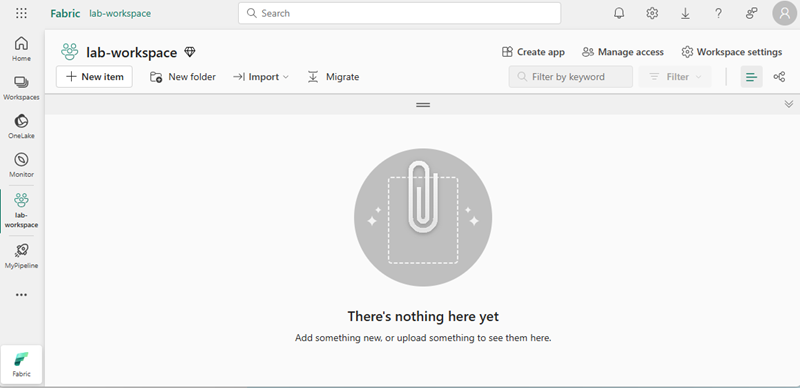

> Note: When you create a workspace, you automatically become a member of the Workspace Admin role.

#### Create a data warehouse
Next, create a data warehouse in the workspace you created:
1. Click **+ New Item**. On the *New item* page, under the *Store Data* section, select **Sample warehouse** and create a new data warehouse with a name of your choice.

After a minute or so, a new warehouse will be created:

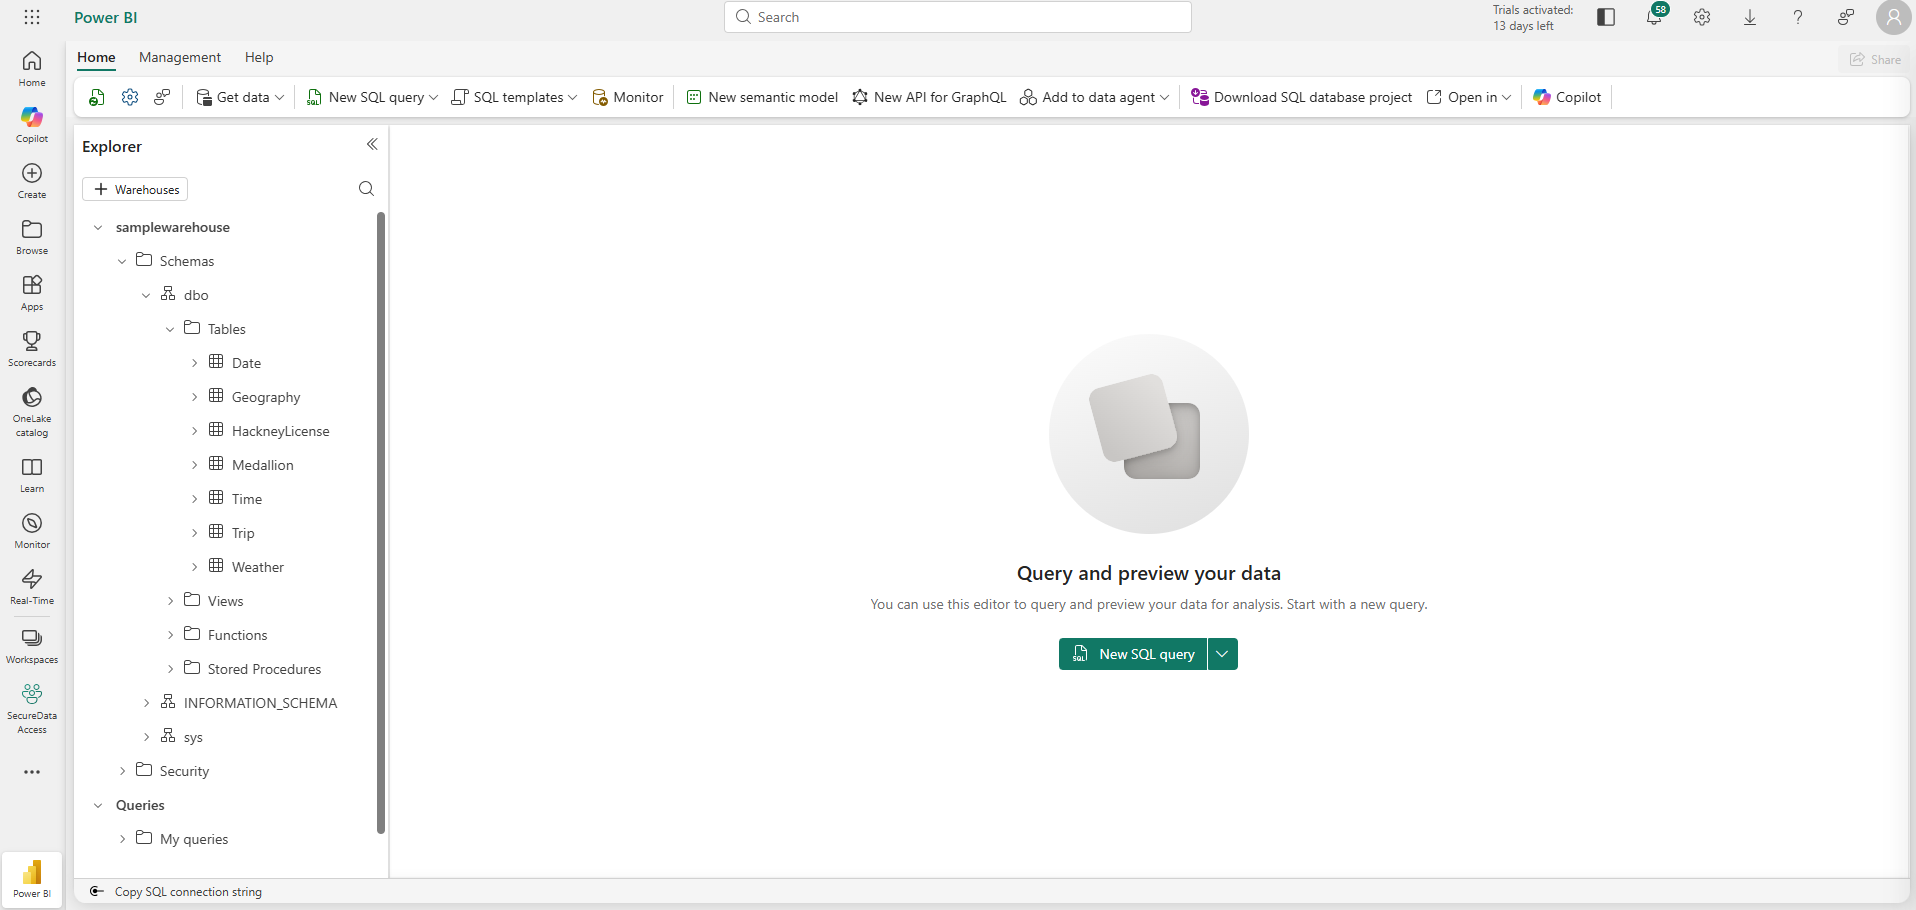

#### Create a lakehouse
Next, create a lakehouse in the workspace you created.
1. In the menu bar on the left, select **Workspaces** (the icon looks similar to 🗇).
2. Select the workspace you created.
3. In the workspace, select the **+ New Item** button and then select **Lakehouse**. Create a new Lakehouse with the name of your choice. Leave the **Lakehouse schemas** box selected.

After a minute or so, a new Lakehouse will be created:

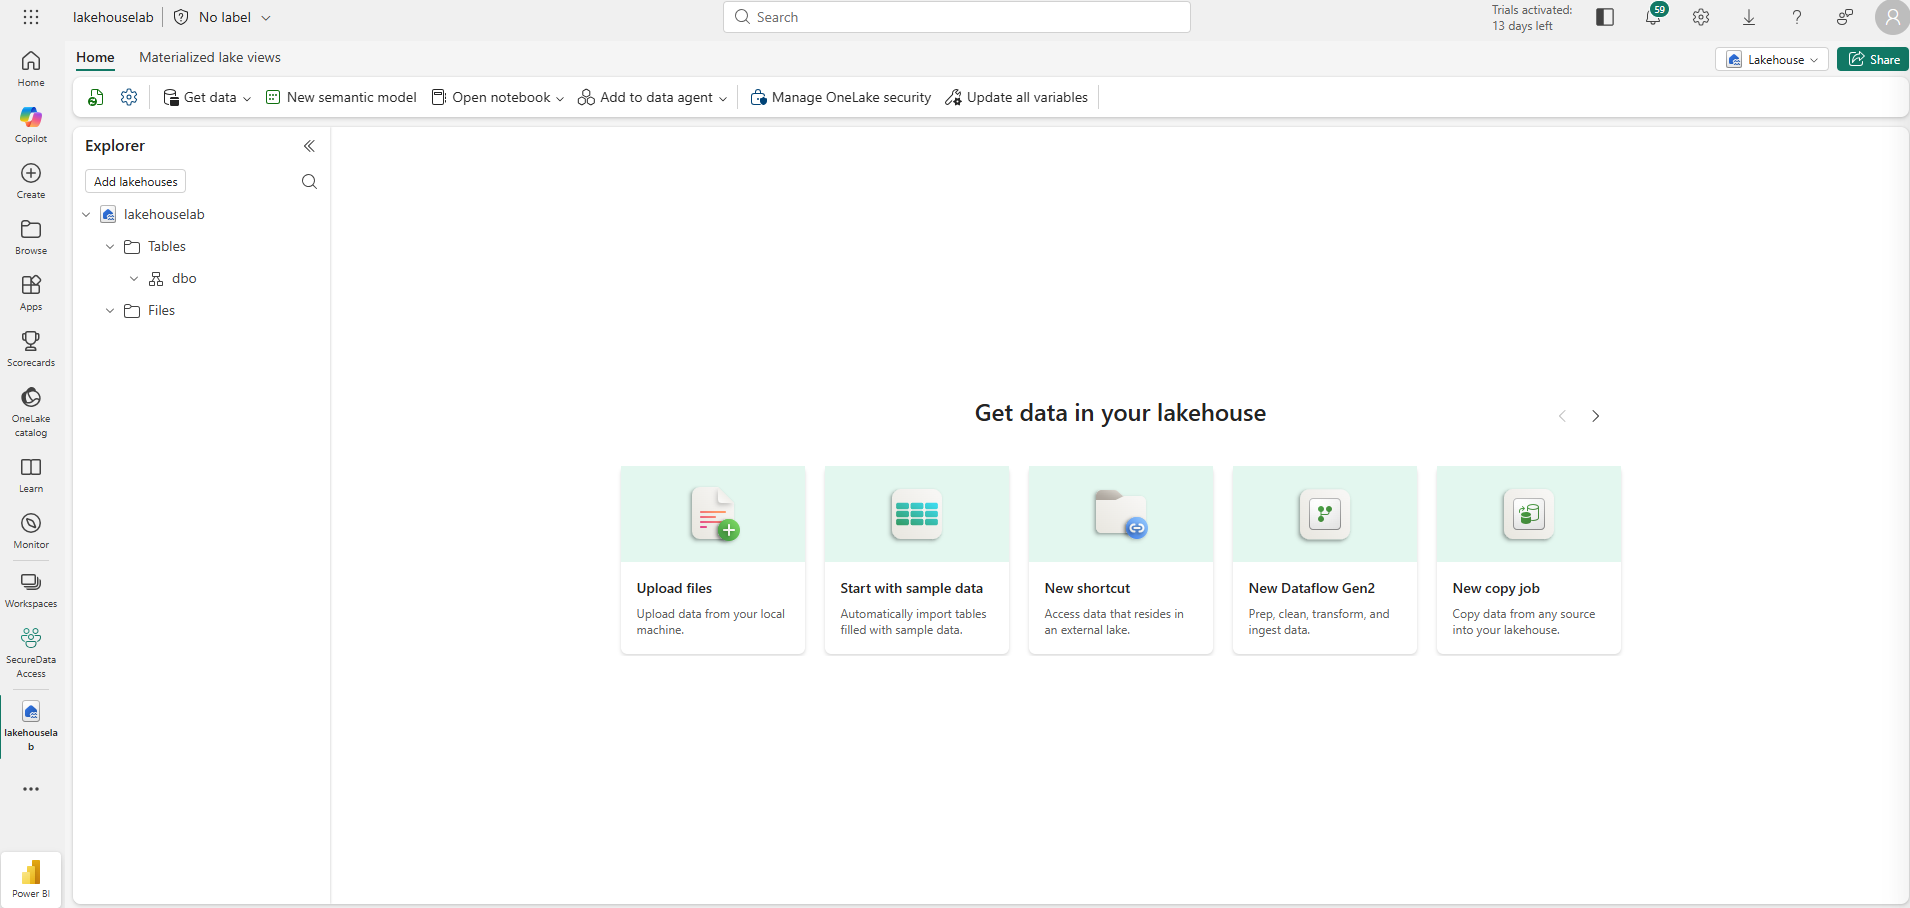

4. Select the **Start with sample data** tile. After a minute or so, the lakehouse will be populated with sample public holidays data.
#### Apply workspace access controls
Workspace roles are used to control access to workspaces and the content within them. Workspace roles can be assigned when users need to see all items in a workspace, when they need to manage workspace access, or create new Fabric items, or when they need specific permissions to view, modify or share content in the workspace.

In this exercise, you add a user to a workspace role, apply permissions, and see what is viewable when each set of permissions is applied. You open two browsers and sign-in as different users. In one browser, you’ll be a **Workspace Admin** and in the other, you’ll sign-in as a second, less privileged user. In one browser, the Workspace Admin changes permissions for the second user and in the second browser, you’re able to see the effects of changing permissions.
1. In the menu bar on the left, select **Workspaces** (the icon looks similar to 🗇).
2. Next select the workspace you created.
3. Select **Manage access** on the top of the screen.
> Note: You’ll see the user you’re logged in as, who is a member of the Workspace Admin role because you created the workspace. No other users are assigned access to the workspace yet.

1. Next, you’ll see what a user without permissions on the workspace can view. In your browser, open an InPrivate window. In the Microsoft Edge browser, select the ellipse at the top right corner and select **New InPrivate Window**.
2. Enter https://app.fabric.microsoft.com and sign-in as the second user you’re using for testing.
3. On the bottom left corner of your screen, select **Microsoft Fabric** and then select **Data Warehouse**. Next select **Workspaces** (the icon looks similar to 🗇).
> Note: The second user doesn’t have access to the workspace, so it’s not viewable.

1. Next, you assign the **Workspace Viewer** role to the second user and see that the role grants read access to the warehouse in the workspace.
2. Return to the browser window where you’re logged in as the Workspace Admin. Ensure you’re still on the page that shows the workspace you created. It should have your new workspace items, and the sample warehouse and lakehouse, listed at the bottom of the page.
3. Select **Manage access** at the top right of the screen.
4. Select **Add people or groups**. Enter the email of the second user you’re testing with. Select **Add** to assign the user to the workspace **Viewer** role.
5. Return to the InPrivate browser window where you’re logged in as the second user and select refresh button on the browser to refresh session permissions assigned to the second user.
6. Select the **Workspaces** icon on the left menu bar (the icon looks similar to 🗇) and select the workspace name you created as the Workspace Admin user. The second user can now see all of the items in the workspace because they were assigned the **Workspace Viewer** role.

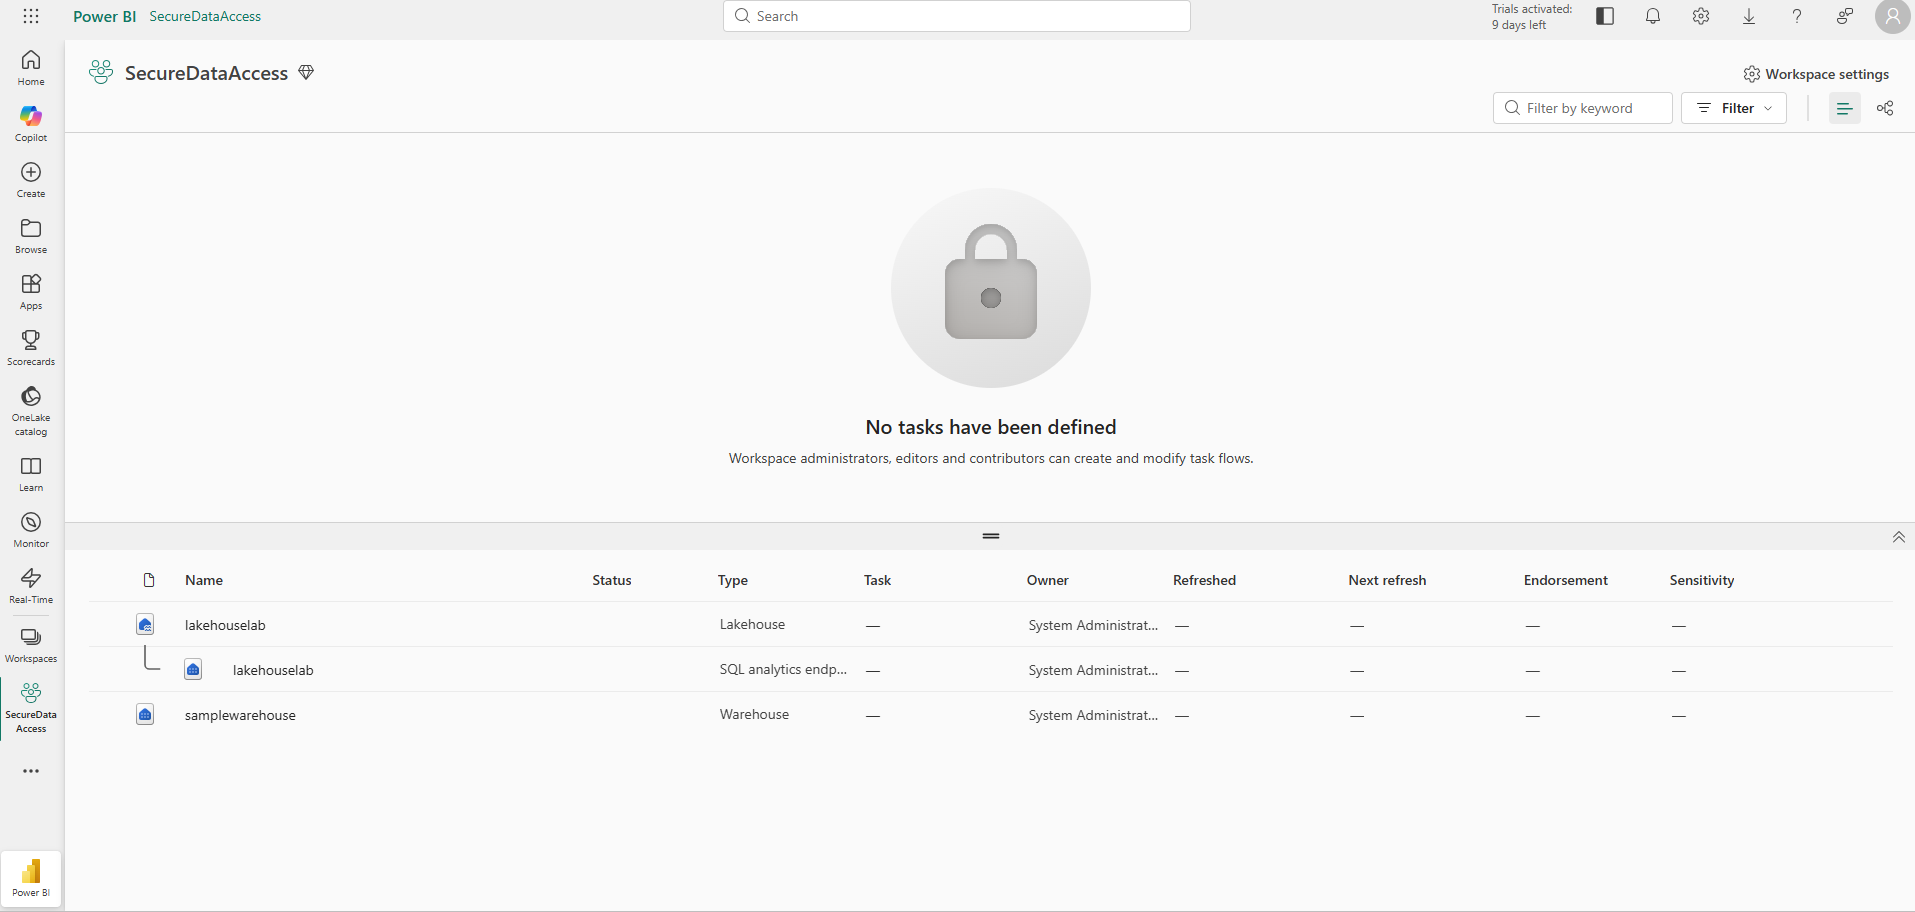

7. Select the warehouse and open it.
8. Select the **Date** table and wait for the rows to be loaded. You can see the rows because as a member of the Workspace Viewer role, you have *CONNECT* and *ReadData* permission on tables in the warehouse. For more information on permissions granted to the Workspace Viewer role, see [Workspace roles](https://learn.microsoft.com/en-us/fabric/data-warehouse/workspace-roles).
9. Next, select the **Workspaces** icon on the left menu bar, then select the lakehouse.
10. When the lakehouse opens, click on the dropdown box at the top right corner of the screen that says **Lakehouse** and select **SQL analytics endpoint**.
11. Select the `publicholidays` table and wait for the data to be displayed. Data in the lakehouse table is readable from the SQL analytics endpoint because the user is a member of the Workspace Viewer role that grants read permissions on the SQL analytics endpoint.
#### Apply item access control
Item permissions control access to individual Fabric items within a workspace, like warehouses, lakehouses and semantic models. In this exercise, you remove the **Workspace Viewer** permissions applied in the previous exercise and then apply item level permissions on the warehouse so a less privileged user can only view the warehouse data, not the lakehouse data.
1. Return to the browser window where you’re logged in as the Workspace Admin. Select **Workspaces** from the left navigation pane.
2. Select the workspace that you created to open it.
3. Select **Manage access** from the top of the screen.
4. Select the word **Viewer** under the name of the second user. On the menu that appears, select **Remove**.

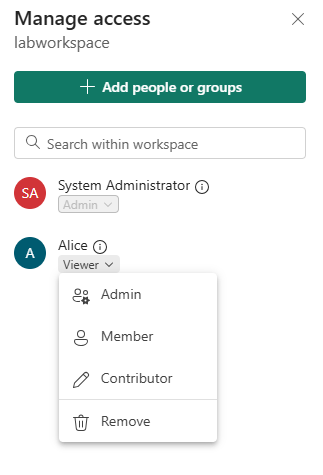

5. Close the **Manage access** section.
6. In the workspace, hover over the name of your warehouse and an ellipse (…) will appear. Select the ellipse and select **Manage permissions**.
7. Select **Add user** and enter the name of the second user.
8. In the box that appears, under **Additional permissions**, select **ReadData** and clear all other checkboxes.

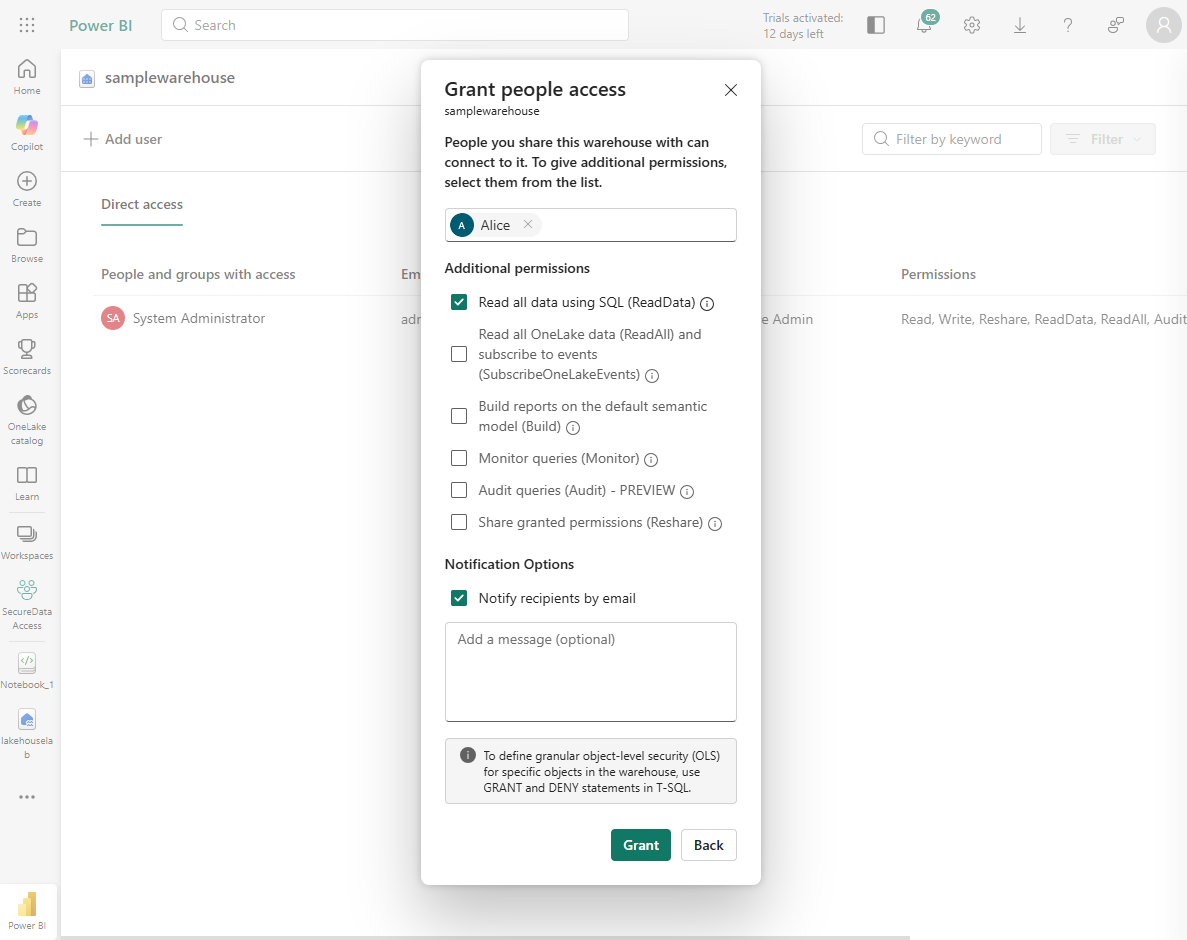

9. Select **Grant**.
10. Return to the browser window where you’re logged in as the second user. Navigate to the workspace icon again and refresh the browser view.
11. The second user no longer has access to everything in the workspace and instead has access to only the warehouse. You can no longer browse workspaces on the left navigation pane to find the warehouse. Select **OneLake catalog** on the left navigation menu to find the warehouse:
12. On the screen that appears, next to **All items**, select **Type: Data items**, then select **All types**.

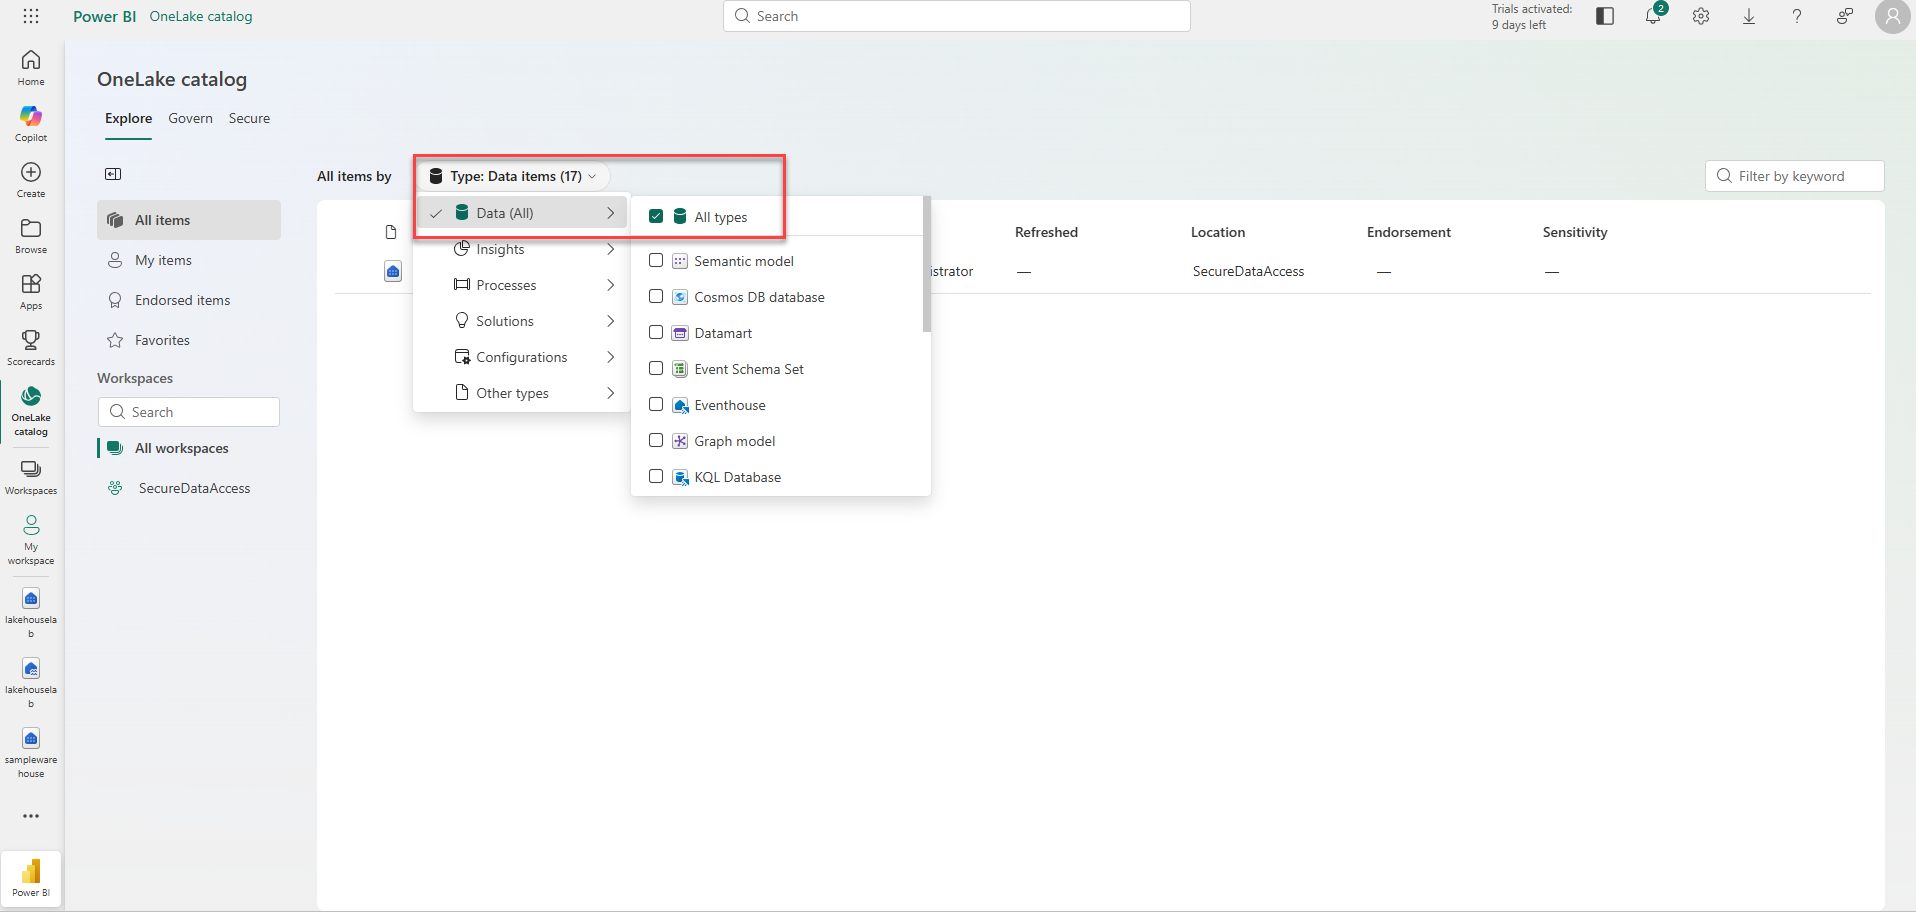

13. Select the warehouse, then select **Open**.
14. Select the **Date** table to view table data. The rows are viewable because the user has **ReadData** permission on the warehouse, which was granted through item-level permissions.
#### Apply OneLake security in a lakehouse
OneLake security lets you create custom roles within a lakehouse and grant granular access to specific tables and folders. You can also add row or column constraints to roles to further limit data access.

In this exercise, you grant an item permission and create an OneLake security role to control access to data in a lakehouse.
1. Stay in the browser where you’re logged in as the second user.
2. Select **OneLake catalog** on the left navigation bar. The second user doesn’t see the lakehouse.
3. Return to the browser where you’re logged in as the Workspace Admin.
4. Select **Workspaces** on the left menu and select your workspace. Hover over the name of the lakehouse.
5. Select the ellipse (…) and select **Manage permissions**.

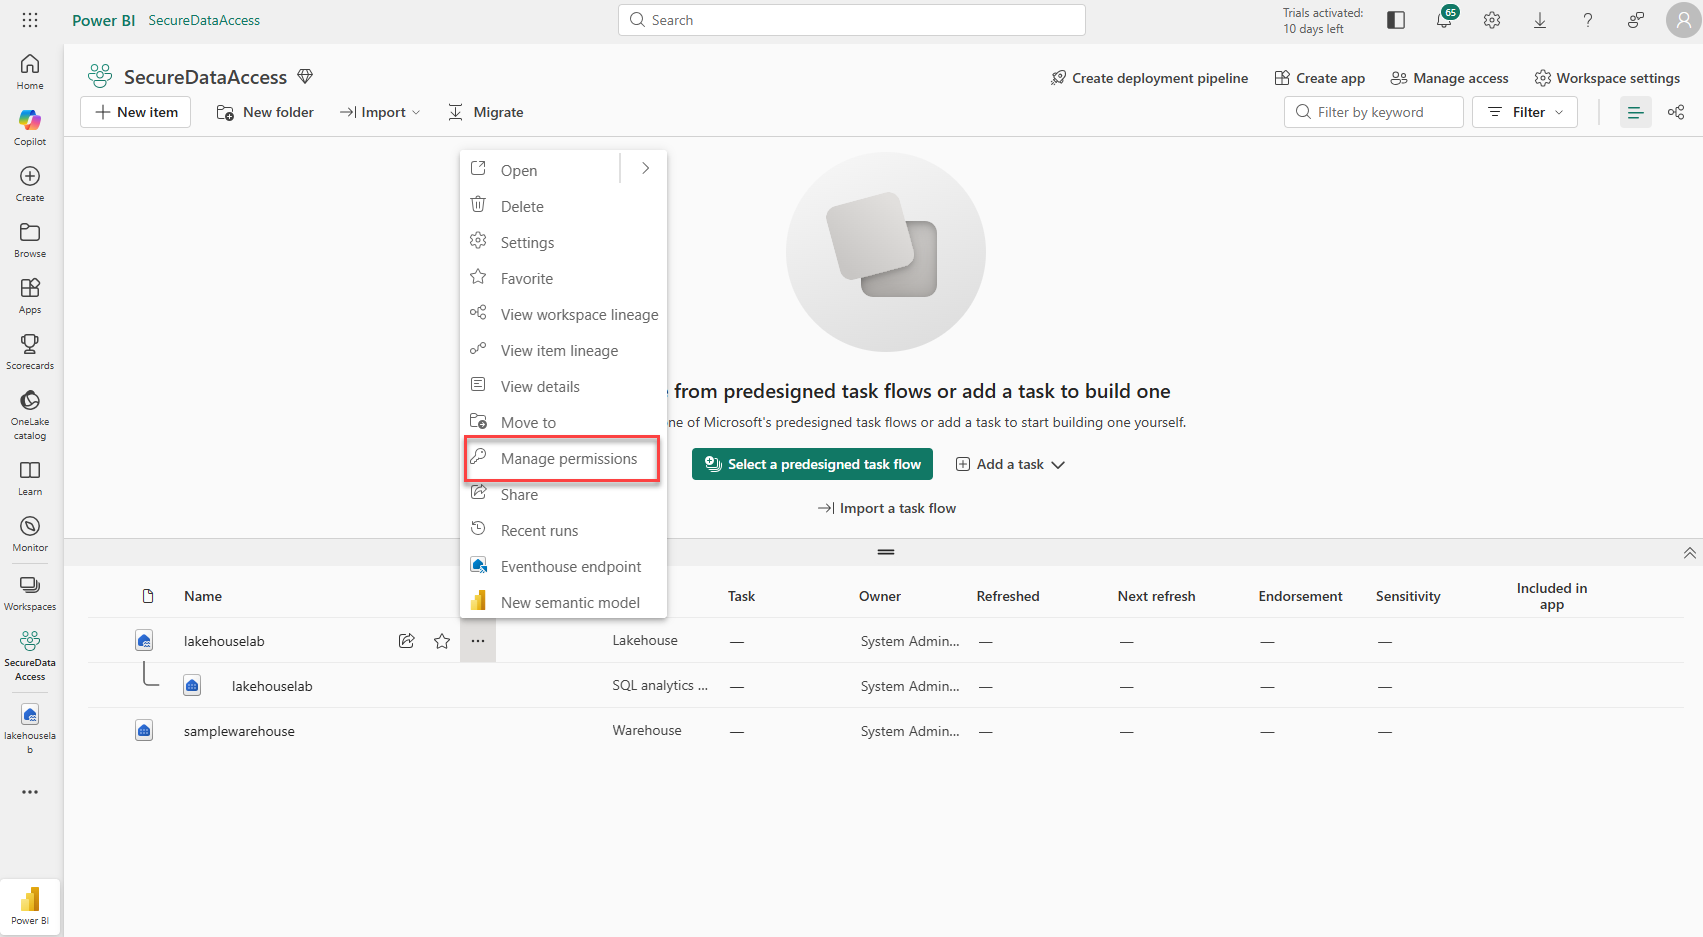

6. On the screen that appears, select **Add user**.
7. Assign the second user to the lakehouse and ensure none of the permission checkboxes on the **Grant People Access** window are checked.

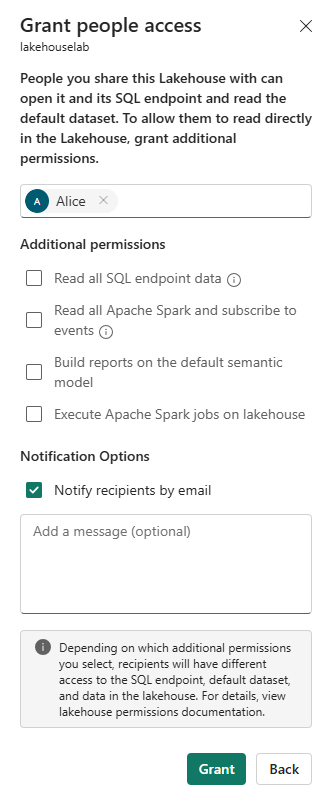

8. Select **Grant**. The second user now has **Read** permission on the lakehouse, which allows access to metadata but not the underlying data. Next, you’ll validate this behavior.
9. Return to the browser where you’re logged in as the second user. Refresh the browser.
10. Select **OneLake catalog** in the left navigation pane.
11. Select the ellipsis (…) next to the lakehouse name and select **Open**.
12. Try to expand **Tables** to see the `publicholidays` table. You’ll see the lakehouse but won’t be able to view data in publicholidays table.

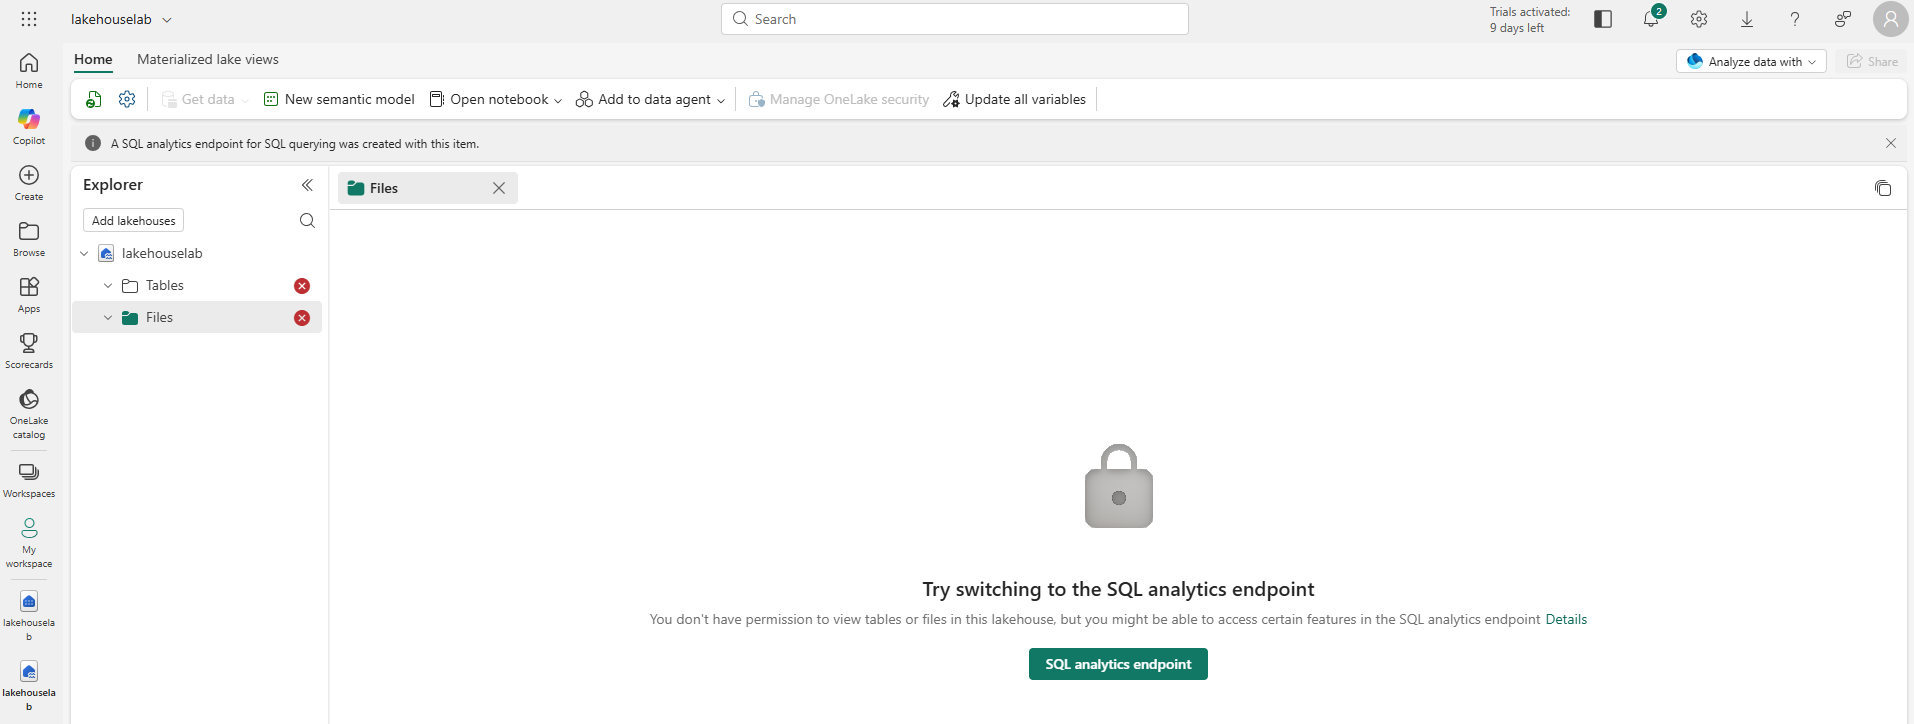

13. Next, you’ll grant the second user access to the `publicholidays` table using OneLake security roles.
14. Return to the browser where you’re logged in as the workspace administrator.
15. Select **Workspaces** from the left navigation bar.
16. Select your workspace name.
17. Select the lakehouse to open it.
18. When the lakehouse opens, select **Manage OneLake security**.

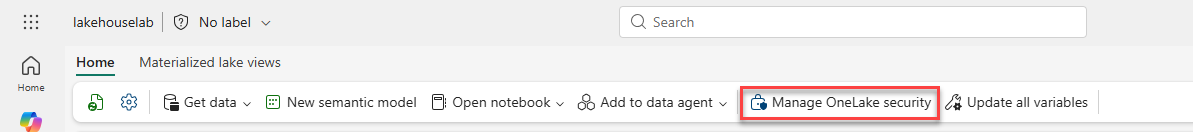

19. On the **OneLake security** screen that appears, select **+ New**.
20. Create a new role named `publicholidays`. Under **Select Grant permissions**, leave the box unchecked. Select **Next**.
21. On the **New role Data** screen that appears, under **Add data to your role**, select **Selected data**.
22. Under **Data preview**, select **Edit**. In the data browser, expand **Tables**, and **dbo**, then select the checkbox next to `publicholidays`.

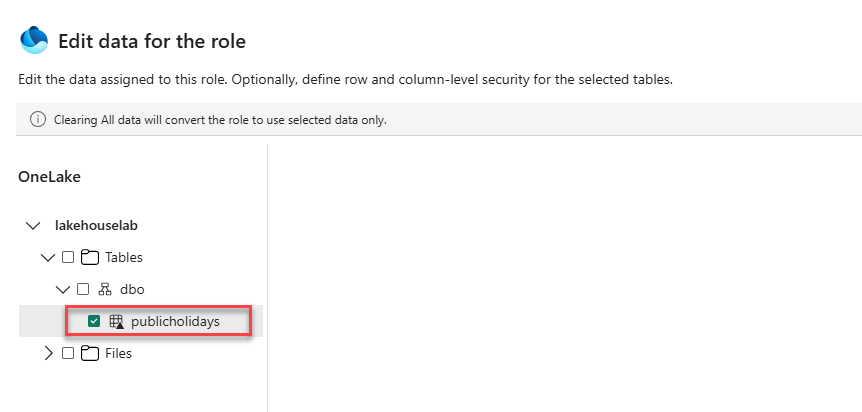

23. Select **Add data** to confirm. Then select **Next** from the **New role Data** screen.
24. In the **New role Member** section, enter the email address of your second user, select the **checkbox**, then select **Create**.

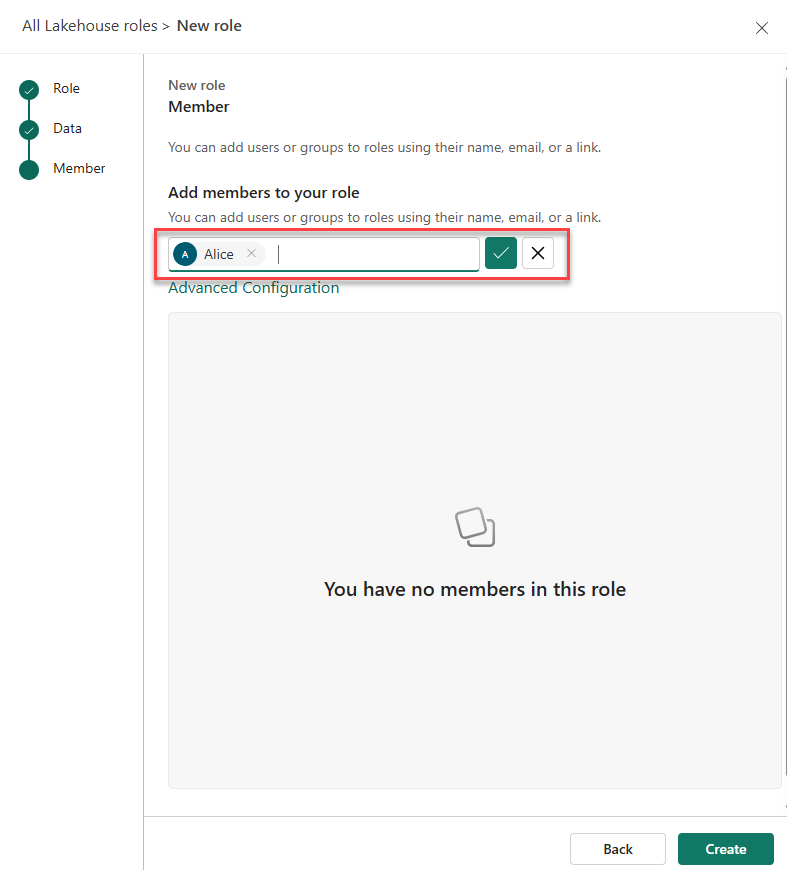

25. Return to the browser where you’re logged in as the second user. Ensure you’re still on the page where the lakehouse is open. Refresh the browser.
26. Expand **Tables** in the lakehouse explorer and select the `publicholidays` table. Wait for the data to load. The user can now view data in this table because they’re a member of the `publicholidays` OneLake security role, which grants **Read** permission to this specific table only.
#### Clean up resources
In this exercise, you secured data using workspace access controls, item access controls, and OneLake security roles.
1. In the left navigation bar, select the icon for your workspace to view all of the items it contains.
2. In the menu on the top toolbar, select **Workspace settings**.
3. In the **General** section, select **Remove this workspace**.

### **Module assessment**

#### 1. A healthcare organization needs to ensure that its data analysts can only access de-identified patient records stored in specific folders in OneLake. How should the security roles be configured? 

A) Assign the analysts to a Contributor workspace role for broad access. \
B) Use item permissions to share the entire lakehouse with the analysts. \
**C) Create OneLake security roles that grant Read access to the specific folders containing de-identified records.**

#### 2. Which component must be included in a OneLake security role to ensure that only specific users can access the designated data? 

**A) Members** \
B) Constraints \
C) Permission

#### 3. In your organization, a data analyst needs access to specific datasets within a lakehouse for reporting purposes, but should not have access to all the data. What security feature should you implement in Microsoft Fabric to ensure this level of access control? 

A) Assign the data analyst a Contributor role in the workspace. \
**B) Use OneLake security roles to grant access to the specific tables needed.** \
C) Use item permissions to share the entire lakehouse with the data analyst.

#### 4. A user needs to create, view, and modify all content and data in a workspace but should not have permission to share or manage permissions. Which workspace role is appropriate? 

A) Member \
B) Viewer \
**C) Contributor**

#### 5. When should you use item permissions over workspace roles in Microsoft Fabric? 

**A) When a user needs access to only a specific item, such as a single lakehouse, rather than the entire workspace.** \
B) When a user needs to create and manage all content within a workspace. \
C) When a user needs to view all items in a workspace but not modify them.

#### 6. A user reports that they cannot access any data in a lakehouse even though they can see the lakehouse item in their workspace. What is the most likely cause of this issue? 

A) The user is assigned the Admin role in the workspace. \
**B) The user does not have the appropriate OneLake security role assigned.** \
C) The user is not authenticated with Microsoft Entra ID.

#### 7. In Microsoft Fabric, how can you ensure a user has ReadWrite access to only specific folders within a lakehouse, without granting workspace-wide write permissions? 

A) Use T-SQL to grant write permissions on the lakehouse endpoint. \
B) Assign the user a Contributor workspace role for the entire workspace. \
**C) Create a OneLake security role with ReadWrite permission for specified folders.**

#### 8. What is the main advantage of using OneLake security roles in Microsoft Fabric? 

**A) They allow precise control over which tables or folders within a Fabric item can be accessed by specific users.** \
B) They grant users the ability to modify all content and data within a Fabric workspace. \
C) They provide access to all items in a workspace without limitation.

#### 9. In the context of Microsoft Fabric, what is the primary function of the Contributor workspace role? 

**A) To create, view, and modify all content and data in the workspace without sharing or permission management capabilities.** \
B) To create, view, modify, and share all content and data in the workspace. \
C) To view all content in the workspace without modifying it.

## **Secure a Microsoft Fabric data warehouse**

### **Introduction**

#### Key Idea
Fabric warehouse security uses **multiple layers of protection**.

Even if a user can access a warehouse, you may still want to control:

✅ Which tables they see \
✅ Which rows they see \
✅ Which columns they see \
✅ How sensitive values appear

This module focuses on the **Data Protection Layer**.
#### Security Layers in a Fabric Warehouse
> Workspace Roles → Item Permissions → Data Protection → Audit Logs → Encryption

#### 1. Workspace Roles
##### Purpose
Control access to workspace items.

Roles:

✅ Admin \
✅ Member \
✅ Contributor \
✅ Viewer
##### Controls
Who Can Access the Warehouse
##### Examples
* Admin

  Can:

  ✅ Manage warehouse \
  ✅ Manage permissions \
  ✅ Modify content
* Viewer

  Can:

  ✅ View content \
  ❌ Modify content
##### Exam Tip
Workspace roles are the **first line of access control**.
#### 2. Item Permissions
##### Purpose
Control access to a specific warehouse.
##### Example
User needs:

✅ One warehouse \
❌ Entire workspace

Use:

✅ Item Permissions
##### Benefit
Supports:
* Least Privilege
##### Exam Tip
Item permissions provide warehouse-level sharing without broad workspace access.
#### 3. Data Protection (Main Focus of This Module)
##### Purpose
Protect data inside the warehouse.
##### Includes
✅ SQL Permissions \
✅ Dynamic Data Masking (DDM) \
✅ Row-Level Security (RLS) \
✅ Column-Level Security (CLS)
##### Exam Favorite
These controls work without changing applications.
#### Dynamic Data Masking (DDM)
##### Purpose
Mask sensitive values.
##### Example
Actual value:
```
987-65-4321
```
Displayed:
```
XXX-XX-4321
```
##### Use Cases
✅ Social Security Numbers \
✅ Phone Numbers \
✅ Email Addresses \
✅ Patient IDs
##### Exam Tip
DDM hides data values but does not remove access to the column.
#### Row-Level Security (RLS)
##### Purpose
Restrict which rows users can see.
##### Example
Hospital A Manager:
> Only Hospital A Records

Hospital B Manager:
> Only Hospital B Records

* Same table.
* Different rows.
##### Exam Tip
RLS filters rows based on user context.
#### Column-Level Security (CLS)
##### Purpose
Restrict access to specific columns.
##### Example
Allowed:
```
PatientName
PatientCity
```
Blocked:
```
MedicalDiagnosis
InsuranceNumber
```
##### Exam Tip
CLS prevents users from viewing protected columns.
#### SQL Granular Permissions
##### Purpose
Control actions on warehouse objects.
##### Commands
* `GRANT`
  
  Give permission.
  ```sql
  GRANT SELECT
  ON Patients
  TO analyst1;
  ```
* `DENY`

  Explicitly block permission.
  ```sql
  DENY SELECT
  ON Diagnosis
  TO analyst1;
  ```
* `REVOKE`

  Remove permission.
  ```sql
  REVOKE SELECT
  ON Patients
  FROM analyst1;
  ```
##### Exam Tip
`GRANT`, `DENY`, and `REVOKE` are Data Control Language (DCL) commands.
#### Data Protection Layer Summary
| Feature               | Controls                  |
| --------------------- | ------------------------- |
| Dynamic Data Masking  | How values appear         |
| Row-Level Security    | Which rows are visible    |
| Column-Level Security | Which columns are visible |
| SQL Permissions       | What actions are allowed  |

#### 4. Audit Logs
##### Purpose
Track user activity.
##### Examples
✅ Logins \
✅ Queries \
✅ Permission changes \
✅ Data access activity
##### Supports
✅ Compliance \
✅ Investigations \
✅ Security monitoring
##### Sources
Audit information can be accessed through:

✅ Microsoft Purview \
✅ PowerShell
##### Exam Tip
Audit logs help detect unauthorized access.
#### 5. Encryption
##### Purpose
Protect stored warehouse data.
##### Default Behavior
✅ Encryption at rest

using:

Microsoft-Managed Keys
##### Optional
Use:

Customer-Managed Keys (CMK)

through:

Azure Key Vault
##### Exam Favorite
Fabric warehouse data is encrypted at rest by default.
#### Layer Responsibility Matrix
| Layer            | Purpose                      |
| ---------------- | ---------------------------- |
| Workspace Roles  | Workspace access             |
| Item Permissions | Warehouse access             |
| Data Protection  | Row, column, object security |
| Audit Logs       | Monitoring and compliance    |
| Encryption       | Data protection at rest      |

#### Healthcare Example
##### Doctor
Needs:

✅ Patient records

Only for their hospital.

Solution:

✅ Row-Level Security
##### Research Analyst
Needs:

✅ Patient statistics

❌ Patient identifiers

Solution:

✅ Column-Level Security

✅ Dynamic Data Masking
##### Data Engineer
Needs:

✅ Query specific tables

✅ Update ETL tables

Solution:

✅ `GRANT` permissions
#### Exam Quick Facts
✅ Fabric warehouse security has multiple layers \
✅ Data Protection is the focus of this module \
✅ Data Protection includes:
* Dynamic Data Masking (DDM)
* Row-Level Security (RLS)
* Column-Level Security (CLS)
* SQL Permissions

✅ DDM masks values \
✅ RLS filters rows \
✅ CLS hides columns \
✅ `GRANT`, `DENY`, `REVOKE` control SQL access \
✅ Audit logs track user activity \
✅ Encryption at rest is enabled by default \
✅ Customer-Managed Keys use Azure Key Vault
#### Memory Trick
#### Data Protection Layer
```
Rows
  ↓ RLS
Columns
  ↓ CLS
Values
  ↓ DDM
Actions
  ↓ GRANT / DENY / REVOKE
```
##### Most Tested Concept ⭐
Workspace roles and item permissions control who can access a warehouse, while the Data Protection layer controls exactly what data they can see and how they can interact with it.

### **Explore dynamic data masking**

#### What is Dynamic Data Masking?
**Dynamic Data Masking (DDM)** hides sensitive data from certain users while keeping the actual data unchanged in storage.

Think:
> Stored Value → Query Time Masking → User Sees Obscured Value

#### Why Use DDM?
Protect sensitive information such as:

✅ Email addresses \
✅ Credit card numbers \
✅ Phone numbers \
✅ Salaries \
✅ Patient identifiers
##### Example
Actual value:
```
johndoe@contoso.com
```
User sees:
```
j*****@contoso.com
```
##### Key Exam Concept
DDM works:

✅ At query time \
❌ Not at storage time

The real value remains unchanged in the warehouse.
##### Benefits of DDM
✅ No schema changes \
✅ No application changes \
✅ Easy to implement \
✅ Protects sensitive values \
✅ Works immediately on query results
#### Four Masking Types
##### 1. Default Mask
*Purpose*

Completely masks values based on data type.

**Rule**
```sql
default()
```
**Examples**
* String: `John Doe` → `XXXX`
* Number: `50000` → `0`
* Date: `2025-10-20` → `1900-01-01`

**Exam Tip**

Default masking replaces the entire displayed value.
##### 2. Email Mask
**Purpose**

Mask email addresses.

**Rule**
```sql
email()
```
**Example**

* Actual: `johndoe@contoso.com`
* Displayed: `j*****@contoso.com`

**Exam Favorite**

Use:
```sql
email()
```
for email addresses.
##### 3. Custom Text Mask
**Purpose**

Show selected characters while masking the rest.

**Rule**
```sql
partial(prefix,padding,suffix)
```
**Example**

Credit Card Number
* Actual: `1234-5678-9012-3456`
* Displayed: `XXXX-XXXX-XXXX-3456`

**Example Rule**
```sql
partial(0,"XXXX-XXXX-XXXX-",4)
```
**Common Uses**

✅ Credit cards \
✅ Phone numbers \
✅ Account numbers \
✅ National IDs
##### 4. Random Mask
**Purpose**

Replace values with random numbers.

**Rule**
```sql
random(low, high)
```
**Example**
* Actual: `Salary = 85000`
* Displayed: `74213`

(random value within range)

**Use Cases**

✅ Financial data \
✅ Numeric measurements \
✅ Research datasets
#### Configure Dynamic Data Masking
DDM is added using:
```sql
ALTER TABLE
```
##### Email Mask Example
```sql
ALTER TABLE Customers
ALTER COLUMN Email
ADD MASKED WITH
(FUNCTION = 'email()');
```
##### Phone Number Example
Show last four digits only:
```sql
ALTER TABLE Customers
ALTER COLUMN PhoneNumber
ADD MASKED WITH
(FUNCTION = 'partial(0,"XXX-XXX-",4)');
```
##### Result
* Actual: `555-555-7890`
* Displayed: `XXX-XXX-7890`
##### Credit Card Example
```sql
ALTER TABLE Customers
ALTER COLUMN CreditCardNumber
ADD MASKED WITH
(FUNCTION = 'partial(0,"XXXX-XXXX-XXXX-",4)');
```
##### Result
* Actual: `1234-5678-9012-3456`
* Displayed: `XXXX-XXXX-XXXX-3456`
#### Remove a Mask
Use:
```sql
ALTER TABLE
ALTER COLUMN
DROP MASKED
```
Example:
```sql
ALTER TABLE Customers
ALTER COLUMN Email
DROP MASKED;
```
#### What Users See
With masking configured:
```
CustomerName: John Doe
Email: j*****@contoso.com
Phone: XXX-XXX-7890
CreditCard: XXXX-XXXX-XXXX-3456
```
#### Users Who Always See Real Data
Users with:

`CONTROL`

permission.

Examples include:

✅ Admins \
✅ Members \
✅ Contributors
##### Exam Tip
CONTROL permission bypasses DDM.
#### DDM Limitation
Very important exam concept.

DDM:

✅ Hides values \
❌ Does NOT secure the data itself \
❌ Does NOT prevent queries \
❌ Does NOT block access to the column
##### Example
User can still:
```sql
SELECT Email
FROM Customers
```
but sees:
* Masked Results
#### DDM Is Not a Security Boundary
Microsoft specifically treats DDM as:
> Data Obfuscation

not true access control.

For stronger protection use:

✅ Row-Level Security (RLS) \
✅ Column-Level Security (CLS) \
✅ SQL Permissions
#### UNMASK Permission
##### Purpose
Allow specific users to see real values.
##### Example:
```sql
GRANT UNMASK
ON dbo.Customers
TO [user@contoso.com];
```
##### Result
User sees:
> Unmasked Data

without becoming an administrator.
#### Revoke UNMASK
```sql
REVOKE UNMASK
ON dbo.Customers
FROM [user@contoso.com];
```
##### Result
User returns to seeing:
* Masked Data
#### ALTER ANY MASK Permission
##### Purpose
Allow mask administration.
##### Example:
```sql
GRANT ALTER ANY MASK
TO [engineer@contoso.com];
```
##### Allows:
✅ Add masks \
✅ Modify masks \
✅ Remove masks
##### Without granting:
✅ Full administrative rights
#### DDM Permission Summary
| Permission     | Purpose                   |
| -------------- | ------------------------- |
| CONTROL        | Always view unmasked data |
| UNMASK         | View real values          |
| ALTER ANY MASK | Manage masking rules      |

#### Dynamic Data Masking Architecture
> Stored Data → DDM Rule → Query Executed → Masked Output

#### When to Use DDM
Use for:

✅ Email addresses \
✅ Credit card numbers \
✅ Phone numbers \
✅ Salary information \
✅ Medical record identifiers
#### When NOT to Rely on DDM Alone
##### Don't use DDM alone when:
✅ Legal compliance requires true restriction \
✅ Users must not access sensitive columns \
✅ Data exposure risk is high`
##### Instead add:
✅ RLS \
✅ CLS \
✅ T-SQL Permissions
#### Exam Quick Facts
✅ DDM = Dynamic Data Masking \
✅ Masks data at query time \
✅ Original data remains unchanged \
✅ Four masking types:
* `default()`
* `email()`
* `partial()`
* `random()`

✅ `email()` masks email addresses \
✅ `partial()` masks part of a string \
✅ `random()` replaces values with random numbers \
✅ `DROP MASKED` removes masking \
✅ `CONTROL` permission bypasses masking \
✅ `UNMASK` allows specific users to view actual values \
✅ `ALTER ANY MASK` allows users to manage masks \
✅ DDM hides values but does not restrict access to the column \
✅ DDM is not a complete security solution
#### Memory Trick
##### DDM Purpose
* Hide The Value
* Not The Column
##### Permission Memory
> `CONTROL` → See Everything

> `UNMASK` → See Real Values

> `ALTER ANY MASK` → Manage Masks

##### ⭐ Most Tested Concept:
Dynamic Data Masking hides sensitive values in query results but does not prevent users from accessing the column or querying the data.

### **Implement row-level security**

#### What is Row-Level Security (RLS)?
**Row-Level Security (RLS)** restricts which rows a user can see in a table.

Users query the same table, but each user sees only the rows they're authorized to access.
##### Example
Sales table:
| SalesID | SalesPerson         | Amount |
| ------- | ------------------- | ------ |
| 1       | <alice@contoso.com> | 100    |
| 2       | <bob@contoso.com>   | 200    |
| 3       | <alice@contoso.com> | 300    |

When Alice runs:
```sql
SELECT * FROM Sales
```
She sees:
| SalesID | SalesPerson         | Amount |
| ------- | ------------------- | ------ |
| 1       | <alice@contoso.com> | 100    |
| 3       | <alice@contoso.com> | 300    |

Bob sees:
| SalesID | SalesPerson       | Amount |
| ------- | ----------------- | ------ |
| 2       | <bob@contoso.com> | 200    |

##### Key Exam Concept
RLS is enforced by:

✅ The database engine

not by:

❌ The application

No application code changes are required.
#### How RLS Works
RLS uses two components:
> Filter Predicate + Security Policy

#### 1. Filter Predicate
##### Purpose
Defines which rows are visible.

Implemented as:
> Inline Table-Valued Function

Returns:

✅ TRUE → Row visible \
❌ FALSE → Row hidden
##### Affects
✅ `SELECT` \
✅ `UPDATE` \
✅ `DELETE`
##### Does NOT Affect
❌ `INSERT`
##### Exam Tip
Filter predicates do not control INSERT operations.
#### 2. Security Policy
##### Purpose
Applies the filter predicate to a table.

Relationship:
> Filter Predicate → Security Policy → Table

Whenever a query executes:

✅ The policy runs automatically \
✅ Filtering is transparent \
✅ Users don't know rows are being filtered
#### RLS Configuration Steps
##### Step 1: Create Table
Example:
```sql
CREATE TABLE Sales (
    SalesID INT,
    ProductID INT,
    SalesPerson NVARCHAR(50),
    OrderQty INT,
    UnitPrice MONEY
);
```
##### Step 2: Insert Sample Data
```sql
INSERT INTO Sales
VALUES
(1,3,'alice@contoso.com',5,10.00),
(2,4,'alice@contoso.com',2,57.00),
(3,7,'bob@contoso.com',4,23.00);
```
##### Step 3: Create Security Schema
```sql
CREATE SCHEMA Sec;
```
##### Purpose
Store:

✅ Predicates \
✅ Security objects
##### Step 4: Create Filter Predicate
Example:
```sql
CREATE FUNCTION
sec.tvf_SecurityPredicateBySalesPerson
(
 @SalesPerson NVARCHAR(50)
)
RETURNS TABLE
WITH SCHEMABINDING
AS
RETURN
SELECT 1 AS Result
WHERE
   @SalesPerson = USER_NAME()
   OR USER_NAME() = 'salesadmin@contoso.com';
```
##### What This Predicate Does
* Normal Users

    Can see rows where:
    ```
    SalesPerson = Current User
    ```
* Admin User
    ```
    salesadmin@contoso.com
    ```
    can see:

    ✅ All rows
##### Exam Tip
Always think about admin access when designing predicates.
##### Step 5: Create Security Policy
```sql
CREATE SECURITY POLICY
Sec.SalesPolicy
ADD FILTER PREDICATE
Sec.tvf_SecurityPredicateBySalesPerson
(
 SalesPerson
)
ON dbo.Sales
WITH (STATE = ON);
```
##### Result
Policy automatically filters:
```sql
SELECT * FROM Sales;
```
based on the logged-in user.
#### Disabling RLS
Temporarily disable:
```sql
WITH (STATE = OFF)
```
Useful for:

✅ Testing \
✅ Troubleshooting \
✅ Administration
#### Example Results
##### Alice
```
USER_NAME() = alice@contoso.com
```
Sees only:

Alice Rows
##### Bob
```
USER_NAME() = bob@contoso.com
```
Sees only:

Bob Rows
##### Sales Admin
```
USER_NAME() = salesadmin@contoso.com
```
Sees:

All Rows
#### Security Considerations
##### Admin Access Is NOT Automatic
Very important exam concept.

RLS applies to:

✅ Viewers \
✅ Contributors \
✅ Members \
✅ Admins

If the predicate doesn't explicitly allow admins:
* Admins Will Be Filtered Too
##### Exam Favorite
RLS affects everyone unless explicitly bypassed.
#### Side-Channel Attacks
Another common exam topic.
##### What Is a Side-Channel Attack?
* A user infers hidden data indirectly.
* They never see the data directly.
##### Example
Attacker guesses:
```
Salary = 0
```
and runs:
```
1 / Salary
```
If:
> Divide By Zero Error

occurs,

they learn something about hidden data.
##### Exam Tip
RLS does not completely eliminate side-channel attacks.
#### Reducing Side-Channel Risks
Use RLS together with:

✅ Column-Level Security (CLS) \
✅ Dynamic Data Masking (DDM) \
✅ Auditing \
✅ Restricted administrator permissions
#### Important Permission
Only trusted users should receive:
```
ALTER ANY SECURITY POLICY
```
Because this permission allows:

✅ Modify RLS rules \
✅ Disable protections
#### RLS vs Other Security Features
| Feature    | Controls         |
| ---------- | ---------------- |
| RLS        | Rows             |
| CLS        | Columns          |
| DDM        | Displayed Values |
| GRANT/DENY | Object Access    |

#### Example Healthcare Scenario
Table:
* `PatientRecords`

contains:
* Hospital A
* Hospital B
* Hospital C

records.

Doctor A should only see:
> Hospital A Patients

Use:

✅ Row-Level Security
* The same table remains shared.
* Only visible rows change.
#### Exam Quick Facts
✅ RLS = Row-Level Security \
✅ Restricts rows returned to users \
✅ Implemented at the database engine level \
✅ Requires:
* Filter Predicate
* Security Policy

✅ Filter predicates are inline table-valued functions \
✅ Predicate returns:
* `TRUE` = show row
* `FALSE` = hide row

✅ Affects:
* `SELECT`
* `UPDATE`
* `DELETE`

✅ Does not affect:
* `INSERT`

✅ Security policies apply predicates automatically \
✅ RLS applies to Admins, Members, Contributors, and Viewers \
✅ Admin access must be explicitly included if required \
✅ RLS can be vulnerable to side-channel attacks \
✅ Combine RLS with:
* CLS
* DDM
* Auditing

✅ Restrict:
* ALTER ANY SECURITY POLICY
#### Memory Trick
##### RLS Formula
> Filter Predicate + Security Policy → Row-Level Security

##### What RLS Protects
Rows
##### Most Tested Concept ⭐
RLS uses filter predicates and security policies to automatically restrict rows returned by queries, and it applies to all users, including administrators, unless explicitly excluded in the predicate.

### **Implement column-level security**

#### What is Column-Level Security (CLS)?
**Column-Level Security (CLS)** restricts access to specific columns in a table.

Users can:

✅ Access the table \
✅ Query allowed columns \
❌ Access protected columns
##### Example
* Table: `Patients`
* Columns:
    * `PatientID`
    * `Name`
    * `Address`
    * `DateOfBirth`
    * `MedicalHistory`

A receptionist may see:

✅ `PatientID` \
✅ `Name` \
✅ `Address`

But not:

❌ `MedicalHistory`
##### Key Exam Concept
CLS protects:
> Columns

while RLS protects:
> Rows

#### Why Use CLS?
Use CLS when:

✅ Some users need table access \
✅ Certain columns contain sensitive information \
✅ Different job roles need different visibility
##### Healthcare Example
Sensitive column:
```
MedicalHistory
```
Contains:

✅ Diagnoses \
✅ Treatments \
✅ Protected health information

Access should be limited to:

✅ Doctors \
✅ Nurses

Not:

❌ Receptionists \
❌ Patients
#### CLS Implementation Process
##### Step 1: Identify Sensitive Columns
Determine which columns require protection.

Example:
```
MedicalHistory
InsuranceNumber
Salary
CreditCardNumber
```
##### Step 2: Create Roles
Roles reflect business job functions.

Example:
```sql
CREATE ROLE Doctor;
CREATE ROLE Nurse;
CREATE ROLE Receptionist;
CREATE ROLE Patient;
```
##### Exam Tip
CLS is commonly implemented through database roles.
##### Step 3: Assign Users to Roles
Examples:
* Dr. Smith → Doctor
* Jane Jones → Nurse
* Tom Brown → Receptionist
##### Step 4: Apply GRANT and DENY
* Grant access to the table.
* Deny access to sensitive columns.
#### Grant Table Access
Example:
```sql
GRANT SELECT ON dbo.Patients TO Doctor;
GRANT SELECT ON dbo.Patients TO Nurse;
GRANT SELECT ON dbo.Patients TO Receptionist;
GRANT SELECT ON dbo.Patients TO Patient;
```
##### Result
All users can access:

`Patients` Table
#### Deny Sensitive Column Access
Example:
```sql
DENY SELECT
ON dbo.Patients (MedicalHistory)
TO Receptionist;

DENY SELECT
ON dbo.Patients (MedicalHistory)
TO Patient;
```
##### Result
Receptionists and patients cannot access:

`MedicalHistory`
##### What Happens When Access Is Denied?
User executes:
```sql
SELECT MedicalHistory
FROM dbo.Patients;
```
Result:
```
Permission Error
```
##### Exam Tip
* CLS blocks access completely.
* It does NOT mask values.
#### CLS vs Dynamic Data Masking
A common exam comparison.
##### Column-Level Security
> Column Hidden

User receives:
> Access Denied

##### Dynamic Data Masking
> Column Accessible

User receives:
> Masked Values

##### Example
* CLS: No Access
* DDM: `XXXX-XXXX-1234`
#### CLS vs RLS
| Security Feature | Restricts        |
| ---------------- | ---------------- |
| RLS              | Rows             |
| CLS              | Columns          |
| DDM              | Displayed Values |

#### Example
##### Row-Level Security
**User sees**: Only Hospital A Patients
##### Column-Level Security
* **User sees**: Hospital A Patients
* **but not**: `MedicalHistory`
#### Security Flow
> Table → Column Security → Role-Based Access → Allowed Columns

#### Direct Lake Consideration
Important exam topic.

When:

✅ Power BI uses Direct Lake

AND

✅ CLS exists on a table

Fabric automatically changes query behavior to:
> Direct Query

##### Security
✅ Still enforced
##### Performance
❌ May be slower than Direct Lake
##### Exam Favorite
CLS causes Direct Lake queries to:
* Fallback To Direct Query
#### Healthcare Example
##### Doctor Role
Can access:
```
PatientID
Name
Address
DateOfBirth
MedicalHistory
```
##### Nurse Role
Can access:
```
PatientID
Name
Address
DateOfBirth
MedicalHistory
```
##### Receptionist Role
Can access:
```
PatientID
Name
Address
DateOfBirth
```
Cannot access:
```
MedicalHistory
```
##### Patient Role
Can access:
```
PatientID
Name
Address
DateOfBirth
```
Cannot access:
```
MedicalHistory
```
#### Comparison of Data Protection Features
| Feature        | User Can Access Column?   | User Sees Actual Value? |
| -------------- | ------------------------- | ----------------------- |
| DDM            | Yes                       | No                      |
| CLS            | No                        | No                      |
| RLS            | Depends on row visibility | Yes                     |
| `GRANT`/`DENY` | Controls object access    | Depends on permissions  |

#### Exam Quick Facts
✅ CLS = Column-Level Security \
✅ CLS restricts column access \
✅ Users receive an error when querying a restricted column \
✅ Common implementation:
* `CREATE` roles
* `GRANT` table access
* `DENY` sensitive columns

✅ CLS is appropriate for:
* Medical history
* Salary
* Credit card data
* Personal identifiers

✅ CLS differs from DDM:
* CLS blocks access
* DDM masks values

✅ CLS differs from RLS:
* CLS protects columns
* RLS protects rows

✅ Direct Lake + CLS causes Power BI to use:
* Direct Query

✅ Security remains enforced after Direct Query fallback
#### Memory Trick
##### What Each Security Feature Protects
* Rows → RLS
* Columns → CLS
* Values → DDM
##### Most Tested Concept ⭐
Column-Level Security prevents users from accessing specific columns entirely, while Dynamic Data Masking only hides the values in those columns.

### **Configure SQL granular permissions using T-SQL**

#### What Are SQL Granular Permissions?
Workspace roles and item permissions determine:

✅ Who can access a warehouse

SQL granular permissions determine:

✅ What users can do inside the warehouse

Examples:

✅ Read specific tables \
✅ Insert rows \
✅ Update data \
✅ Execute stored procedures \
✅ Deny access to sensitive objects
#### Core Permission Commands
Fabric warehouses support standard SQL Data Control Language (DCL):
##### `GRANT`
Gives permission.
```sql
GRANT SELECT ON dbo.SalesReport TO [alice@contoso.com];
```
##### `DENY`
Explicitly blocks permission.
```sql
DENY SELECT ON dbo.Payroll TO [alice@contoso.com];
```
##### `REVOKE`
Removes a previously granted permission.
```sql
REVOKE SELECT ON dbo.SalesReport FROM [alice@contoso.com];
```
##### Exam Favorite
When both exist:
> `GRANT` + `DENY` → `DENY` Always Wins

#### Permissions for Tables and Views
Four primary permissions apply to tables and views.
##### `SELECT`
Allows:

✅ Read data
```sql
GRANT SELECT
ON dbo.Customers
TO analyst1;
```
##### `INSERT`
Allows:

✅ Add rows
```sql
GRANT INSERT
ON dbo.Customers
TO analyst1;
```
##### `UPDATE`
Allows:

✅ Modify rows
```sql
GRANT UPDATE
ON dbo.Customers
TO analyst1;
```
##### `DELETE`
Allows:

✅ Remove rows
```sql
GRANT DELETE
ON dbo.Customers
TO analyst1;
```
#### DML Permission Summary
| Permission | Allows      |
| ---------- | ----------- |
| `SELECT`   | Read data   |
| `INSERT`   | Add rows    |
| `UPDATE`   | Modify rows |
| `DELETE`   | Remove rows |

#### Example
Allow Alice to read reports:
```sql
GRANT SELECT
ON dbo.SalesReport
TO [alice@contoso.com];
```
Prevent Alice from reading payroll:
```sql
DENY SELECT
ON dbo.Payroll
TO [alice@contoso.com];
```
##### Result
✅ Can query SalesReport \
❌ Cannot query Payroll
#### Column-Level Permissions
Permissions can also apply to:

✅ Individual columns

This works closely with:

✅ Column-Level Security (CLS)
##### Example:
```sql
DENY SELECT
ON dbo.Patients(MedicalHistory)
TO Receptionist;
```
##### Result
Receptionists cannot view:
```
MedicalHistory
```
column.
#### Permissions for Stored Procedures and Functions
Stored procedures and functions use a different permission set.
##### `EXECUTE`
Allows:

✅ Run stored procedures or functions
```sql
GRANT EXECUTE
ON dbo.usp_GetSalesData
TO [bob@contoso.com];
```
##### Example
Bob can run:
```sql
EXEC dbo.usp_GetSalesData;
```
##### `ALTER`
Allows:

✅ Modify procedure/function definition
```sql
GRANT ALTER
ON dbo.usp_GetSalesData
TO developer1;
```
#### CONTROL
Highest permission level.

Allows:

✅ Full ownership-style control \
✅ Alter permissions \
✅ Modify object \
✅ Manage access
##### Exam Tip
CONTROL is equivalent to full rights on that object.
#### Stored Procedure Permission Summary
| Permission | Allows                 |
| ---------- | ---------------------- |
| `EXECUTE`  | Run procedure/function |
| `ALTER`    | Modify definition      |
| `CONTROL`  | Full control           |

#### Controlled Access Pattern
A common exam scenario.
##### Instead of:
Users Query Tables Directly
##### Use:
Stored Procedures
##### Permissions:
```sql
GRANT EXECUTE
ON dbo.usp_GetSalesData
TO analyst;
```
And:
```sql
DENY SELECT
ON dbo.Sales
TO analyst;
```
##### Result
✅ Analyst can run approved procedure \
❌ Analyst cannot directly query the table
##### Example
```sql
GRANT EXECUTE
ON dbo.usp_GetSalesData
TO [bob@contoso.com];

DENY SELECT
ON dbo.Sales
TO [bob@contoso.com];
```
##### What Bob Can Do
✅ Execute procedure
```sql
EXEC dbo.usp_GetSalesData;
```
##### What Bob Cannot Do
❌ Query table directly
```sql
SELECT * FROM dbo.Sales;
```
#### Principle of Least Privilege
Another exam favorite.
##### Definition
* Grant only the permissions required.
* Nothing more.
##### Example 1
Application accesses data only through procedures.

Grant:

✅ `EXECUTE`

Do NOT grant:

❌ `SELECT` on source tables
##### Example 2
Reporting users need read-only access.

Grant:

✅ `SELECT`

Do NOT grant:

❌ `INSERT` \
❌ `UPDATE` \
❌ `DELETE`
##### Example 3
Temporary administrator needs extra access.

After the task:

✅ `REVOKE` permissions
#### Security Benefits
Using least privilege:

✅ Reduces attack surface \
✅ Limits accidental changes \
✅ Prevents unauthorized data access \
✅ Minimizes damage if credentials are compromised
#### Permission Hierarchy Example
##### Reporting Role
```sql
GRANT SELECT
ON dbo.vwSalesSummary
TO ReportingRole;
```
Access:

✅ Reporting view \
❌ All raw tables
##### Application Role
```sql
GRANT EXECUTE
ON dbo.usp_GetOrders
TO AppRole;
```
Access:

✅ Procedure \
❌ Direct table access
#### Comparison with Other Security Features
| Security Feature | Controls             |
| ---------------- | -------------------- |
| Workspace Roles  | Workspace access     |
| Item Permissions | Warehouse access     |
| SQL Permissions  | Object-level actions |
| RLS              | Rows                 |
| CLS              | Columns              |
| DDM              | Displayed values     |

#### Exam Quick Facts
✅ SQL granular permissions use:
* `GRANT`
* `DENY`
* `REVOKE`

✅ `DENY` overrides `GRANT` \
✅ Table/View permissions:
* `SELECT`
* `INSERT`
* `UPDATE`
* `DELETE`

✅ Function/Procedure permissions:
* `EXECUTE`
* `ALTER`
* `CONTROL`

✅ `EXECUTE` allows stored procedure execution \
✅ `ALTER` allows modification \
✅ `CONTROL` provides ownership-level rights \
✅ Least Privilege = grant only required permissions \
✅ Reporting users usually need `SELECT` only \
✅ Applications often receive `EXECUTE` instead of direct table access \
✅ Temporary elevated permissions should be REVOKED when no longer needed 
#### Memory Trick
##### Permission Commands
```
GRANT
 ↓ Give
DENY
 ↓ Block
REVOKE
 ↓ Remove
```
##### Table Permissions
```sql
SELECT
INSERT
UPDATE
DELETE
```
##### Procedure Permissions
```sql
EXECUTE
ALTER
CONTROL
```
##### ⭐ Most Tested Concept:
`DENY` always overrides `GRANT`, and the principle of least privilege recommends granting users only the minimum permissions required, often through stored procedures instead of direct table access.

### **Exercise: Secure a warehouse in Microsoft Fabric**

#### Create a workspace
> Note: You need access to a Fabric paid or trial capacity to complete this exercise. For information about the free Fabric trial, see Fabric trial.

1. Navigate to the [Microsoft Fabric home page](https://app.fabric.microsoft.com/home?experience=fabric) in a browser, and sign in with your Fabric credentials.
2. In the menu bar on the left, select **Workspaces** (the icon looks similar to 🗇).
3. Create a new workspace with a name of your choice, selecting a licensing mode that includes Fabric capacity (Trial, Premium, or Fabric).
4. When your new workspace opens, it should be empty.

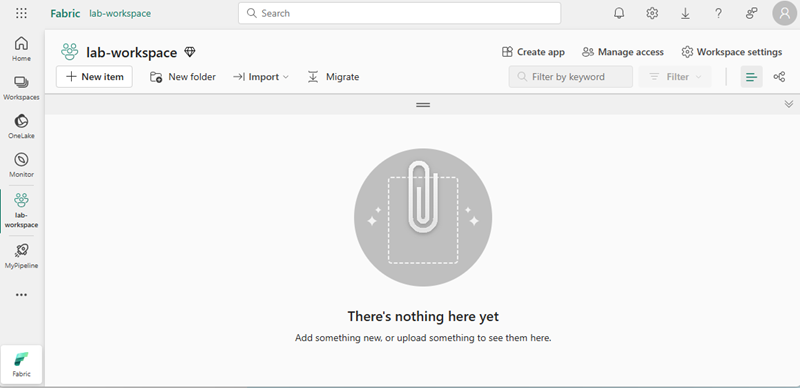

> Note: When you create a workspace, you automatically become a member of the Workspace Admin role. You can add a second user from your environment to the Workspace Viewer role to test functionality configured in these exercises. This can be done by selecting **Manage Access** within the workspace, then **Add people or groups**. This will allow the second user to view the workspace content.

#### Create a data warehouse
Next, create a data warehouse in the workspace you created:
1. On the menu bar on the left, select **Create**. In the *New page*, under the *Data Warehouse* section, select **Warehouse**. Give it a unique name of your choice.
> Note: If the **Create** option is not pinned to the sidebar, you need to select the ellipsis (…) option first.

After a minute or so, a new warehouse will be created:

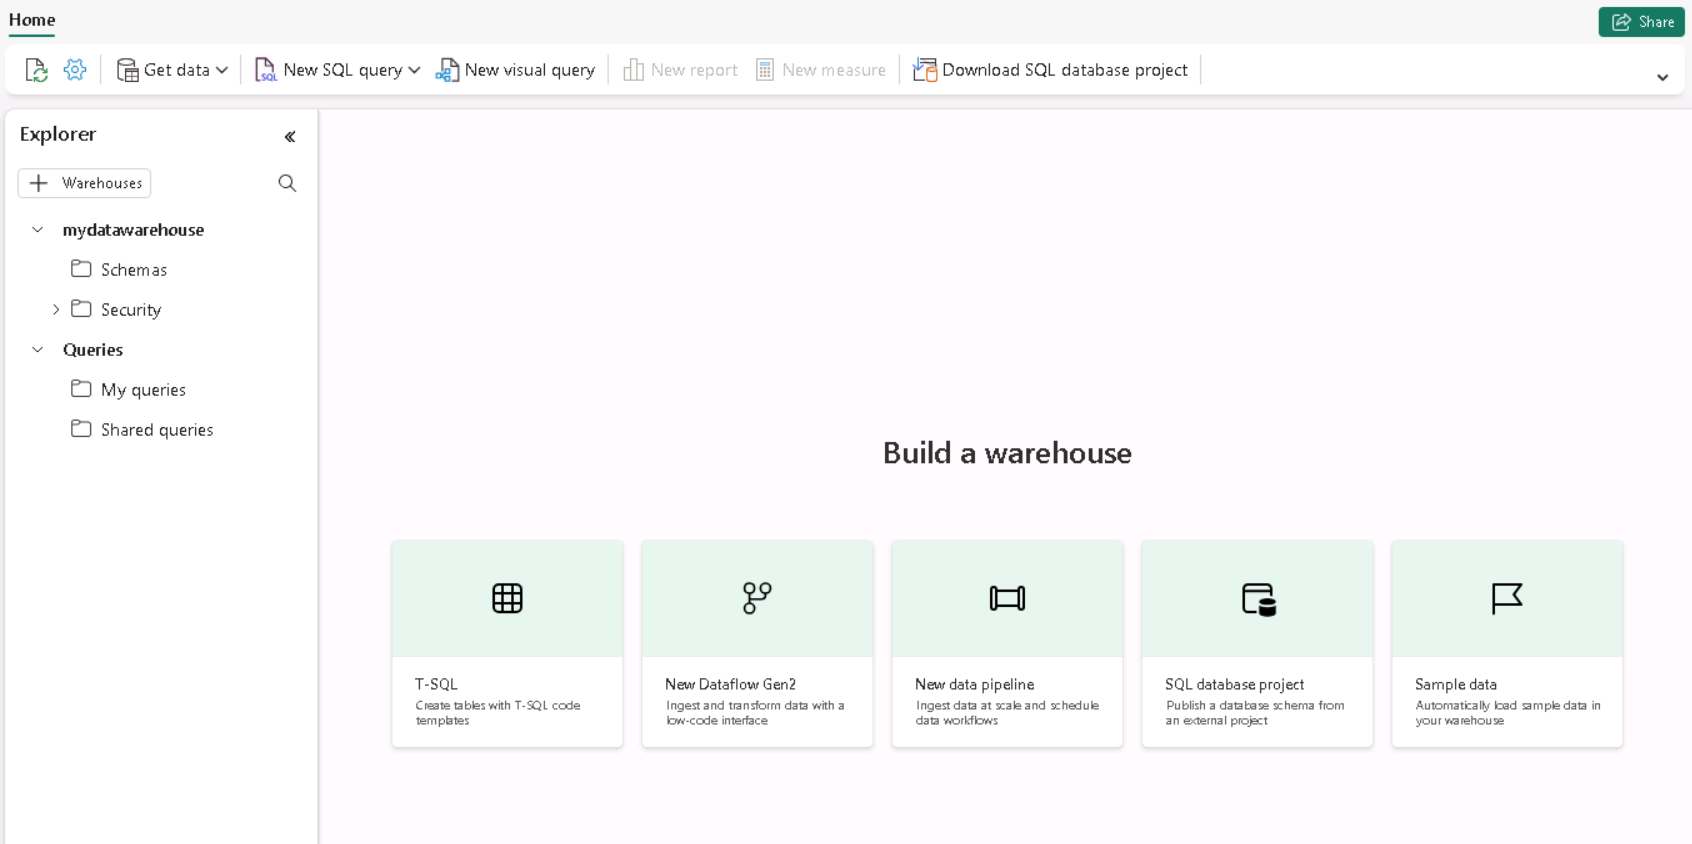

#### Apply dynamic data masking rules to columns in a table
Dynamic data masking rules are applied on individual columns at the table level so all queries are affected by the masking. Users who do not have explicit permissions to view confidential data see masked values in query results while users with explicit permission to view the data see it unobscured. There are four types of masks: default, email, random and custom string. In this exercise, you will apply a default mask, an email mask, and a custom string mask.
1. In your warehouse, select the **T-SQL** tile, and use the following T-SQL statements to create a table and to insert and view data.
    ```sql
    CREATE TABLE dbo.Customers
    (   
        CustomerID INT NOT NULL,   
        FirstName varchar(50) MASKED WITH (FUNCTION = 'partial(1,"XXXXXXX",0)') NULL,     
        LastName varchar(50) NOT NULL,     
        Phone varchar(20) MASKED WITH (FUNCTION = 'default()') NULL,     
        Email varchar(50) MASKED WITH (FUNCTION = 'email()') NULL   
    );
    
    INSERT dbo.Customers (CustomerID, FirstName, LastName, Phone, Email) VALUES
    (29485,'Catherine','Abel','555-555-5555','catherine0@adventure-works.com'),
    (29486,'Kim','Abercrombie','444-444-4444','kim2@adventure-works.com'),
    (29489,'Frances','Adams','333-333-3333','frances0@adventure-works.com');
    
    SELECT * FROM dbo.Customers;
    ```
When users who are restricted from seeing unmasked data query the table, the `FirstName` column will show the first letter of the string with XXXXXXX and none of the last characters. The `Phone` column will show xxxx. The `Email` column will show the first letter of the email address followed by `XXX@XXXX.com`. This approach ensures that sensitive data remains confidential, while still allowing restricted users to query the table.

2. Use the ▷ **Run** button to run the SQL script, which creates a new table named `Customers` in the `dbo` schema of the data warehouse.
3. Then, in the **Explorer** pane, expand **Schemas > dbo > Tables** and verify that the `Customers` table has been created. The `SELECT` statement returns unmasked data for you because as the workspace creator, you’re a member of the Workspace Admin role which can see unmasked data.
> Optional: If you connect as a test user that’s a member of the Viewer workspace role and run a SELECT statement on the Customers table, you’ll see the following results for the masked data.

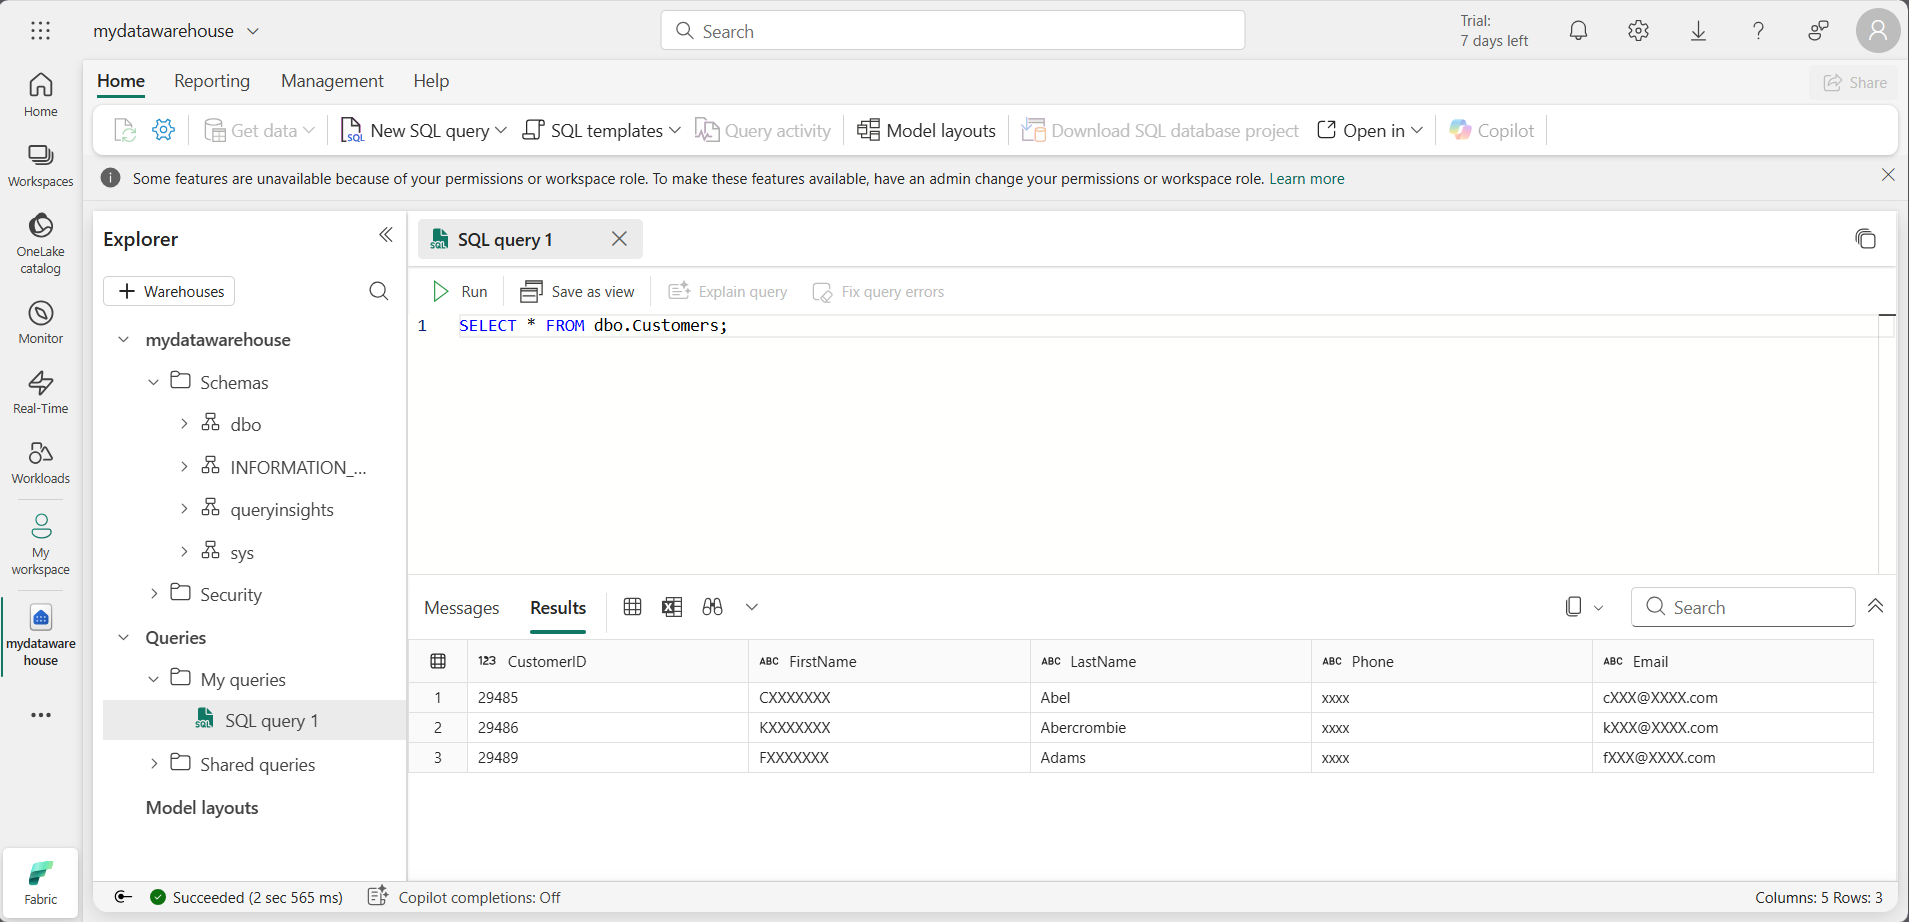

The test user hasn’t been granted UNMASK permission, so data returned for the FirstName, Phone, and Email columns is masked because those columns were defined with a mask in the `CREATE TABLE` statement.
#### Apply row-level security
Row-level security (RLS) can be used to limit access to rows based on the identity, or role of the user executing a query. In this exercise, you restrict access to rows by creating a security policy and a security predicate defined as an inline table-valued function.
1. In the warehouse you created in the last exercise, select the **New SQL Query** dropdown and select **New SQL Query**.
2. Create a table and insert data into it. To implement row-level security in a later step, replace `<username1>@<your_domain>.com` with either a fictitious user name or a real one from your environment (**Viewer** role), and replace `<username2>@<your_domain>.com` with your user name (**Admin** role).
    ```sql
    CREATE TABLE dbo.Sales  
    (  
        OrderID INT,  
        SalesRep VARCHAR(60),  
        Product VARCHAR(10),  
        Quantity INT  
    );
        
    --Populate the table with 6 rows of data, showing 3 orders for each test user. 
    INSERT dbo.Sales (OrderID, SalesRep, Product, Quantity) VALUES
    (1, '<username1>@<your_domain>.com', 'Valve', 5),   
    (2, '<username1>@<your_domain>.com', 'Wheel', 2),   
    (3, '<username1>@<your_domain>.com', 'Valve', 4),  
    (4, '<username2>@<your_domain>.com', 'Bracket', 2),   
    (5, '<username2>@<your_domain>.com', 'Wheel', 5),   
    (6, '<username2>@<your_domain>.com', 'Seat', 5);  
        
    SELECT * FROM dbo.Sales;  
    ```
3. Use the ▷ Run button to run the SQL script, which creates a new table named Sales in the dbo schema of the data warehouse.
4. Then, in the **Explorer** pane, expand **Schemas > dbo > Tables** and verify that the **Sales** table has been created.
5. Create a new schema, a security predicate defined as a function, and a security policy.
    ```sql
    --Create a separate schema to hold the row-level security objects (the predicate function and the security policy)
    CREATE SCHEMA rls;
    GO
    
    /*Create the security predicate defined as an inline table-valued function.
    A predicate evaluates to true (1) or false (0). This security predicate returns 1,
    meaning a row is accessible, when a row in the SalesRep column is the same as the user
    executing the query.*/   
    --Create a function to evaluate who is querying the table
    CREATE FUNCTION rls.fn_securitypredicate(@SalesRep AS VARCHAR(60)) 
        RETURNS TABLE  
    WITH SCHEMABINDING  
    AS  
        RETURN SELECT 1 AS fn_securitypredicate_result   
    WHERE @SalesRep = USER_NAME();
    GO   
    /*Create a security policy to invoke and enforce the function each time a query is run on the Sales table.
    The security policy has a filter predicate that silently filters the rows available to 
    read operations (SELECT, UPDATE, and DELETE). */
    CREATE SECURITY POLICY SalesFilter  
    ADD FILTER PREDICATE rls.fn_securitypredicate(SalesRep)   
    ON dbo.Sales  
    WITH (STATE = ON);
    GO
    ```
6. Use the ▷ **Run** button to run the SQL script
7. Then, in the **Explorer** pane, expand **Schemas > rls > Functions > Table-valued Functions**, and verify that the function has been created.
> Optional: If you connect as the user you replaced `<username1>@<your_domain>.com` with, and run a `SELECT` statement on the **Sales** table, you’ll see the following results for row-level security.

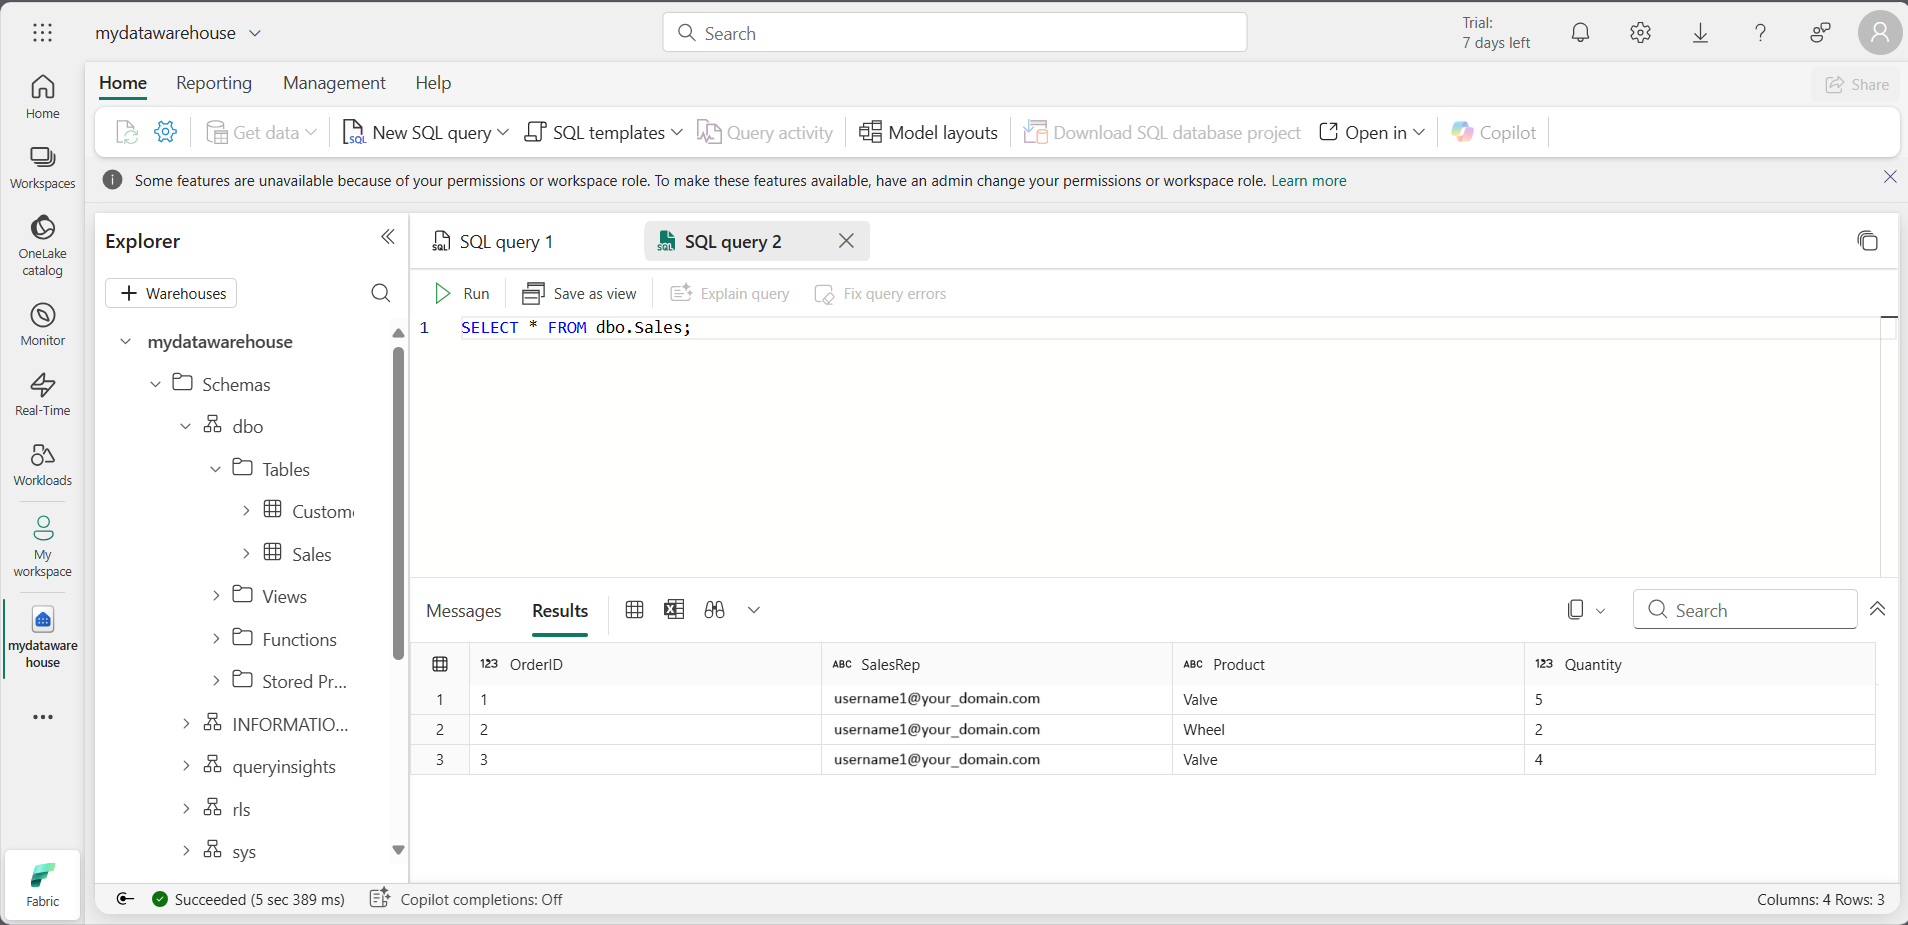

#### Implement column-level security
Column-level security allows you to designate which users can access specific columns in a table. It’s implemented by issuing a `GRANT` or `DENY` statement on a table specifying a list of columns and the user or role that can or cannot read them. To streamline access management, assign permissions to roles in lieu of individual users. In this exercise, you will create a table, grant access to a subset of columns on the table, and test that restricted columns aren’t viewable by a user other than yourself.
1. In the warehouse you created in the earlier exercise, select the **New SQL Query** dropdown, then select **New SQL Query**.
2. Create a table and insert data into the table.
    ```sql
    CREATE TABLE dbo.Orders
    (   
        OrderID INT,   
        CustomerID INT,  
        CreditCard VARCHAR(20)      
    );   
    INSERT dbo.Orders (OrderID, CustomerID, CreditCard) VALUES
    (1234, 5678, '111111111111111'),
    (2341, 6785, '222222222222222'),
    (3412, 7856, '333333333333333');   
    SELECT * FROM dbo.Orders;
    ```
3. Deny permission to view a column in the table. The T-SQL statement prevents `<username1>@<your_domain>.com` from seeing the `CreditCard` column in the `Orders` table. In the `DENY` statement, replace `<username1>@<your_domain>.com` with the user name of a user who has Viewer permissions on the workspace.
    ```sql
    DENY SELECT ON dbo.Orders (CreditCard) TO [<username1>@<your_domain>.com];
    ```
> Optional: If you connect as the user you replaced `<username1>@<your_domain>.com` with, and run a `SELECT` statement on the `Orders` table, you’ll see the following results for column-level security.

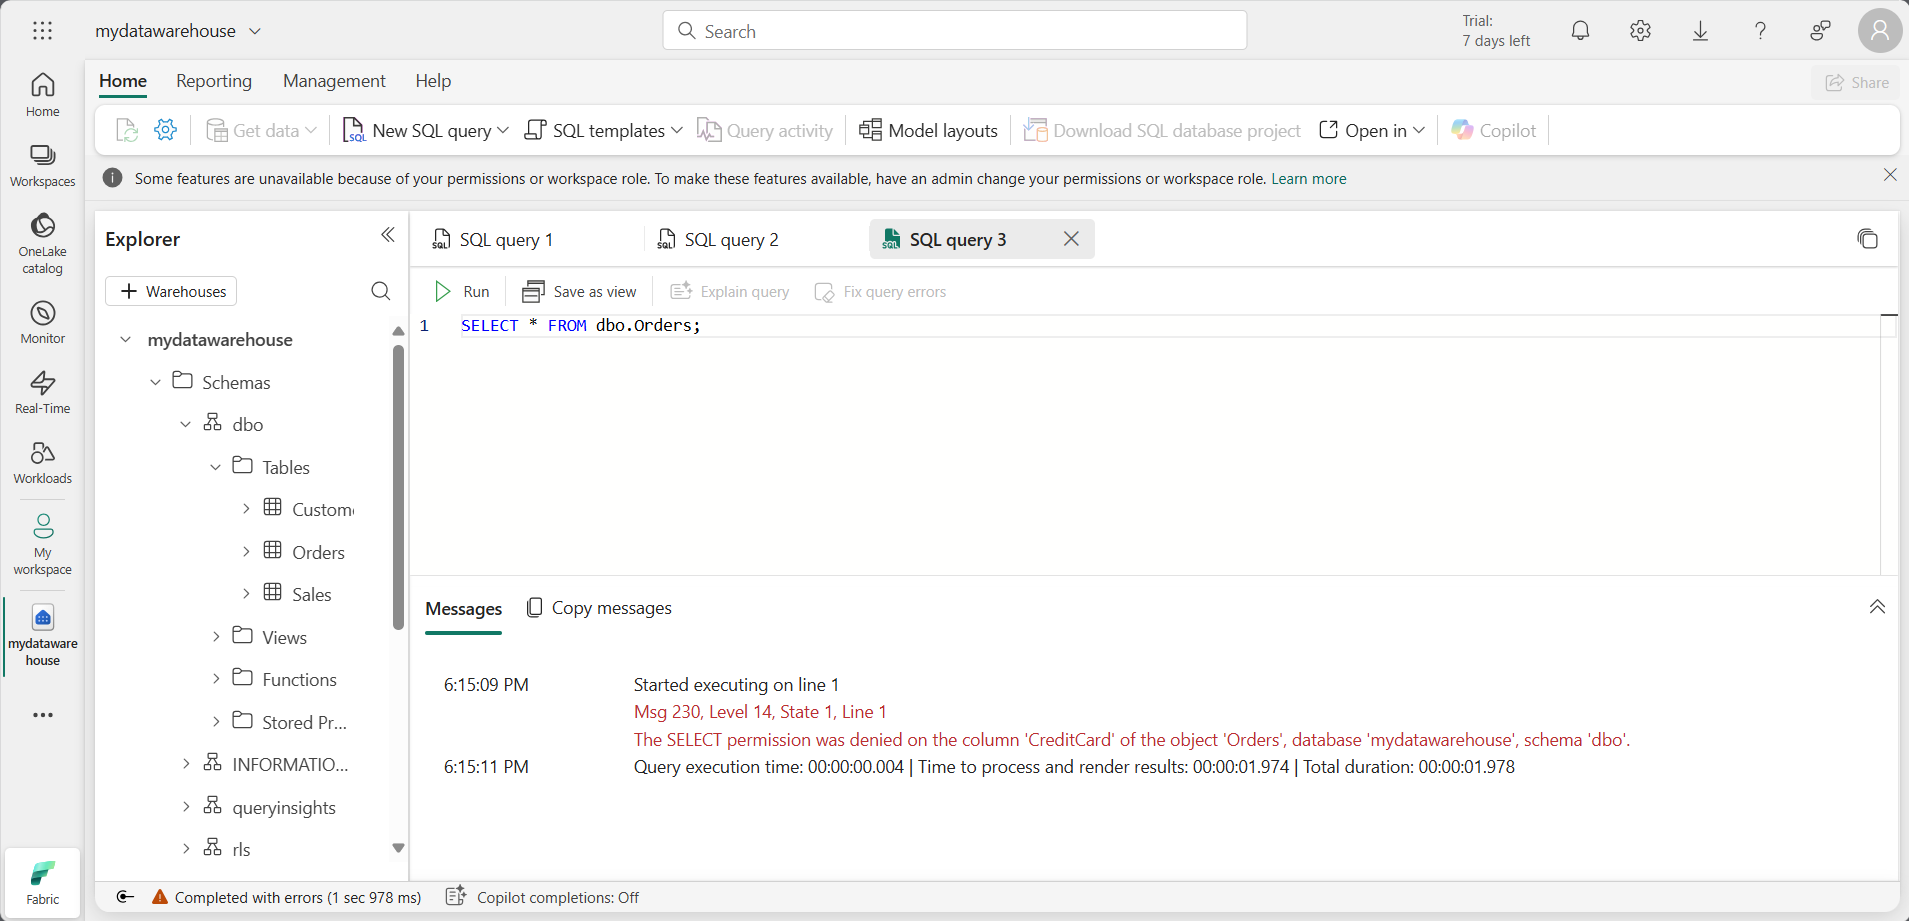

The error shown in the screenshot occurs because access to the `CreditCard` column has been restricted. If you select only the `OrderID` and `CustomerID` columns, the query will execute successfully.
#### Configure SQL granular permissions using T-SQL
Fabric has a permissions model that allows you to control access to data at the workspace level, and at the item level. When you need more granular control of what users can do with securables in a Fabric warehouse, you can use the standard SQL data control language (DCL) commands `GRANT`,`DENY` and, `REVOKE`. In this exercise, you will create objects, secure them using `GRANT`, and `DENY`, and then run queries to view the effect of applying granular permissions.
1. In the warehouse you created in the earlier exercise, select the **New SQL Query** dropdown. Select **New SQL Query**.
2. Create a stored procedure and a table. Then execute the procedure and query the table.
    ```sql
    CREATE PROCEDURE dbo.sp_PrintMessage
    AS
    PRINT 'Hello World.';
    GO   
    CREATE TABLE dbo.Parts
    (
        PartID INT,
        PartName VARCHAR(25)
    );
    
    INSERT dbo.Parts (PartID, PartName) VALUES
    (1234, 'Wheel'),
    (5678, 'Seat');
    GO
    
    /*Execute the stored procedure and select from the table and note the results you get
    as a member of the Workspace Admin role. Look for output from the stored procedure on 
    the 'Messages' tab.*/
    EXEC dbo.sp_PrintMessage;
    GO   
    SELECT * FROM dbo.Parts
    ```
3. Next, `DENY SELECT` permissions on the table to a user who is a member of the **Workspace Viewer** role and `GRANT EXECUTE` on the procedure to the same user. Replace `<username1>@<your_domain>.com` with the user name of a user who has **Viewer** permissions on the workspace.
    ```sql
    DENY SELECT on dbo.Parts to [<username1>@<your_domain>.com];

    GRANT EXECUTE on dbo.sp_PrintMessage to [<username1>@<your_domain>.com];
    ```
> Optional: If you connect as the user you replaced `<username1>@<your_domain>.com` with, execute the stored procedure and run a `SELECT` statement on the `Parts` table, you’ll see the following results for granular permissions.

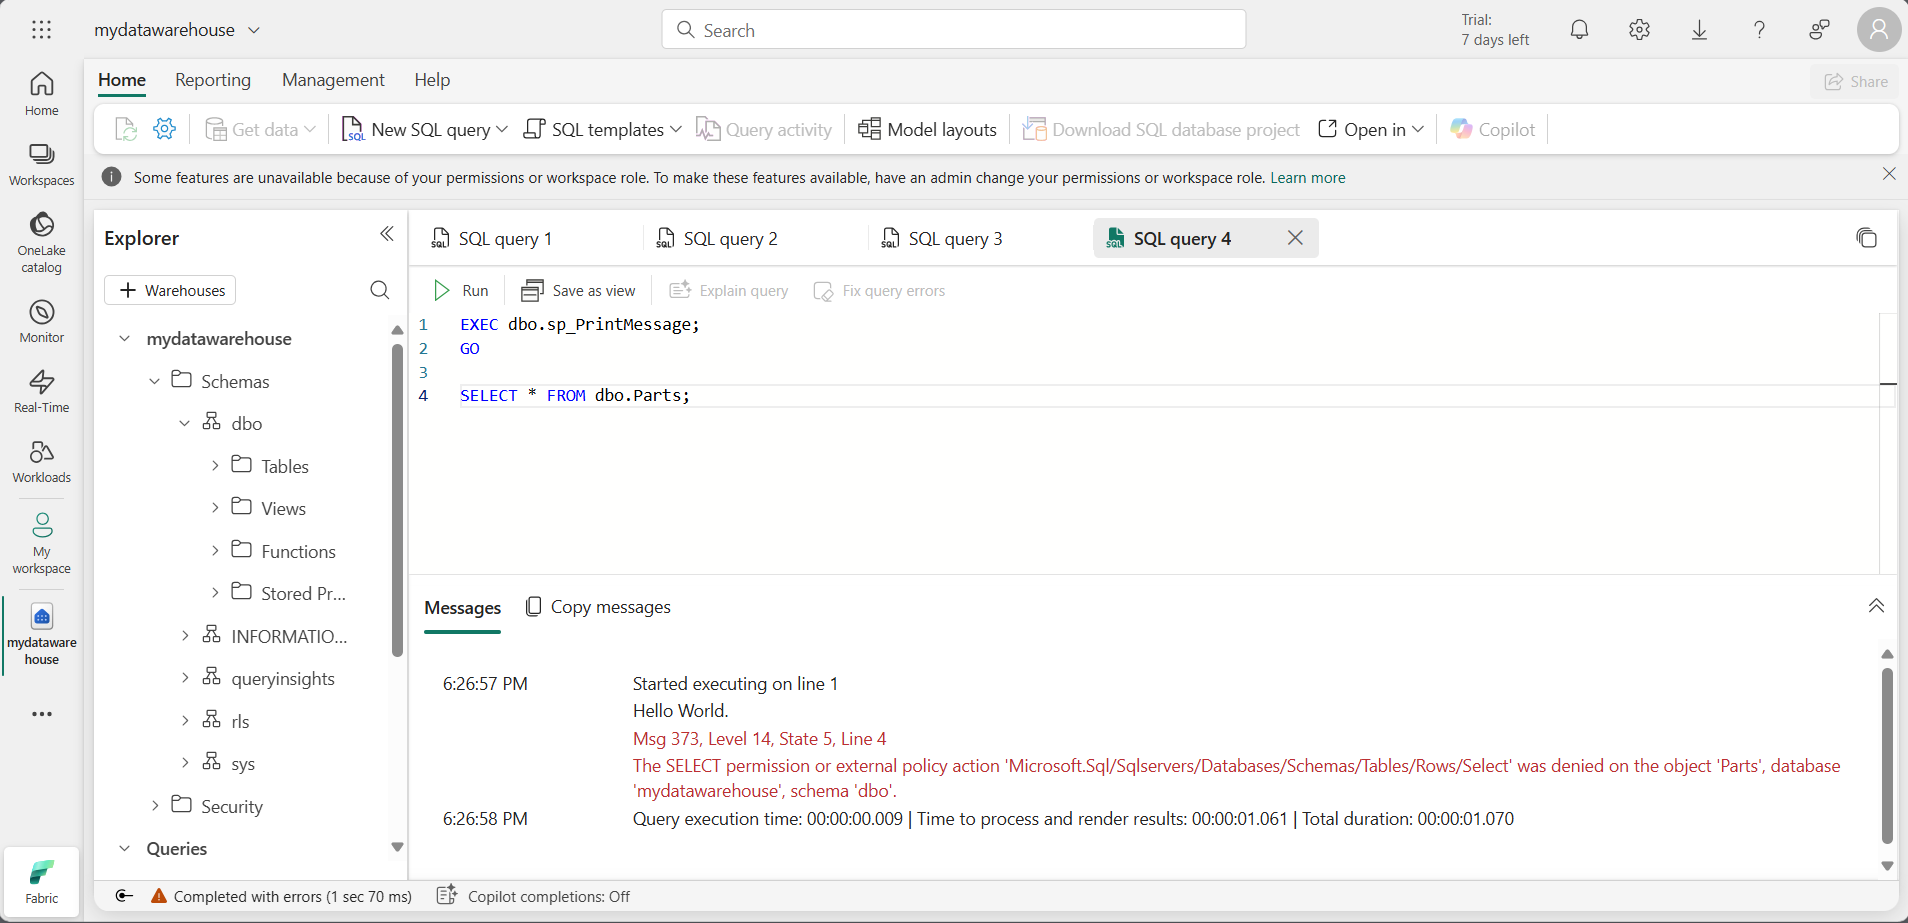

#### Clean up resources
In this exercise, you applied dynamic data masking rules to columns in a table, applied row-level security, implemented column-level security and, configured SQL granular permissions using T-SQL.
1. In the left navigation bar, select the icon for your workspace to view all of the items it contains.
2. In the menu on the top toolbar, select **Workspace settings**.
3. In the **General** section, select **Remove this workspace**.

### **Module assessment**

#### 1. What is the primary advantage of Dynamic Data Masking (DDM)?

**A) It limits data exposure by obscuring sensitive information in real time.** \
B) It changes the actual data in the database. \
C) It requires complex coding to implement.

#### 2. What is the purpose of a security predicate function in Row-Level Security (RLS)?

**A) It determines whether a row is accessible to a user based on certain conditions.** \
B) It enables type conversions in predicate functions. \
C) It allows users to run ad hoc queries.

#### 3. What happens when a user is granted a permission and then denied the same permission in a warehouse?

A) The `GRANT` statement supersedes the `DENY`, and the user will have access to the specific object. \
**B) The `DENY` always supersedes the `GRANT`, and the user is denied access to the specific object.** \
C) The user has both permissions, and it causes a conflict.

## **Govern analytics data in Microsoft Fabric**

### **Introduction**

#### Why Governance Matters
Before users can trust data, they need answers to questions like:

✅ Is this data trustworthy? \
✅ Is this data sensitive? \
✅ Is this data approved for business use? \
✅ Who owns it? \
✅ Is it documented?

Without governance:
> All Data Looks The Same

which leads to:

❌ Wrong reports \
❌ Duplicate datasets \
❌ Sensitive data exposure \
❌ Reduced trust in analytics
#### What Governance Does
Governance addresses two major goals:
##### 1. Protect Data
Ensures:

✅ Sensitive data is identified \
✅ Access is controlled \
✅ Compliance requirements are met
##### 2. Help Users Find the Right Data
Ensures:

✅ Trusted assets are easy to identify \
✅ Data is discoverable \
✅ Business context is available
##### Exam Favorite
> Governance → Protection + Discoverability

#### OneLake Catalog
The primary governance experience in Microsoft Fabric is **OneLake Catalog**
##### Purpose
Provides a central location to:

✅ Discover data assets \
✅ Classify data \
✅ Endorse trusted assets \
✅ Document assets \
✅ Monitor governance

Think of it as **Fabric Data Catalog** for your organization.
#### Four Major Governance Capabilities
This module focuses on:
> Sensitivity Labels → Endorsement → Documentation → Monitoring

#### 1. Sensitivity Labels
##### Purpose
Classify information by sensitivity.
##### Examples
* Public
* Internal
* Confidential
* Highly Confidential
##### Benefits
✅ Data protection \
✅ Compliance support \
✅ User awareness \
✅ Security enforcement
##### Example
* Patient medical records: **Highly Confidential**
* Marketing campaign data: **Internal**
##### Exam Tip
Sensitivity labels signal **how sensitive the data is**
#### 2. Endorsement
##### Purpose
Identify trusted data assets.

Without endorsement:
> Users guess which dataset to use

With endorsement:
> Users Know Which assets are trusted

##### Benefits
✅ Increased confidence \
✅ Reduced duplication \
✅ Better self-service analytics
##### Exam Favorite
Endorsement answers:
* Can I Trust This Asset?
#### 3. Documentation
##### Purpose
Improve discoverability and understanding.

Documentation can include:

✅ Descriptions \
✅ Business definitions \
✅ Ownership information \
✅ Usage guidance
##### Example
Dataset:
* Sales Performance

Documentation explains:
* What It Measures
* Who Owns It
* How To Use It
##### Benefits
✅ Faster discovery \
✅ Better adoption \
✅ Reduced confusion
#### 4. Governance Monitoring
##### Purpose
Evaluate governance posture.
##### Track
✅ Sensitive assets \
✅ Endorsed assets \
✅ Documentation coverage \
✅ Governance compliance
##### Benefit
Helps administrators identify:
> Governance Gaps

before they become problems.
#### Governance Workflow
> Create Data → Apply Sensitivity Labels → Document Assets → Endorse Trusted Assets → Monitor Governance

#### Example Scenario
Healthcare organization stores:

✅ Patient records \
✅ Insurance claims \
✅ Clinical data

Governance actions:
##### Sensitive Data
* Patient Records → Highly Confidential
##### Trusted Dataset
* Enterprise Claims Model → Endorsed
##### Documentation
* Describe Tables
* Define Ownership
* Explain Usage
##### Monitoring
* Track Governance Adoption
#### Governance vs Security
A common exam distinction.
##### Security
Controls:
* Who Can Access Data
##### Governance
Controls:
* How Data Is Classified, Trusted, Found, And Managed
##### Security Example
* RLS
* CLS
* Permissions
##### Governance Example
* Labels
* Endorsement
* Catalog
* Documentation
#### OneLake Catalog Benefits
✅ Centralized discovery \
✅ Trust signals \
✅ Metadata visibility \
✅ Sensitive data tracking \
✅ Better self-service analytics \
✅ Improved governance posture
#### Exam Quick Facts
✅ Governance helps users find and trust the right data \
✅ Governance also protects sensitive information \
✅ OneLake Catalog is the governance hub in Microsoft Fabric \
✅ Key governance capabilities:
* Sensitivity Labels
* Endorsement
* Documentation
* Monitoring

✅ Sensitivity labels classify data sensitivity \
✅ Endorsement identifies trusted assets \
✅ Documentation improves discoverability \
✅ Monitoring evaluates governance posture \
✅ Governance complements security controls
#### Memory Trick
##### Governance Formula
> Protect + Trust + Discover + Monitor

##### OneLake Catalog Formula
> Sensitivity Labels + Endorsement + Documentation + Monitoring

##### ⭐ Most Tested Concept:
Governance in the OneLake Catalog helps protect sensitive data and helps users confidently discover and choose the correct data assets.

### **Classify and protect data in Microsoft Fabric**

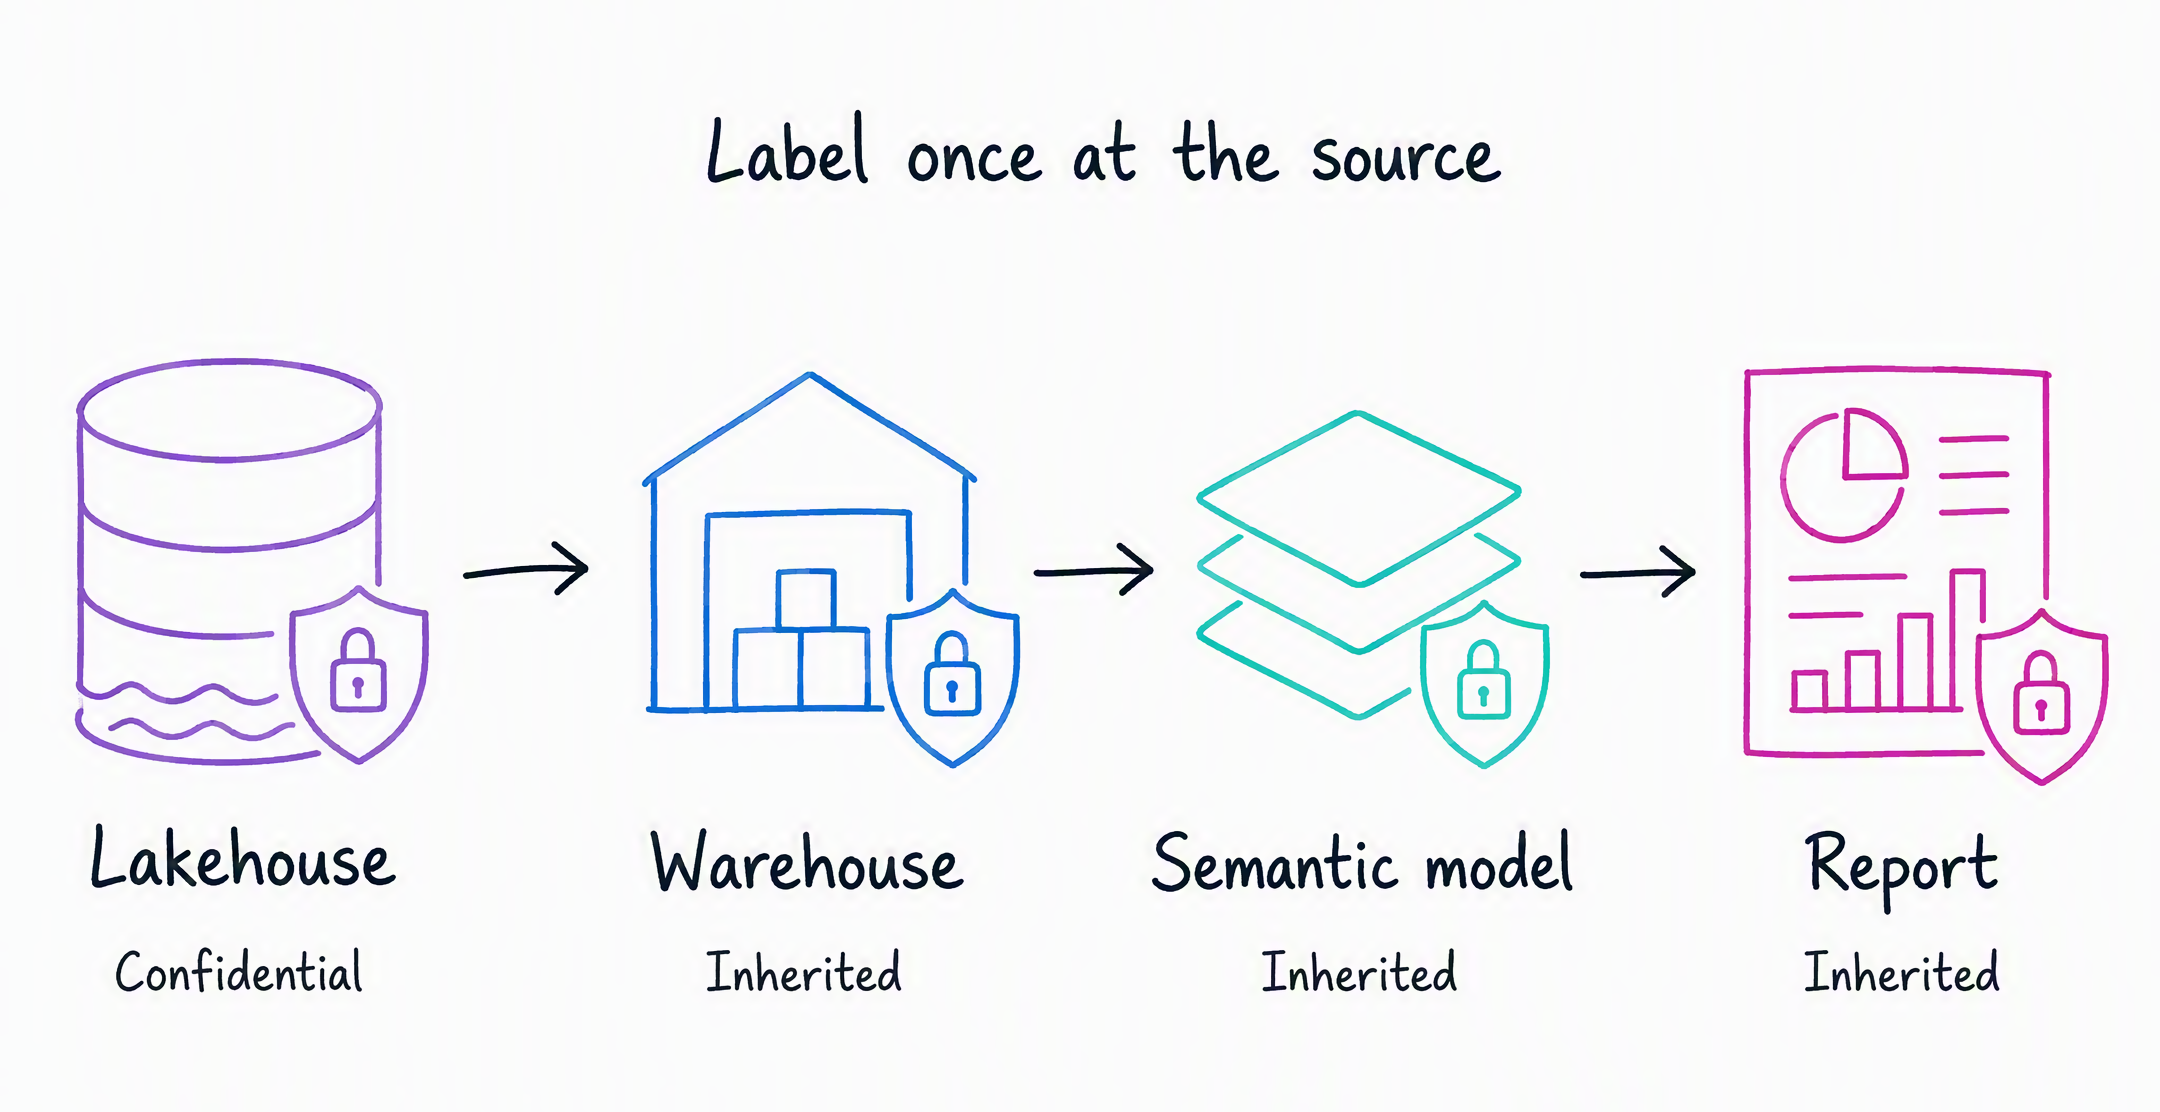

#### Why Data Classification Matters
Without classification:

All Data Looks The Same


Users cannot tell:

✅ Whether data is sensitive \
✅ Whether data is safe to share \
✅ Whether special handling is required
##### Example
A lakehouse contains:
> Employee Salaries

If it isn't classified:

❌ Users may export it \
❌ Users may share it \
❌ Sensitive information may leak
##### Key Exam Concept
Classification makes data sensitivity visible before someone accesses or shares it.
#### Sensitivity Labels
##### What Are Sensitivity Labels?
Sensitivity labels are:
* Metadata Tags

that classify Fabric items based on sensitivity.
##### Common Labels
* Public
* General
* Confidential
* Highly Confidential
##### Important
Organizations define:

✅ Label names \
✅ Classification policies \
✅ Protection rules
#### Purpose of Sensitivity Labels
Sensitivity labels help users understand:
> How Sensitive The Data Is

before using it.
##### Benefits
✅ Data protection \
✅ Compliance support \
✅ User awareness \
✅ Consistent classification \
✅ Governance
#### Example Classifications
##### Public
Can be broadly shared.

Example:
* Public Product Catalog
##### General
Internal business data.

Example:
* Team Meeting Metrics
##### Confidential
Restricted business information.

Example:
* Financial Forecasts
##### Highly Confidential
Highly sensitive information.

Example:
* Patient Records
* Employee Salaries
* Credit Card Data
#### Where Labels Appear
Labels are visible throughout:

✅ Fabric portal \
✅ Fabric items \
✅ Catalog experiences
##### Benefit
Users immediately see:
> Sensitivity Level

before opening an asset.
#### Protection Policies
Labels can do more than classification.

They can also support:

✅ Access restrictions \
✅ Protection controls \
✅ Compliance enforcement
##### Exam Tip
Sensitivity labels may be connected to protection policies.
#### Label Inheritance
Labels automatically travel with data.
##### Example Data Flow
> Lakehouse → Warehouse → Semantic Model → Report

If the lakehouse is **Confidential** the label can flow downstream.
##### Result
Classification remains consistent.
#### Classification Starts at the Source
Best practice:

✅ Label data early
##### Example
Apply label at **Lakehouse**

Then protection propagates through:

✅ Warehouses \
✅ Semantic Models \
✅ Reports
##### Exam Favorite
Labeling a source item helps protect all downstream artifacts.
#### Labels During Export
Sensitivity labels travel with exported content.

Supported paths include:

✅ Excel \
✅ PDF \
✅ PowerPoint \
✅ Power BI Desktop files
##### Example
* Report Label: **Confidential**
* Export to: Excel
* Excel file remains: **Confidential**
##### Exam Tip
Labels persist across supported export paths.
#### When Should Data Be Classified?
Classify whenever data could cause harm if misused.
##### Personally Identifiable Information (PII)
Examples:
* Names
* Addresses
* Phone Numbers
* Email Addresses
##### Financial Data
Examples:
* Salaries
* Bank Accounts
* Credit Cards
##### Healthcare Data
Examples:
* Patient Records
* Medical History
##### Internal Business Data
Examples:
* Sales Forecasts
* Strategic Plans
* HR Data
#### Classify Even Exploratory Data
Another common exam point.

Even temporary data benefits from:

✅ Baseline classification
##### Why?
Because:
> No Label

means:
> Consumers Have No Sensitivity Guidance

#### If Sensitivity Labels Are Not Available
Organizations may not have labels configured yet.

Alternative approaches:

✅ Clear descriptions \
✅ Workspace naming conventions \
✅ Tags \
✅ Metadata
##### Example
Workspace:
```
FINANCE_CONFIDENTIAL
```
Dataset Description:
> Contains Employee Salary Information

##### Important
These methods:

✅ Improve awareness \
❌ Do not enforce protection
#### Governance Value of Classification
Classification helps users answer:
* Can I Share This?
* Should I Use This?
* Is This Sensitive?

Without classification:

❌ Guesswork

With classification:

✅ Informed decisions
#### Classification vs Security
A common exam comparison.
##### Classification
Answers:
* How Sensitive Is This Data?
##### Tools
✅ Sensitivity Labels \
✅ Tags \
✅ Metadata
##### Security
Answers:
* Who Can Access The Data?
##### Tools
✅ Permissions \
✅ RLS \
✅ CLS \
✅ OneLake Security
##### Exam Tip
Classification supports security but does not replace it.
#### End-to-End Example
> Patient Records → Highly Confidential Label → Lakehouse → Warehouse → Semantic Model → Report → Excel Export

##### Result
✅ Sensitivity remains visible throughout the lifecycle.
#### Exam Quick Facts
✅ Sensitivity labels are metadata tags \
✅ Common labels:
* Public
* General
* Confidential
* Highly Confidential

✅ Labels help users identify sensitive data \
✅ Labels can support protection policies \
✅ Labels are visible in the Fabric portal \
✅ Labels automatically inherit downstream \
✅ Labels travel with supported exports:
* Excel
* PDF
* PowerPoint
* Power BI Desktop

✅ Apply labels as early as possible \
✅ Classification is important for:
* PII
* Financial Data
* Healthcare Data
* Internal Business Data

✅ If labels aren't available, use:
* Descriptions
* Naming conventions
* Tags

✅ Classification provides awareness; security provides enforcement
#### Memory Trick
##### Classification Flow
> Label Once → Protect Everywhere

##### Most Tested Concept ⭐
Sensitivity labels classify data by sensitivity level and automatically flow through downstream Fabric assets and supported export formats, allowing classification to start at the data source.

### **Endorse and document data assets**

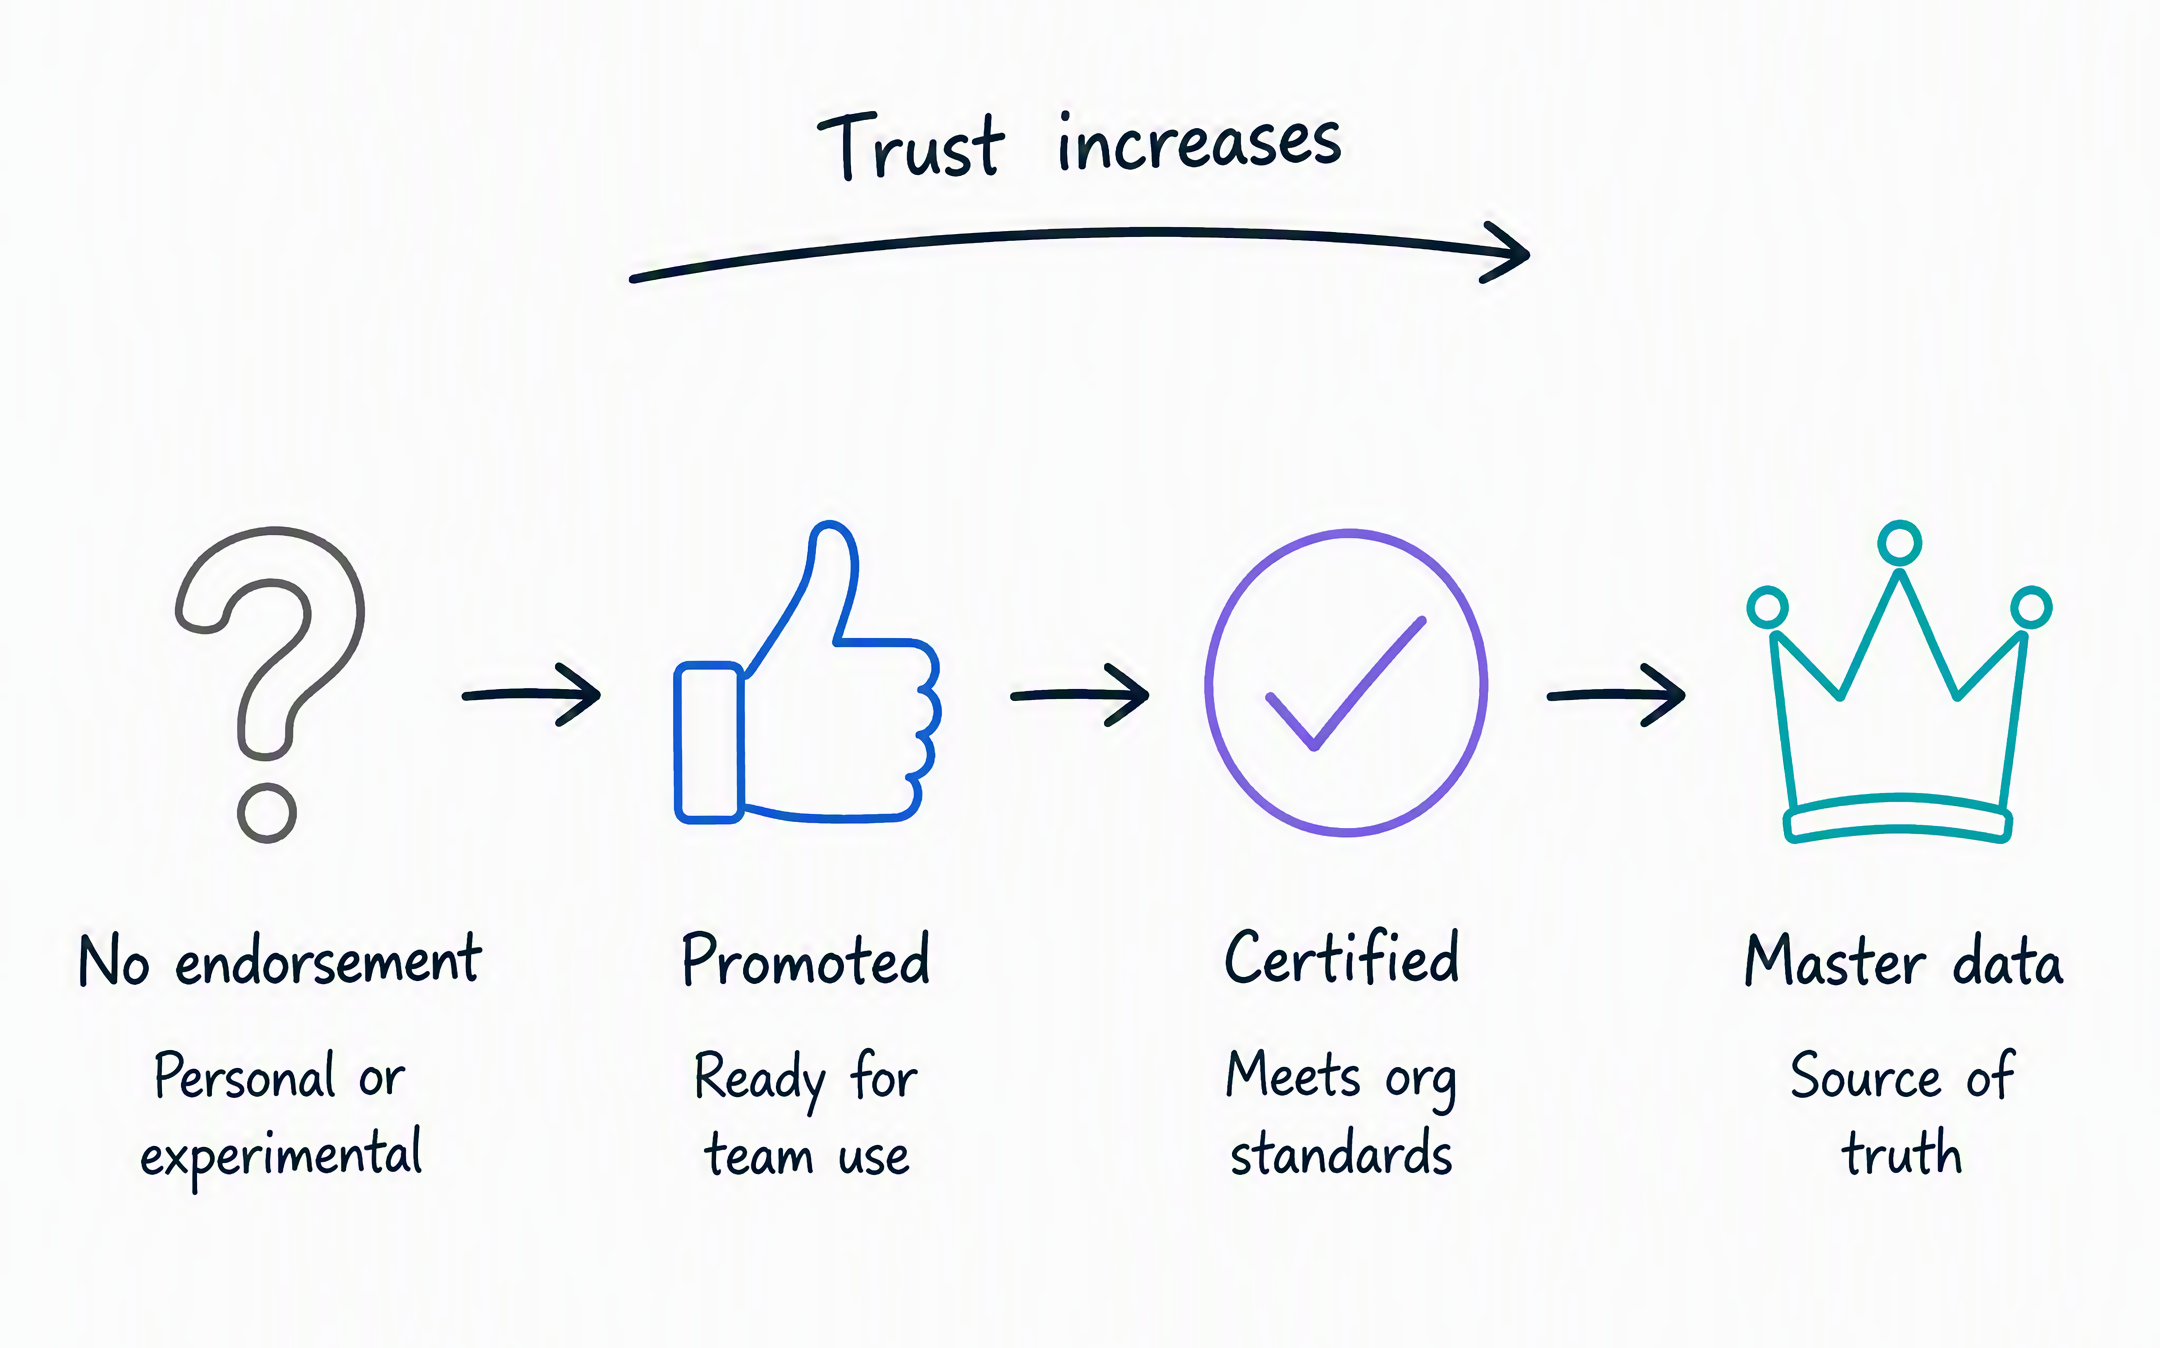

#### Why Endorsement Matters
Without endorsement:
> Certified Dataset = Personal Test Dataset

Both appear similar to users.
##### Risk
A business user might build a report using:

❌ An old copy \
❌ A personal dataset \
❌ An experimental model

instead of:

✅ The approved source
##### Key Exam Concept
Endorsement provides visible trust signals that help users choose the correct data asset.
#### What is Endorsement?
Endorsement is a Fabric governance feature that identifies:
* Trusted Data Assets
##### Benefits
✅ Signals trust \
✅ Improves discoverability \
✅ Prioritizes assets in searches \
✅ Encourages reuse of approved data
#### Endorsement Levels
Fabric supports three endorsement levels.
##### 1. Promoted
**Meaning**
> Ready For Team Use

The item has been:

✅ Reviewed \
✅ Tested \
✅ Considered useful

**Who Can Apply?**

✅ Any user with write access

**Exam Favorite**

Promoted = Team-ready.
##### 2. Certified
**Meaning**
> Meets Organizational Standards

Represents:

✅ Officially approved assets \
✅ Trusted production data \
✅ Governance-reviewed content

**Who Can Apply?**

✅ Authorized reviewers only

**Exam Tip**

Certified is a stronger trust signal than Promoted.
##### 3. Master Data
**Meaning**
> Authoritative Source

for core enterprise data.

Examples:

✅ Customer master \
✅ Product master \
✅ Employee master

**Who Can Apply?**

✅ Authorized reviewers

**Restriction**

Only applies to:
> Data-Holding Items

such as:

✅ Lakehouses \
✅ Semantic Models

**Exam Favorite**

Master Data indicates the authoritative enterprise source.
#### Endorsement Hierarchy
> Promoted → Certified → Master Data

Increasing trust and governance.
#### No Endorsement Is Also a Signal
Important exam concept.

If an item has **No Endorsement**

it often means:
* Experimental
* Personal
* Unreviewed
* In Development
##### Exam Tip
Absence of endorsement can communicate low trust.
#### Endorsement Summary
| Level       | Meaning               | Who Can Apply              |
| ----------- | --------------------- | -------------------------- |
| Promoted    | Team-ready            | Any user with write access |
| Certified   | Organization-approved | Authorized reviewers       |
| Master Data | Authoritative source  | Authorized reviewers       |

#### Metadata and Discoverability
Endorsement signals trust.

Metadata provides:
> Understanding

Together they help users answer:
> Should I Use This Asset?

#### Types of Metadata
Fabric supports several metadata categories.
##### 1. Descriptions
**Purpose**

Explain:

✅ What the data contains \
✅ What it is used for \
✅ How it should be used

**Example**
* Contains validated monthly sales performance data used for executive reporting.

**Benefit**

Users evaluate assets before opening them.

**Exam Tip**

Descriptions improve discoverability.
##### 2. Tags
**Purpose**

Categorize assets.

Tags can represent:

✅ Projects \
✅ Fiscal years \
✅ Business initiatives \
✅ Refresh schedules \
✅ Teams

**Examples**
* FY2026
* Finance
* DailyRefresh
* CustomerAnalytics

**Benefit**

Users can:

✅ Search \
✅ Filter \
✅ Find relevant assets quickly
##### 3. Domains and Subdomains
**Purpose**

Organize workspaces by business area.

**Example Domains**
* Sales
* Finance
* Operations
* Human Resources

**Example Subdomains**
> Sales → Retail Sales

> Sales → Online Sales

**Benefits**

✅ Ownership boundaries \
✅ Better organization \
✅ Easier discovery \
✅ Clear accountability

**Exam Tip**
* Domains organize workspaces.
* Tags organize individual items.
##### 4. Lineage
**Purpose**

Show data flow.

Lineage answers:
> Where Did This Data Come From?

Example:
> Lakehouse → Warehouse → Semantic Model → Report

**Benefits**

✅ Trust verification \
✅ Root-cause analysis \
✅ Dependency understanding \
✅ Governance transparency

**Exam Favorite**

Lineage reveals data origins and dependencies.
#### Metadata Benefits
Good metadata helps prevent:

❌ Duplicate datasets \
❌ Reporting errors \
❌ Misuse of data \
❌ Building on untrusted sources

Instead it promotes:

✅ Reuse \
✅ Trust \
✅ Discoverability \
✅ Governance
#### Governance Workflow
> Create Asset → Add Description → Apply Tags → Assign Domain → Review Lineage → Promote → Certify

#### Example Scenario
A revenue semantic model:
##### Description
Certified source for quarterly revenue reporting.
##### Tags
* Finance
* QuarterlyReporting
* FY2026
##### Domain
Finance
##### Endorsement
Certified
##### Result
Users can immediately determine:

✅ Trusted \
✅ Finance-owned \
✅ Intended purpose \
✅ Data source lineage
#### Endorsement vs Metadata
| Governance Tool | Purpose                        |
| --------------- | ------------------------------ |
| Endorsement     | Signals trust                  |
| Description     | Explains meaning               |
| Tags            | Categorizes assets             |
| Domains         | Organizes business areas       |
| Lineage         | Shows origins and dependencies |

#### Exam Quick Facts
✅ Endorsement marks trusted assets \
✅ Endorsed assets get priority in catalog search \
✅ Three endorsement levels:
* Promoted
* Certified
* Master Data

✅ Promoted = Team-ready \
✅ Certified = Organizationally approved \
✅ Master Data = Authoritative source \
✅ Master Data applies only to data items \
✅ Missing endorsement can signal experimental or unreviewed assets \ 
✅ Metadata improves discoverability \
✅ Descriptions explain purpose and contents \
✅ Tags support filtering and search \
✅ Domains organize workspaces by business function \
✅ Lineage shows data flow and dependencies \
✅ Good governance helps users choose the correct data asset 
#### Memory Trick
##### Trust Hierarchy
> Promoted → Certified → Master Data

##### Metadata Formula
> Description + Tags + Domains + Lineage → Discoverability

##### ⭐ Most Tested Concept:
Endorsement signals trust, while metadata (descriptions, tags, domains, and lineage) helps users understand, discover, and evaluate data assets before using them.

### **Monitor and manage governance**

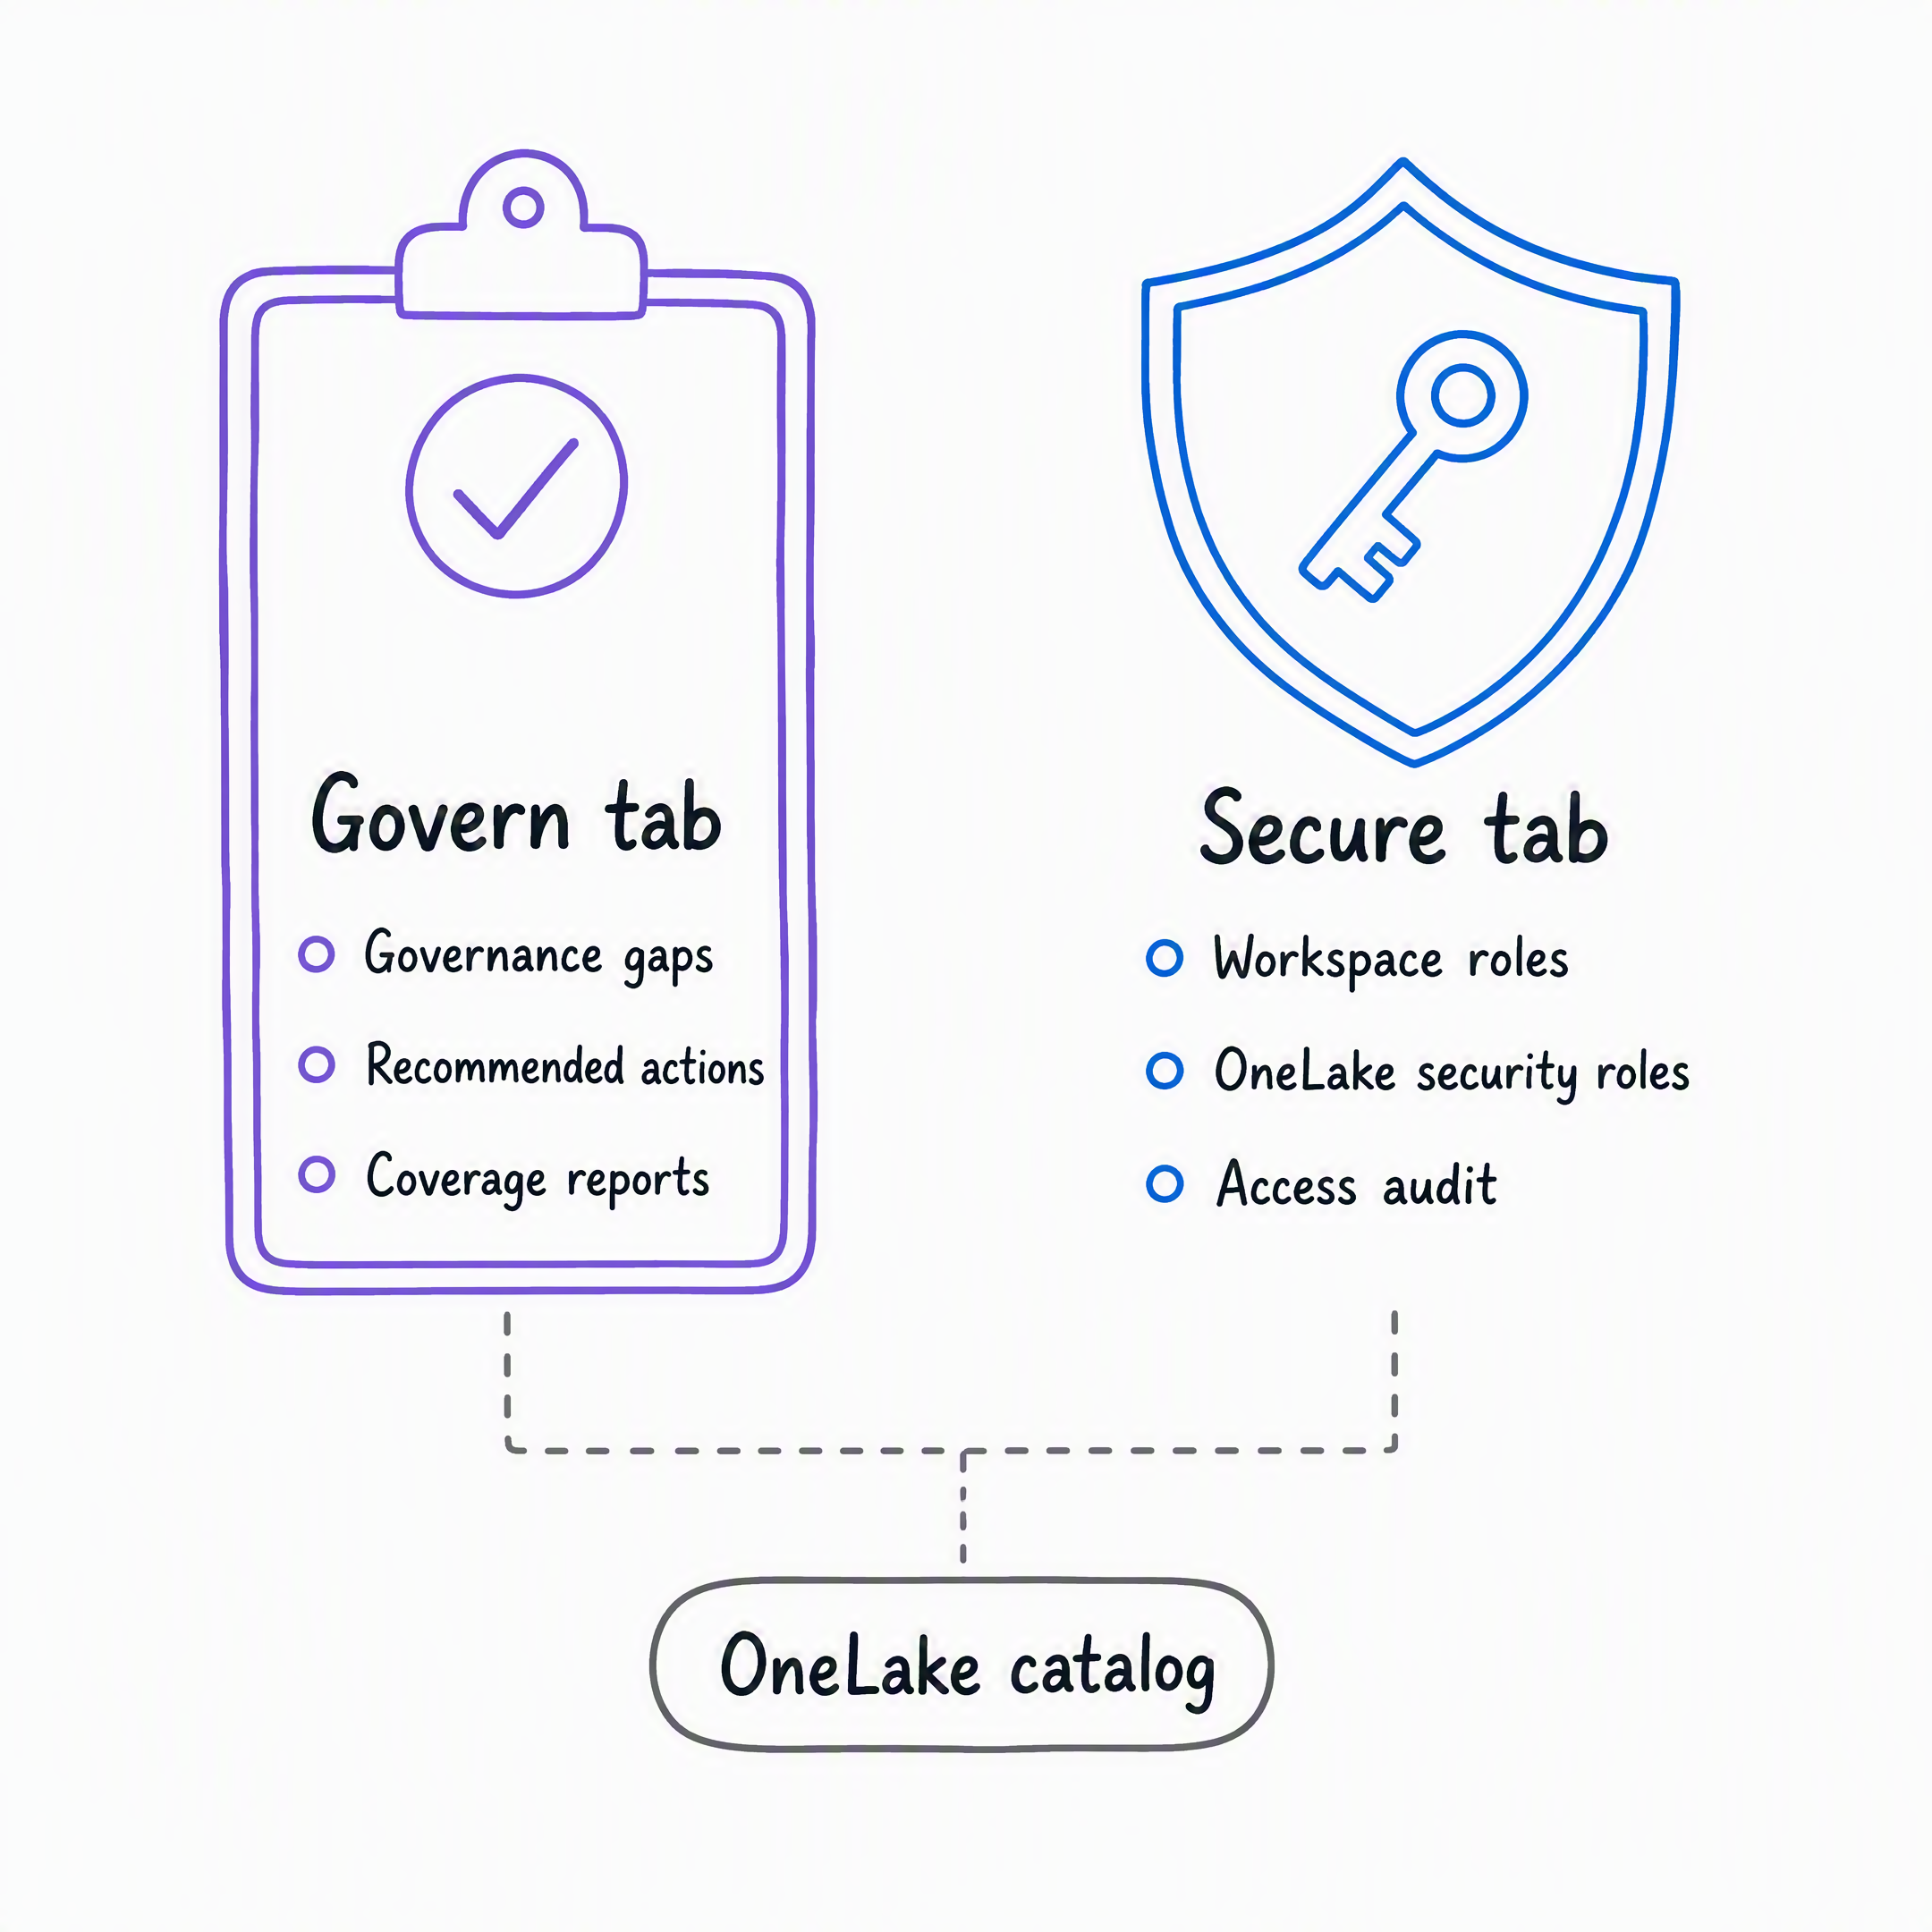

#### Key Idea
Applying:

✅ Sensitivity Labels \
✅ Endorsement \
✅ Metadata

is not enough by itself.

Governance can drift over time:
* Certified datasets may become outdated.
* Sensitive data may lose labels.
* Users may keep access after changing roles.
* Documentation may become incomplete.

Governance monitoring helps identify these issues before they impact users.
#### Governance Lifecycle
> Classify → Endorse → Document → Monitor → Improve

#### OneLake Catalog Governance Areas
Two major areas help monitor governance:
##### 1. Govern
Focuses on:
* Governance Health
##### 2. Secure
Focuses on:
* Access Control
#### Govern Section
##### Purpose
Provides a centralized view of governance posture.

Helps answer:
> Are our assets properly governed?

#### Govern Provides Three Capabilities
##### 1. Insights
Automatically identifies governance issues.

Examples:

✅ Missing descriptions \
✅ Missing sensitivity labels \
✅ Unendorsed production assets \
✅ Potential governance gaps
##### Example
A production semantic model has:
> No Certification

Govern highlights this as a gap.
##### Exam Tip
Insights identify governance problems automatically.
##### 2. Recommended Actions
Govern not only identifies problems.

It also provides:

✅ Guidance \
✅ Suggested fixes \
✅ Filtered item lists
##### Example
* **Issue**: Missing Description
* **Recommendation**: Add Description

with affected assets listed.
##### Benefit
Makes remediation easier.
##### 3. Reports
Provide governance metrics.

Examples:

✅ Label coverage \
✅ Endorsement coverage \
✅ Data freshness \
✅ Governance posture
##### Example Questions
* How many assets are certified?
* Which assets are missing labels?
* Which datasets are stale?
##### Exam Tip
Reports help measure governance maturity.
#### Governance Scopes
##### Fabric Admin View
Sees **Tenant-Wide Governance**

Includes:

✅ All domains \
✅ All workspaces \
✅ All governance insights
##### Refresh Behavior
Insights refresh: **Daily**

from admin monitoring storage.
##### Exam Favorite
Admin governance insights are not always real time.
##### Data Owner View
Sees **Owned Assets Only**

Includes:

✅ Owned lakehouses \
✅ Owned semantic models \
✅ Owned reports
##### Refresh Behavior
Refresh occurs when **Govern Section Is Accessed**
#### Domain Filtering
Both admins and owners can filter governance information by:

✅ Domain \
✅ Business area
##### Example
* Finance
* Sales
* Operations
* HR
##### Benefit
Focuses governance reviews.
#### Governance Prioritization
Fix the most impactful issues first.
##### Highest Priority Issues
* Missing Descriptions

    Problem:

    ❌ Assets are difficult to discover.
* Missing Sensitivity Labels

    Problem:

    ❌ Sensitive data may be unprotected.
* Missing Endorsements

    Problem:

    ❌ Trusted assets look the same as experiments.
##### Exam Tip
Consumer trust is strongly influenced by:

✅ Description \
✅ Classification \
✅ Endorsement
#### Secure Section
##### Purpose
Provides centralized visibility into access permissions.

Helps answer:
* Who Has Access To What?
#### Secure Section Components
##### Workspace Roles
Shows:

✅ Users \
✅ Groups \
✅ Role assignments
##### Examples
* Admin
* Member
* Contributor
* Viewer
##### Exam Tip
Workspace roles control broad access.
#### OneLake Security Roles
Shows:

✅ Table-level permissions \
✅ Folder-level permissions \
✅ Granular access controls
##### Examples
* Patient Records Only
* Finance Tables Only
##### Benefit
More precise than workspace roles.
#### Role Management
Provides centralized administration.

Allows:

✅ Audit access \
✅ Create roles \
✅ Modify roles \
✅ Delete roles

Without opening every individual item.
##### Exam Favorite
Role management centralizes permission administration.
#### Governance Answers
* What Should Be Used?
##### Examples
✅ Sensitive \
✅ Trusted \
✅ Certified \
✅ Approved
#### Security Answers
* Who Can Use It?
##### Examples:
✅ Allowed users \
✅ Allowed groups \
✅ Role assignments
#### Combined View
| Governance         | Security        |
| ------------------ | --------------- |
| Sensitivity Labels | Permissions     |
| Endorsement        | Workspace Roles |
| Metadata           | Security Roles  |
| Lineage            | Access Control  |

##### Exam Tip
Governance and security are complementary, not competing.
#### Governance in AI Experiences
Governance signals influence AI behavior.
#### Endorsement and AI
Copilot and Data Agents:

✅ Prefer endorsed assets

over:

❌ Unendorsed assets
##### Result
More trustworthy AI responses.
#### Sensitivity Labels and AI
Labels enforce:

✅ Same access boundaries

for:
* Human users
* Copilot
* Data Agents
##### Exam Tip
AI does not bypass sensitivity labels.
#### Metadata and AI
Good descriptions provide:

✅ Better business context \
✅ Better AI understanding \
✅ More accurate responses
##### Example
* Revenue

with a clear description is easier for AI to interpret correctly.
#### Governance Workflow
> Sensitivity Labels → Endorsement → Metadata → Govern Section → Secure Section → AI Consumption

#### Exam Quick Facts
✅ Govern section monitors governance posture \
✅ Govern provides:
* Insights
* Recommended Actions
* Reports

✅ Insights identify governance gaps \
✅ Recommendations explain how to fix issues \
✅ Reports show:
* Label coverage
* Endorsement status
* Data freshness

✅ Admins see tenant-wide governance \
✅ Data owners see owned assets only \
✅ Domain filtering is supported \
✅ Secure section shows:
* Workspace roles
* OneLake security roles
* Role management

✅ Governance explains:
* What data should be trusted

✅ Security explains:
* Who can access the data

✅ Copilot prefers endorsed assets \
✅ Sensitivity labels apply to AI experiences \
✅ Metadata improves AI response quality 
#### Memory Trick
##### Governance Formula
> Govern → Find Problems

> Secure → Find Access

##### AI Governance Formula
> Endorsement + Sensitivity Labels + Metadata → Better AI Answers

##### ⭐ Most Tested Concept:
The Govern section identifies governance gaps and recommends fixes, while the Secure section provides centralized visibility and management of data access. Governance signals such as endorsements, labels, and metadata also guide how Copilot and data agents discover and use data.

### **Exercise - Govern analytics data in Microsoft Fabric**

#### Set up the environment
> Note: You need access to a Fabric paid or trial capacity to complete this exercise. Paid capacities must include Power BI capabilities, or you need a separate Power BI Pro or Premium Per User license. For information about the free Fabric trial, see Fabric trial.

##### Create a workspace
1. Navigate to the [Microsoft Fabric home page](https://app.fabric.microsoft.com/home?experience=fabric) in a browser, and sign in with your Fabric credentials.
2. In the menu bar on the left, select **Workspaces** (the icon looks similar to 🗇).
3. Create a new workspace with a name of your choice, selecting a licensing mode that includes Fabric capacity (Trial, Premium, or Fabric). If you’re using a paid capacity, an F2 SKU or higher is sufficient.
4. When your new workspace opens, it should be empty.

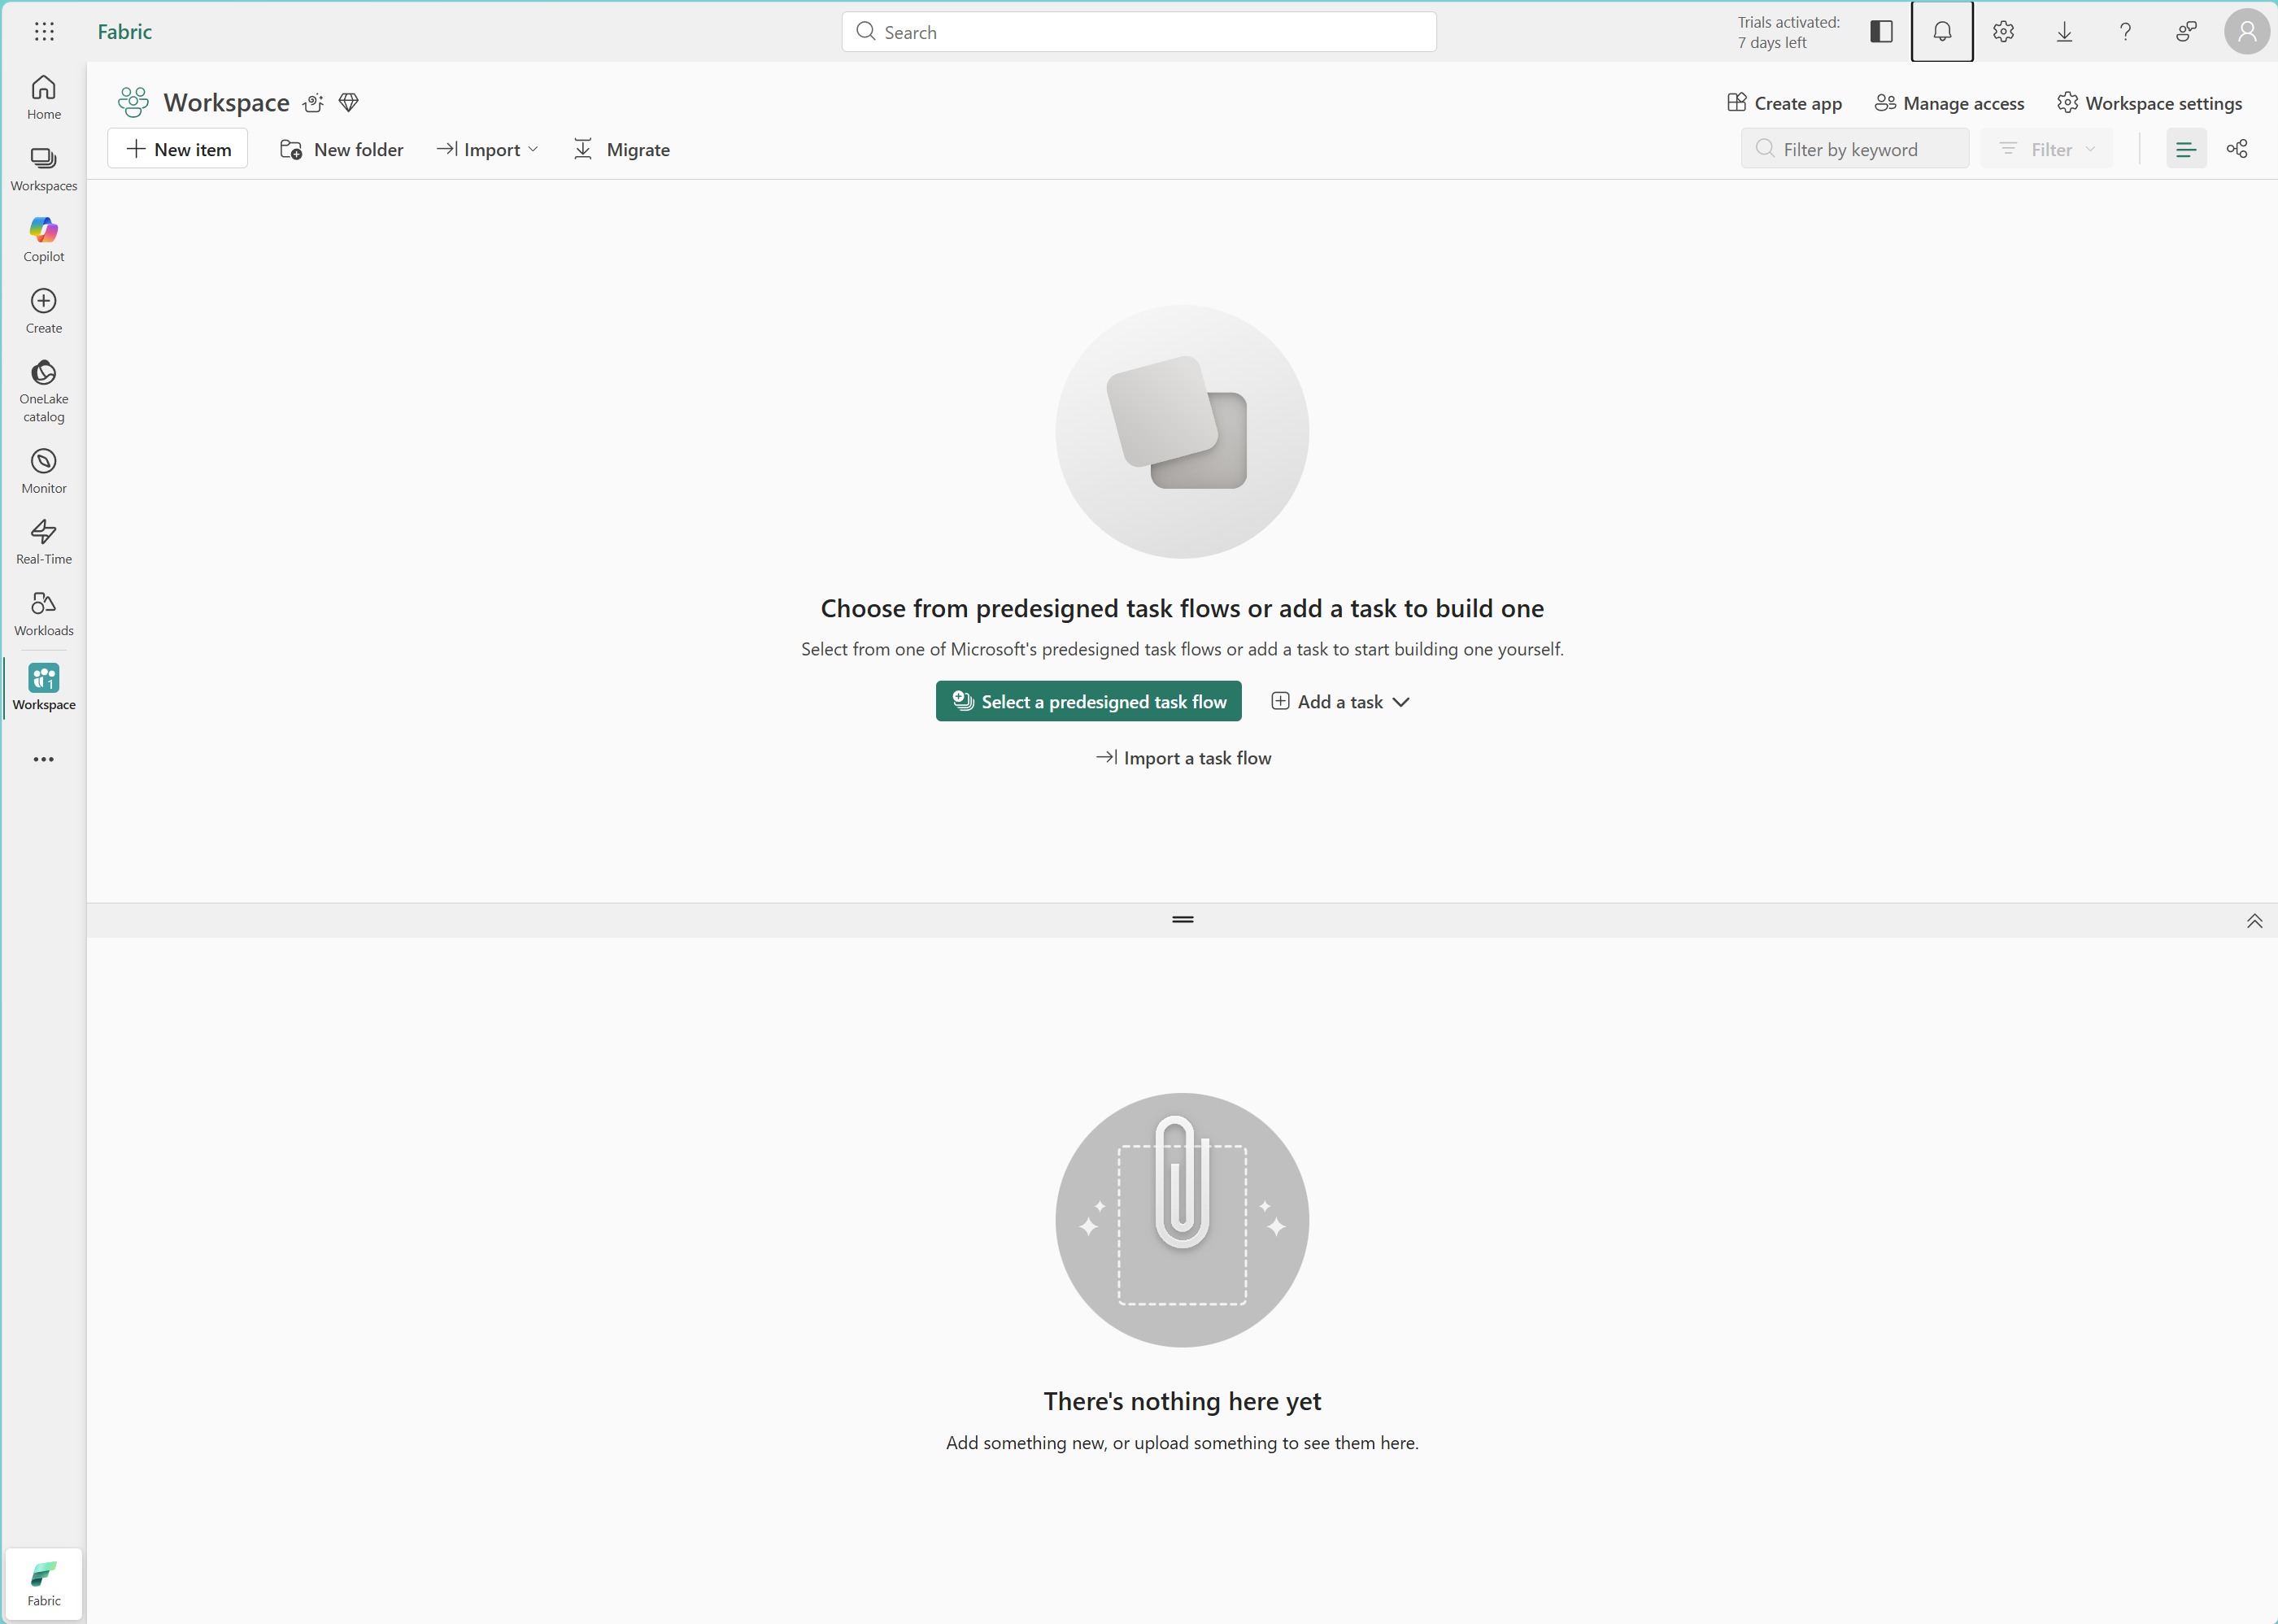

##### Create a lakehouse and load data
In this task, you create a lakehouse and load sample sales data into a table.
1. In your workspace, select **+ New item**, and then select **Lakehouse**. Name it **Sales**.

After a minute or so, a new lakehouse with empty **Tables** and **Files** folders is created.
2. Download the [sales.csv](https://github.com/MicrosoftLearning/dp-data/raw/main/sales.csv) sample sales data. Save it as **sales.csv**.
> Tip: If the file opens in your browser, right-click anywhere on the page and select Save as to save it as a CSV file.

3. Return to your lakehouse in the browser. In the … menu for the **Files** folder, select **Upload > Upload files**, and upload the **sales.csv** file from your local computer.
4. After the file uploads, select the … menu for the **sales.csv** file and select **Load to Tables > New table**.
5. In the **Load to table** dialog, set the table name to `sales` and confirm the load operation. Wait for the table to be created and loaded.
> Tip: If the sales table doesn’t appear automatically, select Refresh in the … menu for the Tables folder.

6. In the **Explorer** pane, select the `sales` table to verify the data loaded correctly.
##### Create a semantic model
In this task, you create a semantic model from the lakehouse sales table.
1. At the top-right of the lakehouse page, switch from **Lakehouse** to **SQL analytics endpoint**. Wait for the SQL analytics endpoint to open.

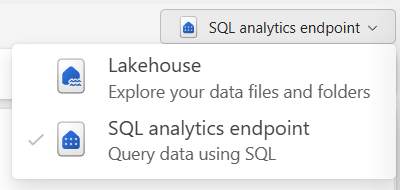

2. In the Home ribbon, select **New semantic model**.
3. In the **New semantic model** dialog box, name the semantic model **Sales Analysis**.
4. Leave the default selections, select the `sales` table, then **Confirm** to create the model.

After a moment, the semantic model is created in your workspace.
5. Select your workspace name in the breadcrumb at the top of the page to return to the workspace view. You should now see several items: the **Sales** lakehouse, its **SQL analytics endpoint**, and the **Sales Analysis** semantic model you created.

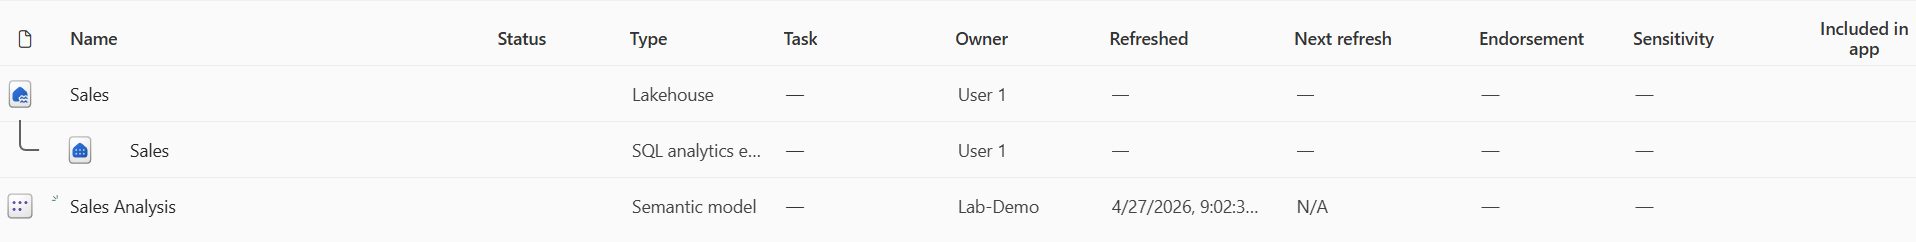

#### Endorse and document data assets
Endorsement and descriptions work together to make items trustworthy and discoverable. In this section, you promote and document the lakehouse and semantic model so users can find and evaluate them in the OneLake catalog.
##### Endorse and document the lakehouse
In this task, you promote the **Sales** lakehouse and add a description.
1. In the workspace view, find the **Sales** lakehouse. Select the … menu for the lakehouse and choose **Settings**.
2. In the settings pane, expand the **Endorsement** section.
3. Select **Promoted** and then select **Apply**.

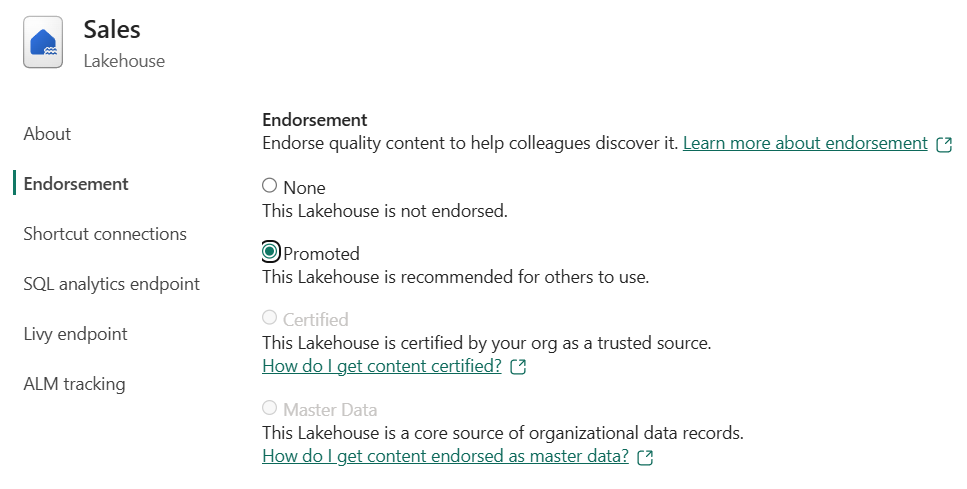

4. In the **About** section, enter the following description:
    > `Retail sales transactions including order date, item, category, quantity, and unit price. Refreshed manually with sample data for training purposes.`

5. Close the settings pane to save your changes and return to the workspace view.
##### Endorse and document the semantic model
In this task, you promote the **Sales Analysis** semantic model and add a description.
1. In the workspace view, find the **Sales Analysis** semantic model. Select the … menu and choose **Settings**.
2. Expand the **Endorsement and discovery** section, select **Promoted**.
> Notice that the option to Make discoverable is automatically selected at this time. While access is still restricted, this semantic model appears in results so users can request access.

3. In the **Description** field, enter:
    > `Semantic model built from the Sales lakehouse. Contains retail sales data with revenue by item and category. Promoted for team use.`

4. Close the settings pane and return to the workspace view. Notice that **promoted** items now display a Promoted badge next to their name in the workspace list.

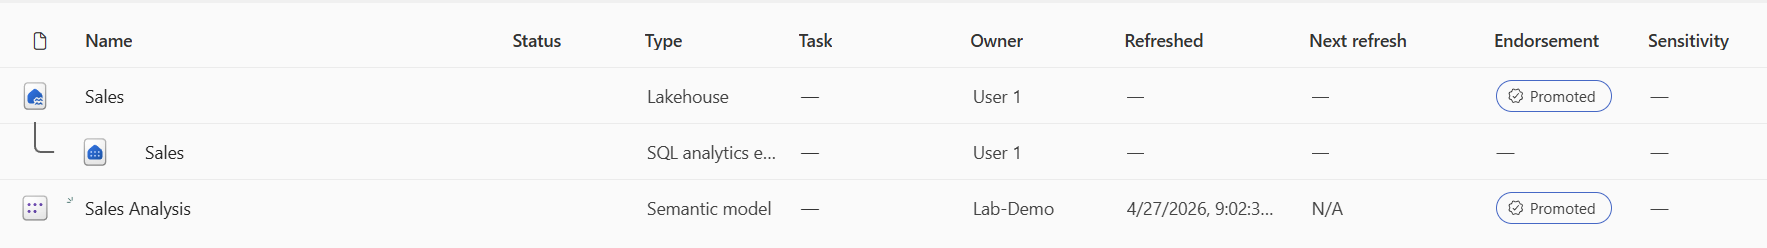

#### Explore governance in the OneLake catalog
The OneLake catalog provides a centralized view of data assets in your Fabric environment. In this section, you use the different tabs to discover items, review governance insights, and check access controls.
1. In the left navigation pane, select the **OneLake** icon to open the OneLake catalog.

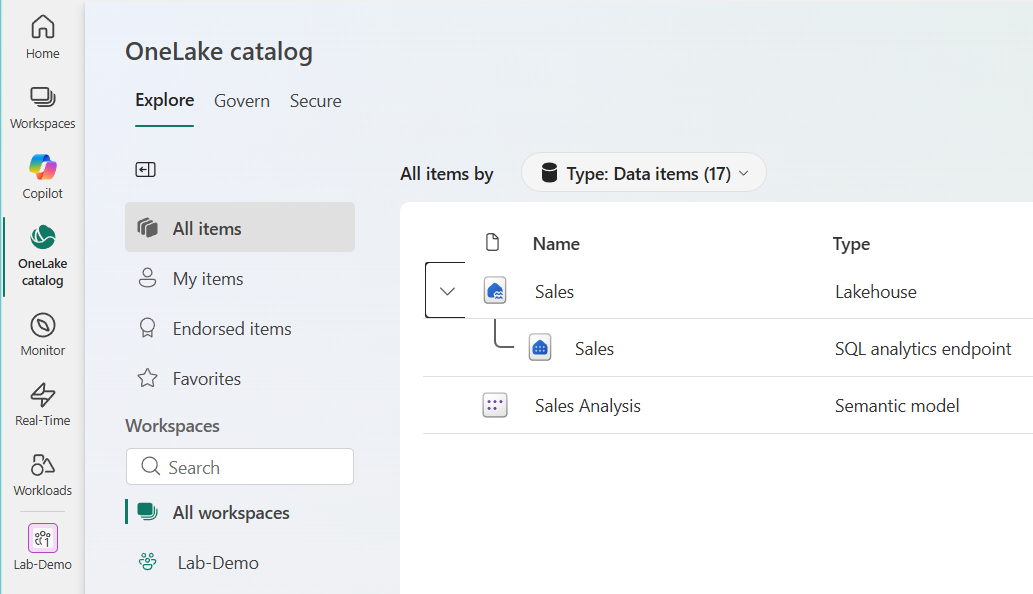

2. In the **Explore** tab, browse the list of items. Find your **Sales** lakehouse and select it to view its details in the side pane.
3. In the details pane, notice the **Overview** tab displays:
    * The description you added earlier.
    * **Location**: Shows the workspace where the item is stored.
    * **Data updated**: Shows when the data was last updated.
    * **Owner**: Shows who owns the item.
    * **Endorsement**: Shows the Promoted badge you applied.
    * **Tables**: Shows which tables exist.
4. Select the Endorsed items section in the navigation pane. Notice how only your endorsed lakehouse and semantic model should appear.
> Note: Filtering by endorsement helps you focus on trusted, quality-checked assets.

5. Select the **Govern** tab at the top of the OneLake catalog. The Govern tab displays a **Your governance status at a glance** dashboard with summary cards showing the number of domains, workspaces, and items you own. Charts break down items by type, last refresh date, and description coverage. A **Recommended actions** section suggests improvements like increasing the percentage of endorsed items.

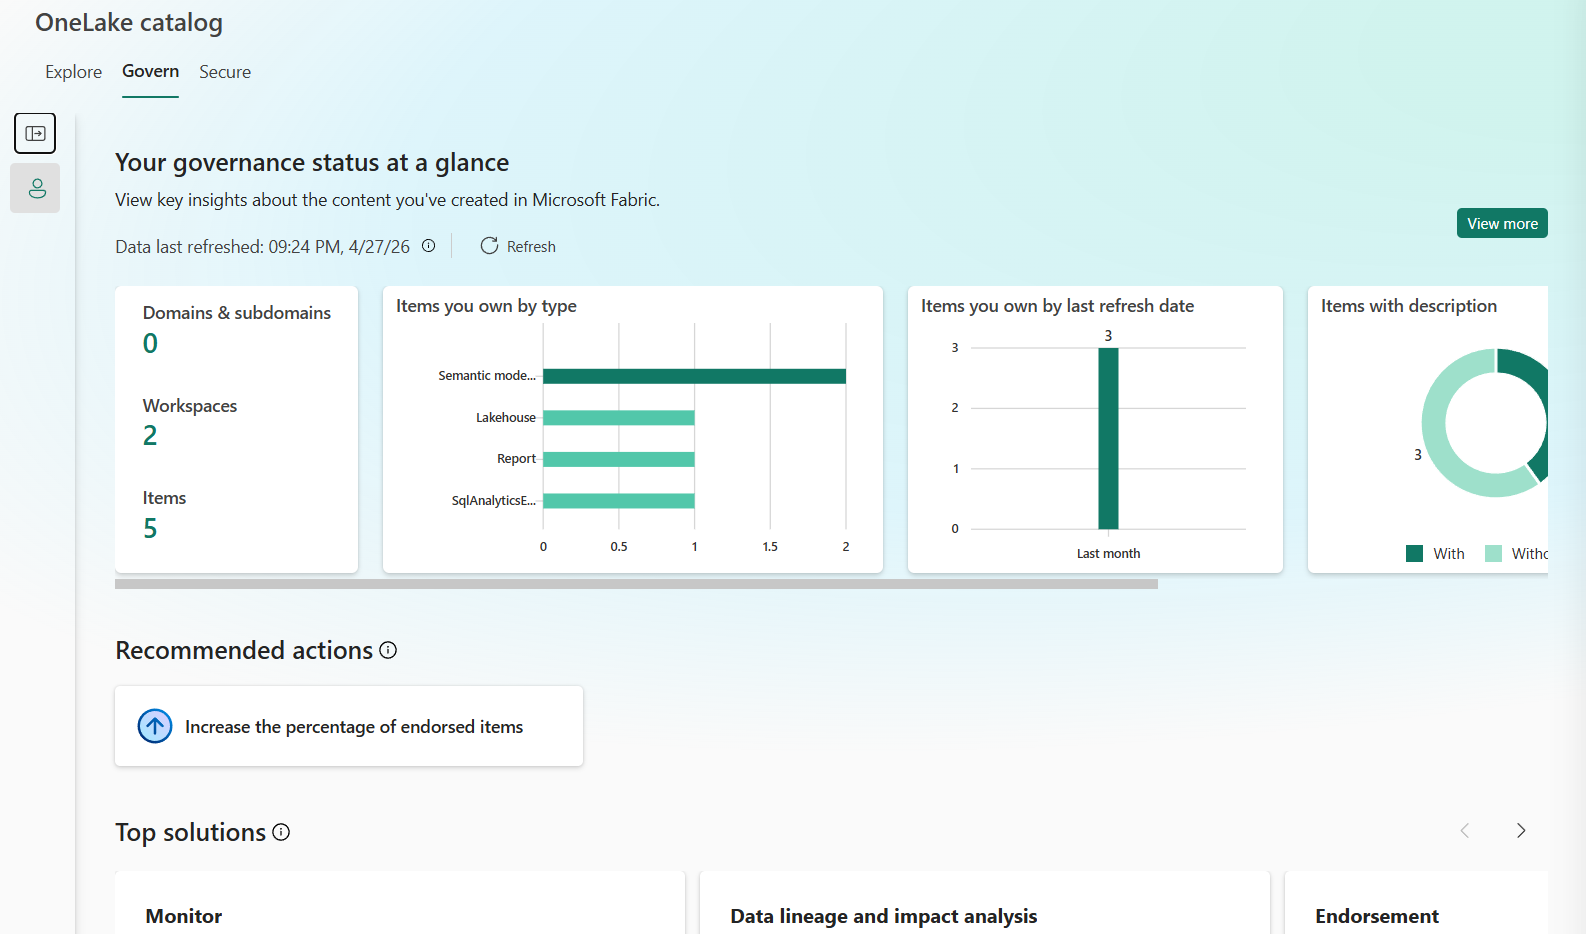

6. Select **View more** to open the **All insights** report. This interactive report resembles a Power BI dashboard with a filters pane on the right. It includes detailed charts about your data estate, such as items by type, workspaces assigned to domains, items that failed last refresh by type, items by last access date, and items by last refresh date.
7. Explore the report by filtering and scrolling through the charts. When you’re done, select the back arrow to return to the OneLake catalog.
8. Select the **Secure** tab to view security information. The Secure tab shows workspace roles and OneLake security roles across items, providing a centralized view of users and their access permissions.
#### View lineage and run impact analysis
Lineage shows how data flows between items in a workspace, and impact analysis identifies downstream dependencies. In this section, you trace data lineage from the lakehouse to the semantic model and run impact analysis to identify items affected by changes.
1. Return to your workspace by selecting **Workspaces** in the left navigation pane and then selecting your workspace.
2. In the workspace toolbar, select the **Lineage view** icon below **Workspace settings**.

The lineage view displays all items in the workspace as cards, connected by arrows showing data flow.

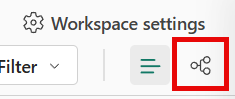

3. Find the **Sales** lakehouse card. Trace the arrows to see how data flows from the lakehouse to its SQL analytics endpoint, and from there to the **Sales Analysis** semantic model.

This visualization shows the complete data lineage: the lakehouse is the source, the SQL analytics endpoint provides SQL access, and the semantic model enables reporting and AI consumption.

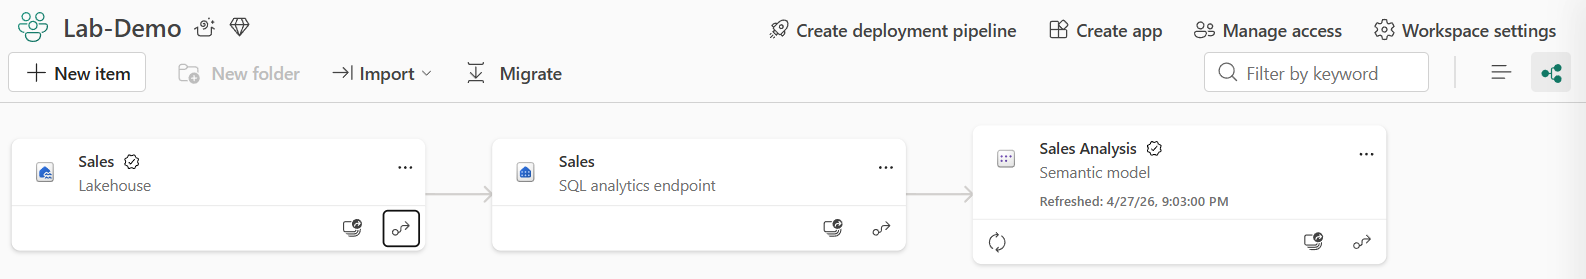

4. On the **Sales** lakehouse card, select the arrow icon at the bottom-right corner to highlight its specific lineage. Fabric dims unrelated items and highlights only the items connected to the lakehouse.
5. On the **Sales** lakehouse card, select the icon to **Show impact across workspaces**.

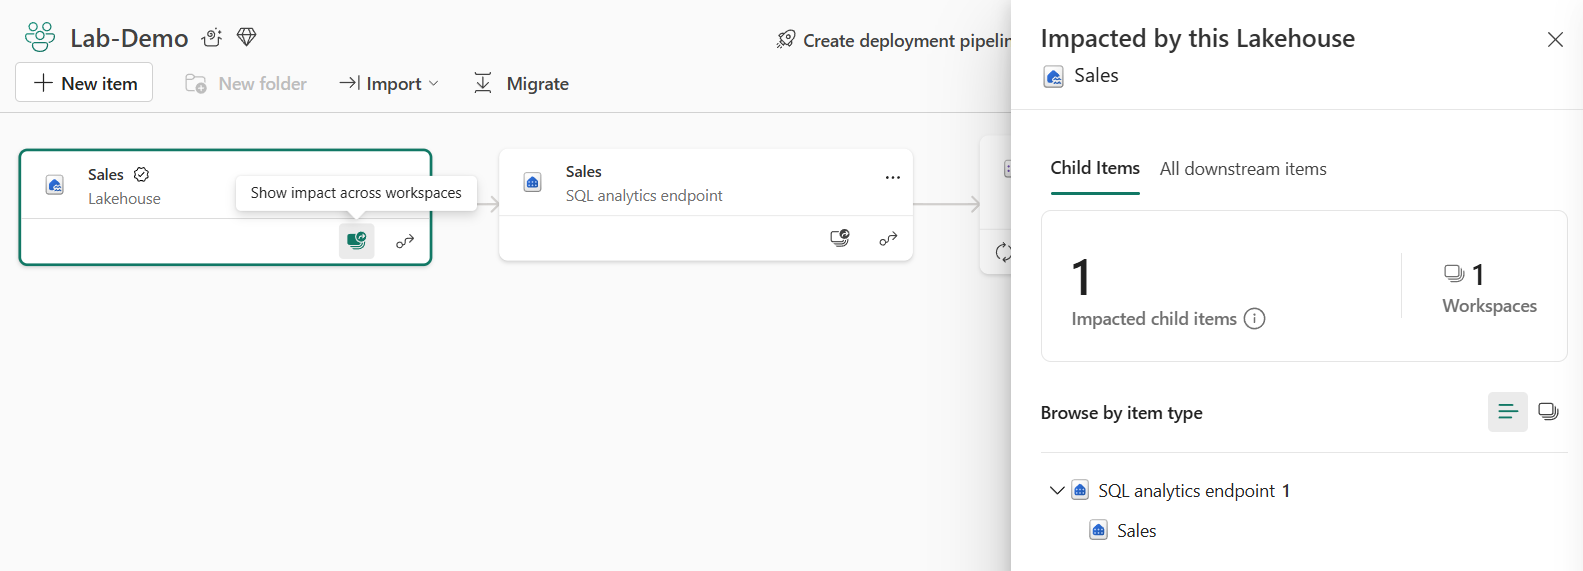

6. In the impact analysis pane, select **All downstream items** and review what depends on the lakehouse:
    * The SQL analytics endpoint
    * The semantic model built from the endpoint

These are the items that would be affected if you changed the lakehouse structure, deleted tables, or modified data. Understanding this dependency chain is critical before making changes.

7. Close the impact analysis pane and switch back to **List view** in the workspace toolbar.
#### Clean up resources
In this exercise, you created a lakehouse with sample data, built a semantic model, and applied governance practices including endorsement, documentation, and lineage analysis. You used the OneLake catalog to explore governance insights across your data estate.

If you’ve finished exploring, you can delete the workspace you created for this exercise.
1. In the bar on the left, select the icon for your workspace to view all of the items it contains.
2. In the toolbar, select **Workspace settings**.
3. In the **General** section, select **Remove this workspace**.

### **Knowledge check**

#### 1. An analytics team needs to ensure that a lakehouse containing customer personal data is protected throughout the entire data lineage, including downstream semantic models and reports. Which sensitivity labeling capability automatically propagates the label to dependent items?

A) Default labeling \
B) Mandatory labeling \
**C) Downstream inheritance**

#### 2. A data team wants to designate a semantic model as the authoritative, single source of truth for product reference data across the organization. Which endorsement level is most appropriate?

A) Promoted \
B) Certified \
**C) Master data**

#### 3. A governance lead reviews the OneLake catalog and notices that many items lack descriptions and sensitivity labels. Which section in the OneLake catalog provides recommended actions to improve governance posture?

A) Explore \
**B) Govern** \
C) Secure

#### 4. An organization deploys a data agent that answers executive questions about quarterly revenue. The agent has access to both a certified semantic model and an unpromoted experimental dataset. How does endorsement affect the agent's behavior?

A) The agent ignores endorsement metadata and queries both sources equally. \
**B) The agent prioritizes the certified semantic model as a more authoritative source.** \
C) The agent only queries items that have the master data designation.

#### 5. An analytics engineer documents a semantic model with the description 'Monthly retail sales revenue by region and product category, refreshed daily from the certified lakehouse.' How does this affect AI agent responses compared to a generic description?

A) The description has no effect because AI agents rely only on sensitivity labels for context. \
**B) The detailed description provides context that helps the AI agent generate specific, accurate responses about the data's scope and refresh frequency.** \
C) The description only affects human users browsing the OneLake catalog, not AI agent behavior.